# EDA — Credit & Payment BehaviourJunior Data Scientist technical test.Source: `PYTHON_ETL/database.csv` · Configuration: `mlops_pipeline/src/config.json`

## 0. Setup

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 11, "axes.labelsize": 9})

CONFIG_PATH = Path("../config.json").resolve()
CFG = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
BASE = CONFIG_PATH.parent
RAW_CSV = (BASE / CFG["paths"]["raw_data"]).resolve()

TARGET = CFG["schema"]["target"]
SCHEMA = CFG["schema"]
RULES = CFG["validation_rules"]
REF = CFG["domain_reference"]
RANDOM_STATE = CFG["eda"]["random_state"]

print("config :", CONFIG_PATH)
print("dataset:", RAW_CSV, "| exists:", RAW_CSV.exists())

config : /home/zerotwo/data_science_in_production/credit_payment/PYTHON_ETL/mlops_pipeline/src/config.json
dataset: /home/zerotwo/data_science_in_production/credit_payment/PYTHON_ETL/database.csv | exists: True


In [2]:
FIGURE_INDEX = []


def show_fig(fig, name):
    """Lay out a figure and register its name.

    Nothing is written to disk: every plot lives in the notebook's own
    interactive output. `name` only labels the figure for the index in 5.3.
    """
    fig.tight_layout()
    # Idempotent on purpose: re-running one plot cell replaces that cell's stored
    # image but would otherwise append a duplicate name, and the export scripts
    # zip names to images by position -- every later PNG would be mislabelled.
    if name not in FIGURE_INDEX:
        FIGURE_INDEX.append(name)
    return fig


def describe_extended(frame):
    """describe() plus dispersion and shape statistics."""
    num = frame.select_dtypes(include=["number"]).astype(float)
    out = num.describe().T
    out["range"] = out["max"] - out["min"]
    out["IQR"] = out["75%"] - out["25%"]
    out["variance"] = num.var()
    out["CV"] = out["std"] / out["mean"].replace(0, np.nan)
    out["skew"] = num.skew()
    out["kurtosis"] = num.kurt()
    out["n_missing"] = frame[num.columns].isna().sum()
    out["pct_missing"] = out["n_missing"] / len(frame)
    out["n_unique"] = num.nunique()
    out["n_zeros"] = (num == 0).sum()
    return out


def missing_report(frame):
    m = pd.DataFrame({
        "dtype": frame.dtypes.astype(str),
        "n_missing": frame.isna().sum(),
        "pct_missing": frame.isna().mean(),
        "n_unique": frame.nunique(dropna=True),
    })
    return m.sort_values("pct_missing", ascending=False)

## 1. Data loading

### 1.1 Raw load — every column as text, no implicit coercion

In [3]:
raw = pd.read_csv(
    RAW_CSV,
    sep=CFG["read_csv"]["sep"],
    encoding=CFG["read_csv"]["encoding"],
    dtype=str,
    keep_default_na=False,   # keep the file's own null representation visible
)
print("shape:", raw.shape)
raw.head(10)

shape: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,"95,227787",795.0,0,2,0.0,0.0,,,0,0,0,916148,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,"95,227787",796.0,0,7,0.0,0.0,,,0,0,0,4473774,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,"95,227787",727,5,0,0,274561,274561,,2,0,1,,,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,"95,227787",864,8,1,0,27564,27564,,1,0,6,,,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,"95,227787",771.0,0,3,0.0,0.0,,,0,0,0,61000,Creciente,1
5,9,30/11/2024 11:38,465461,2,29,Independiente,3000000,1000000,183393,"86,830187",678,7,2,0,4158,4158,,0,0,4,,,1
6,9,4/12/2024 11:26,1084187,8,28,Independiente,3000000,1000000,112736,"86,830187",665,2,1,0,6182,6182,,1,0,0,,,1
7,4,27/03/2025 14:57,556680,6,30,Independiente,2000000,700000,82757,"18,451409",738.0,0,4,0.0,0.0,,,0,0,0,955038,Creciente,0
8,9,5/02/2025 17:31,4627577,10,33,Independiente,2000000,800000,392490,"47,613894",769.0,0,2,0.0,0.0,,,0,0,0,,,0
9,4,15/12/2024 11:23,2100000,8,26,Empleado,1200000,300000,237864,"28,340846",785.0,0,1,0.0,0.0,,,0,0,0,1193037,Estable,0


In [4]:
print("columns:", list(raw.columns))
print("\nfull-row duplicates:", raw.duplicated().sum())
raw.info(memory_usage="deep")

columns: ['tipo_credito', 'fecha_prestamo', 'capital_prestado', 'plazo_meses', 'edad_cliente', 'tipo_laboral', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito', 'tendencia_ingresos', 'Pago_atiempo']

full-row duplicates: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   tipo_credito                   10763 non-null  object
 1   fecha_prestamo                 10763 non-null  object
 2   capital_prestado               10763 non-null  object
 3   plazo_meses                    10763 non-null  object
 4   edad_cliente                   107

### 1.2 Inventory of the raw string values per column

In [5]:
inventory = pd.DataFrame({
    "n_unique": raw.nunique(),
    "n_blank": raw.apply(lambda s: s.str.strip().eq("").sum()),
    "has_comma_decimal": raw.apply(lambda s: s.str.contains(r"^-?\d+,\d+$", na=False).any()),
    "has_dot_decimal": raw.apply(lambda s: s.str.contains(r"^-?\d+\.\d+$", na=False).any()),
    # fillna(False) here is a property of the CHECK, not of the data: a null cell is not
    # "all digits". Nothing is written back to raw.
    "is_all_digits": raw.apply(lambda s: s.str.match(r"^-?\d+$").fillna(False).all()),
    "sample": raw.apply(lambda s: " | ".join(s[s.str.strip().ne("")].unique()[:4])),
})
inventory

,n_unique,n_blank,has_comma_decimal,has_dot_decimal,is_all_digits,sample
tipo_credito,6,0,False,False,True,4 | 9 | 10 | 6
fecha_prestamo,10444,0,False,False,False,7/01/2025 14:40 | 9/01/2025 11:18 | 26/12/2024...
capital_prestado,7306,0,False,False,True,1852560 | 3181080 | 670200 | 506807
plazo_meses,18,0,False,False,True,12 | 6 | 5 | 2
edad_cliente,54,0,False,False,True,32 | 34 | 25 | 26
tipo_laboral,2,0,False,False,False,Empleado | Independiente
salario_cliente,1385,0,False,False,True,3500000 | 5000000 | 3000000 | 2000000
total_otros_prestamos,1538,0,False,False,True,1000000 | 2000000 | 900000 | 600000
cuota_pactada,9836,0,False,False,True,128650 | 441817 | 108632 | 199684
puntaje,248,0,True,False,False,"95,227787 | 86,830187 | 18,451409 | 47,613894"


## 2. Initial data exploration

### 2.1 General overview — variable characterisation and missing valuesDeclared taxonomy (from `config.json`): target, nominal, ordinal, discrete counts, monetary, scores.

In [6]:
def classify(col):
    if col == TARGET:
        return "target (dichotomous)"
    if col in SCHEMA["categorical_nominal"]:
        return "categorical nominal (polytomous)" if raw[col].nunique() > 2 else "categorical dichotomous"
    if col in SCHEMA["categorical_ordinal"]:
        return "categorical ordinal (polytomous)"
    if col in SCHEMA["counts_discrete"]:
        return "numerical discrete (count/ratio)"
    if col in SCHEMA["monetary"]:
        return "numerical continuous (monetary, ratio)"
    if col in SCHEMA["scores"]:
        return "numerical continuous (score, interval)"
    if col in CFG["read_csv"]["date_columns"]:
        return "datetime"
    return "unclassified"


taxonomy = pd.DataFrame({
    "variable": raw.columns,
    "measurement_type": [classify(c) for c in raw.columns],
    "n_unique": [raw[c].nunique() for c in raw.columns],
    "n_blank": [raw[c].str.strip().eq("").sum() for c in raw.columns],
}).set_index("variable")
taxonomy["pct_blank"] = taxonomy["n_blank"] / len(raw)
taxonomy

,measurement_type,n_unique,n_blank,pct_blank
variable,,,,
tipo_credito,categorical nominal (polytomous),6,0,0.0000
fecha_prestamo,datetime,10444,0,0.0000
capital_prestado,"numerical continuous (monetary, ratio)",7306,0,0.0000
plazo_meses,numerical discrete (count/ratio),18,0,0.0000
edad_cliente,numerical discrete (count/ratio),54,0,0.0000
tipo_laboral,categorical dichotomous,2,0,0.0000
salario_cliente,"numerical continuous (monetary, ratio)",1385,0,0.0000
total_otros_prestamos,"numerical continuous (monetary, ratio)",1538,0,0.0000
cuota_pactada,"numerical continuous (monetary, ratio)",9836,0,0.0000


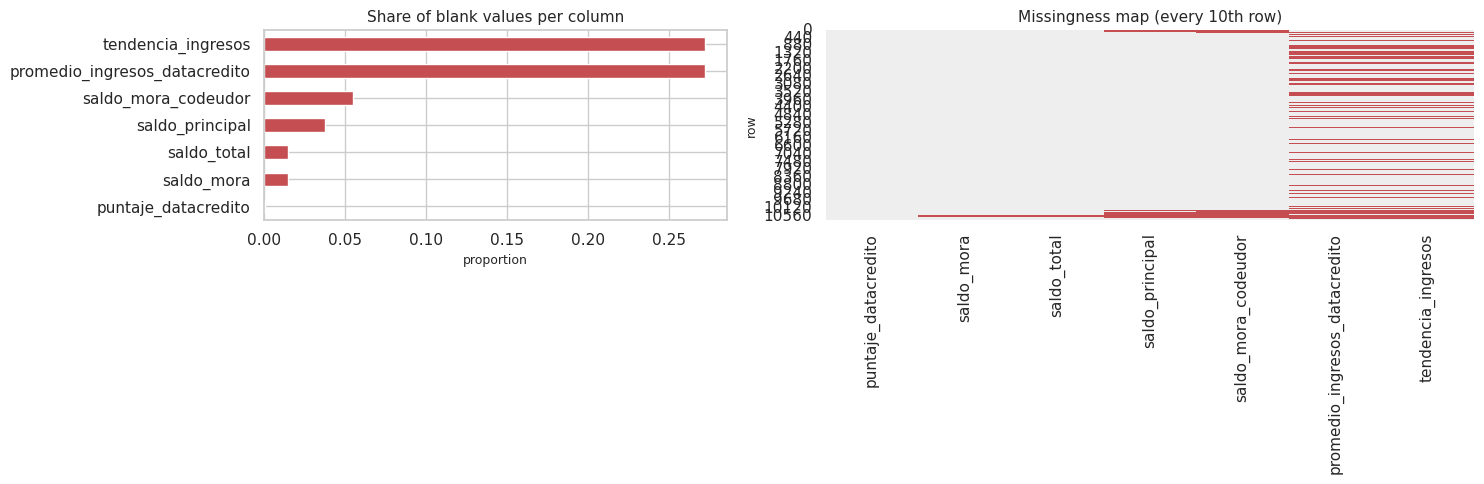

In [7]:
blank = raw.apply(lambda s: s.str.strip().eq(""))
blank_cols = blank.columns[blank.any()].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5), width_ratios=[1, 1.4])
blank[blank_cols].mean().sort_values().plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title("Share of blank values per column")
axes[0].set_xlabel("proportion")

sns.heatmap(blank[blank_cols].astype(int).iloc[::10], cbar=False, ax=axes[1],
            cmap=["#eeeeee", "#c44e52"])
axes[1].set_title("Missingness map (every 10th row)")
axes[1].set_ylabel("row")
show_fig(fig, "01_missingness")
plt.show()

In [8]:
pattern = blank[blank_cols].astype(int).astype(str).agg("".join, axis=1)
pattern_counts = pattern.value_counts().rename("n_rows").to_frame()
pattern_counts["pct"] = pattern_counts["n_rows"] / len(raw)
pattern_counts["missing_block"] = [
    ", ".join(c for c, f in zip(blank_cols, p) if f == "1") or "(complete)"
    for p in pattern_counts.index
]
pattern_counts.head(12)

,n_rows,pct,missing_block
0000000,7673,0.7129,(complete)
0000011,2500,0.2323,"promedio_ingresos_datacredito, tendencia_ingresos"
0000111,184,0.0171,"saldo_mora_codeudor, promedio_ingresos_datacre..."
0001100,157,0.0146,"saldo_principal, saldo_mora_codeudor"
0111111,149,0.0138,"saldo_mora, saldo_total, saldo_principal, sald..."
0001111,92,0.0085,"saldo_principal, saldo_mora_codeudor, promedio..."
1111111,5,0.0005,"puntaje_datacredito, saldo_mora, saldo_total, ..."
0000101,1,0.0001,"saldo_mora_codeudor, tendencia_ingresos"
0111101,1,0.0001,"saldo_mora, saldo_total, saldo_principal, sald..."
1111100,1,0.0001,"puntaje_datacredito, saldo_mora, saldo_total, ..."


### 2.2 Standardising how nulls are represented

In [9]:
NULL_TOKENS = CFG["null_tokens"]

df = raw.apply(lambda s: s.str.strip()).replace(dict.fromkeys(NULL_TOKENS, np.nan))
print("null tokens mapped to NaN:", NULL_TOKENS)
print("\nNaN count after standardisation:")
print(df.isna().sum()[lambda s: s > 0].to_string())

null tokens mapped to NaN: ['', ' ', 'NA', 'N/A', 'na', 'null', 'NULL', 'None', 'nan', '-', '?']

NaN count after standardisation:
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932


### 2.3 Detecting inconsistent values before typingThis EDA **documents** what is wrong with the data; it does not repair it. No value isimputed anywhere in this notebook: unknowns are turned into nulls and left null, andout-of-range values are counted (section 2.6), never patched. Deciding what to fill, andwith what, is a modelling decision that belongs downstream, where it can be fitted on atraining split and validated. Doing it here would bake an untested assumption into everystatistic that follows.

In [10]:
VALID_TREND = CFG["valid_labels"]["tendencia_ingresos"]

trend_raw = df["tendencia_ingresos"]
is_label = trend_raw.isin(VALID_TREND)
contaminated = df[trend_raw.notna() & ~is_label]
print(f"rows where 'tendencia_ingresos' holds a number instead of a label: {len(contaminated)}")
contaminated[["promedio_ingresos_datacredito", "tendencia_ingresos", TARGET]].head(10)

rows where 'tendencia_ingresos' holds a number instead of a label: 58


,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
64,881581,8315,1
152,939017,8315,1
163,1200000,0,1
426,28878675,158042,1
468,1562215,3978,1
671,1000000,9147,1
1129,977131,8315,1
1132,2550000,168750,1
1811,5425531,-28589,1
1938,916148,8315,1


In [11]:
# The numeric values are income deltas. The magnitude is real data, so it is kept in
# its own column. The LABEL is not: inferring "Creciente" from a positive delta would
# be inventing a category the source never stated, and the 7 rows with a delta of
# exactly 0 have no defensible label at all. Those 58 labels stay missing.
df["delta_ingresos_datacredito"] = pd.to_numeric(trend_raw.where(~is_label), errors="coerce")
df["tendencia_ingresos"] = trend_raw.where(is_label)

print("labels after isolating the contamination (nothing imputed):")
print(df["tendencia_ingresos"].value_counts(dropna=False).to_string())
print("\nmagnitudes preserved in delta_ingresos_datacredito:",
      int(df["delta_ingresos_datacredito"].notna().sum()), "rows")

labels after isolating the contamination (nothing imputed):
tendencia_ingresos
Creciente      5294
NaN            2990
Decreciente    1291
Estable        1188

magnitudes preserved in delta_ingresos_datacredito: 58 rows


In [12]:
# Sentinel values that stand for "no information" but are stored as numbers.
sentinel_report = []
for col, values in CFG["sentinels"].items():
    s = pd.to_numeric(df[col].str.replace(",", ".", regex=False), errors="coerce")
    for v in values:
        n = int((s == v).sum())
        sentinel_report.append({"column": col, "sentinel": v, "n_rows": n,
                                "pct_rows": n / len(df)})
pd.DataFrame(sentinel_report)

,column,sentinel,n_rows,pct_rows
0,puntaje_datacredito,0.0000,145,0.0135
1,puntaje,95.2278,9407,0.8740


### 2.4 Type conversion

In [13]:
MONEY = SCHEMA["monetary"]
COUNTS = SCHEMA["counts_discrete"]

for col in CFG["read_csv"]["decimal_comma_columns"]:
    df[col] = df[col].str.replace(",", ".", regex=False)

for col in CFG["read_csv"]["date_columns"]:
    df[col] = pd.to_datetime(df[col], dayfirst=CFG["read_csv"]["date_dayfirst"], format="mixed")

for col in MONEY + COUNTS + ["puntaje", "puntaje_datacredito", "tipo_credito", TARGET]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 0 is not a credit-bureau score, it is "not scored". Turning it into a null is the
# OPPOSITE of imputing: the file asserts a value it does not have, and this removes the
# assertion. The count is kept so the unscored group stays reportable.
n_unscored_sentinel = int(df["puntaje_datacredito"].isin(
    CFG["sentinels"]["puntaje_datacredito"]).sum())
df["puntaje_datacredito"] = df["puntaje_datacredito"].replace(
    CFG["sentinels"]["puntaje_datacredito"], np.nan)

for col in COUNTS:
    df[col] = df[col].astype("Int64")

df["tipo_credito"] = df["tipo_credito"].astype("Int64").astype("category")
df["tipo_laboral"] = pd.Categorical(df["tipo_laboral"],
                                    categories=CFG["valid_labels"]["tipo_laboral"])
df["tendencia_ingresos"] = pd.Categorical(df["tendencia_ingresos"],
                                          categories=VALID_TREND, ordered=True)
df[TARGET] = df[TARGET].astype("int8")

df.dtypes.to_frame("dtype")

,dtype
tipo_credito,category
fecha_prestamo,datetime64[ns]
capital_prestado,int64
plazo_meses,Int64
edad_cliente,Int64
tipo_laboral,category
salario_cliente,int64
total_otros_prestamos,int64
cuota_pactada,int64
puntaje,float64


#### 2.4.1 Unit normalisation — the bureau balances are not in pesosThe loan and income columns are in COP, but the bureau balance columns are two tothree orders of magnitude smaller than any quantity they could plausibly represent.The test below isolates clients with exactly one open obligation, where`saldo_total` has to be the outstanding balance of a single loan.

In [14]:
SCALE = CFG["unit_scale"]
one_obligation = (df["cant_creditosvigentes"] == 1) & df["saldo_total"].gt(0)
ratio_raw = (df.loc[one_obligation, "capital_prestado"]
             / df.loc[one_obligation, "saldo_total"])

unit_test = pd.DataFrame([
    {"hypothesis": "saldo_total is in COP",
     "median capital / saldo_total": ratio_raw.median()},
    {"hypothesis": f"saldo_total is in thousands of COP",
     "median capital / saldo_total": (ratio_raw / SCALE["factor"]).median()},
]).set_index("hypothesis")
display(unit_test)
print(f"clients with exactly one open obligation: {int(one_obligation.sum())}")
print("A balance in COP would make this client's single obligation ~1300x smaller than "
      "the loan\nwe just granted them. Scaled, it lands within a third of it.\n")

# Guarded because this multiplies in place: re-running this cell alone -- the most
# likely thing to do while iterating on the table above -- would otherwise scale the
# balances by 1e6 instead of 1e3, silently and without raising.
if not globals().get("_UNITS_SCALED", False):
    for col in SCALE["columns"]:
        if col in df.columns:
            df[col] = df[col].astype(float) * SCALE["factor"]
    _UNITS_SCALED = True
    print(f"scaled by {SCALE['factor']:,} ->", ", ".join(SCALE["columns"]))
else:
    print("already scaled -- cell is a no-op on re-run")
df[[c for c in SCALE["columns"] if c in df.columns]].describe().T[["50%", "max"]]

,median capital / saldo_total
hypothesis,
saldo_total is in COP,"1,338.4891"
saldo_total is in thousands of COP,1.3385


clients with exactly one open obligation: 402
A balance in COP would make this client's single obligation ~1300x smaller than the loan
we just granted them. Scaled, it lands within a third of it.

scaled by 1,000 -> saldo_total, saldo_principal, saldo_mora, saldo_mora_codeudor


,50%,max
saldo_total,"16,178,000.0000","5,116,066,000.0000"
saldo_principal,"14,442,500.0000","1,562,285,000.0000"
saldo_mora,0.0000,"12,534,000.0000"
saldo_mora_codeudor,0.0000,"2,145,000.0000"


In [15]:
missing_report(df)

,dtype,n_missing,pct_missing,n_unique
delta_ingresos_datacredito,float64,10705,0.9946,43
tendencia_ingresos,category,2990,0.2778,3
promedio_ingresos_datacredito,float64,2930,0.2722,5309
saldo_mora_codeudor,float64,590,0.0548,4
saldo_principal,float64,405,0.0376,8647
saldo_mora,float64,156,0.0145,55
saldo_total,float64,156,0.0145,8858
puntaje_datacredito,float64,151,0.0140,314
total_otros_prestamos,int64,0,0.0000,1538
salario_cliente,int64,0,0.0000,1385


### 2.5 Structural consistency checks between columns

In [16]:
sector_sum = df[["creditos_sectorFinanciero", "creditos_sectorCooperativo",
                 "creditos_sectorReal"]].sum(axis=1)
inst_total = df["cuota_pactada"] * df["plazo_meses"]
mask = df[["saldo_total", "saldo_principal", "saldo_mora"]].notna().all(axis=1)

checks = pd.DataFrame([
    {"rule": "cant_creditosvigentes == sum(sector columns)",
     "pct_holds": (df["cant_creditosvigentes"] == sector_sum).mean()},
    {"rule": "cant_creditosvigentes >= sum(sector columns)",
     "pct_holds": (df["cant_creditosvigentes"] >= sector_sum).mean()},
    {"rule": "saldo_total >= saldo_principal",
     "pct_holds": (df["saldo_total"] >= df["saldo_principal"])[mask].mean()},
    {"rule": "saldo_total == saldo_principal",
     "pct_holds": (df["saldo_total"] == df["saldo_principal"])[mask].mean()},
    {"rule": "saldo_total == saldo_principal + saldo_mora (+-1)",
     "pct_holds": ((df["saldo_total"] - df["saldo_principal"] - df["saldo_mora"]).abs() < 1)[mask].mean()},
    {"rule": "cuota_pactada * plazo_meses >= capital_prestado",
     "pct_holds": (inst_total >= df["capital_prestado"]).mean()},
])
checks

,rule,pct_holds
0,cant_creditosvigentes == sum(sector columns),0.2896
1,cant_creditosvigentes >= sum(sector columns),0.9996
2,saldo_total >= saldo_principal,1.0000
3,saldo_total == saldo_principal,0.8359
4,saldo_total == saldo_principal + saldo_mora (+-1),0.8311
5,cuota_pactada * plazo_meses >= capital_prestado,0.0910


,count,mean,std,min,25%,50%,75%,max
cuota*plazo / capital,"10,763.0000",0.9116,0.0889,0.7880,0.8504,0.8942,0.9415,1.5241


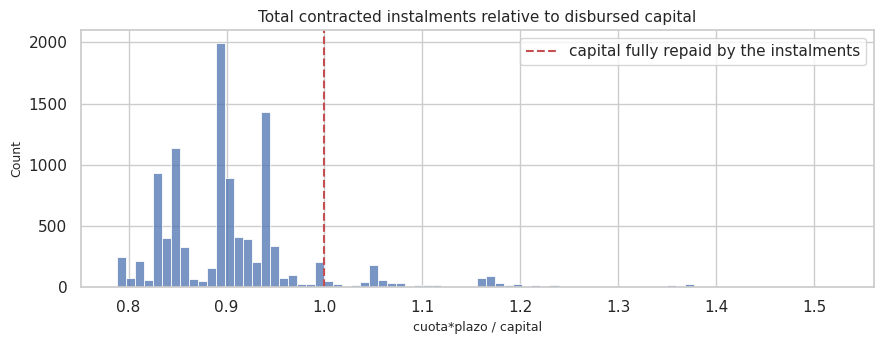

In [17]:
ratio = (inst_total / df["capital_prestado"]).rename("cuota*plazo / capital")
display(ratio.describe().to_frame().T)

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.histplot(ratio, bins=80, ax=ax, color="#4c72b0")
ax.axvline(1.0, color="#c44e52", ls="--", lw=1.5, label="capital fully repaid by the instalments")
ax.set_title("Total contracted instalments relative to disbursed capital")
ax.legend()
show_fig(fig, "02_instalment_coverage")
plt.show()

### 2.6 Range validation rules

In [18]:
rule_rows = []
for col, bounds in RULES.items():
    s = pd.to_numeric(df[col], errors="coerce")
    below, above = (s < bounds["min"]), (s > bounds["max"])
    rule_rows.append({
        "variable": col, "rule_min": bounds["min"], "rule_max": bounds["max"],
        "observed_min": s.min(), "observed_max": s.max(),
        "n_below": int(below.sum()), "n_above": int(above.sum()),
        "pct_out_of_range": float((below | above).mean()),
    })
validation = pd.DataFrame(rule_rows).set_index("variable")
validation.sort_values("pct_out_of_range", ascending=False)

,rule_min,rule_max,observed_min,observed_max,n_below,n_above,pct_out_of_range
variable,,,,,,,
salario_cliente,1000000,100000000,0.0000,"22,000,000,000.0000",112,74,0.0173
edad_cliente,18,90,19.0000,123.0000,0,150,0.0139
puntaje,0,100,-38.0100,95.2278,135,0,0.0125
total_otros_prestamos,0,500000000,0.0000,"6,787,675,263.0000",0,22,0.0020
puntaje_datacredito,150,950,-7.0000,999.0000,2,6,0.0007
plazo_meses,1,60,2.0000,90.0000,0,1,0.0001
cant_creditosvigentes,0,40,0.0000,62.0000,0,1,0.0001
capital_prestado,100000,50000000,"360,000.0000","41,444,153.0000",0,0,0.0000
cuota_pactada,10000,5000000,"23,944.0000","3,816,752.0000",0,0,0.0000


In [19]:
out_of_range = pd.DataFrame(index=df.index)
for col, bounds in RULES.items():
    s = pd.to_numeric(df[col], errors="coerce")
    out_of_range[col] = (s < bounds["min"]) | (s > bounds["max"])

# Violations per rule, split by target. A rule whose violations are 100% one class
# is not a data-quality signal, it is a leakage channel.
per_rule = pd.DataFrame({
    "n_violations": out_of_range.sum(),
    "n_defaults_among_violations": out_of_range.apply(lambda v: (v & df[TARGET].eq(0)).sum()),
})
per_rule["pct_defaults_among_violations"] = (
    per_rule["n_defaults_among_violations"] / per_rule["n_violations"].replace(0, np.nan))
display(per_rule)

# The count used as a FEATURE must exclude the leakage columns; the table above
# keeps every rule for data-quality reporting.
safe_rules = [c for c in out_of_range.columns if c not in CFG["leakage_columns"]]
df["n_reglas_violadas"] = out_of_range[safe_rules].sum(axis=1)
df["n_reglas_violadas_todas"] = out_of_range.sum(axis=1)

print("rules used for the calculated variable:", safe_rules)
print("\nrows violating >= 1 safe rule:", int((df['n_reglas_violadas'] > 0).sum()))
print(df["n_reglas_violadas"].value_counts().sort_index().to_string())
print("\nSpearman vs target — all rules:",
      f"{stats.spearmanr(df['n_reglas_violadas_todas'], df[TARGET]).statistic:.4f}")
print("Spearman vs target — leakage-free rules:",
      f"{stats.spearmanr(df['n_reglas_violadas'], df[TARGET]).statistic:.4f}")

,n_violations,n_defaults_among_violations,pct_defaults_among_violations
edad_cliente,150,11,0.0733
puntaje_datacredito,8,0,0.0000
puntaje,135,135,1.0000
salario_cliente,186,9,0.0484
capital_prestado,0,0,<NA>
plazo_meses,1,0,0.0000
cuota_pactada,0,0,<NA>
total_otros_prestamos,22,2,0.0909
cant_creditosvigentes,1,0,0.0000
huella_consulta,0,0,<NA>


rules used for the calculated variable: ['edad_cliente', 'puntaje_datacredito', 'salario_cliente', 'capital_prestado', 'plazo_meses', 'cuota_pactada', 'total_otros_prestamos', 'cant_creditosvigentes', 'huella_consulta']

rows violating >= 1 safe rule: 277
n_reglas_violadas
0    10486
1      207
2       49
3       21

Spearman vs target — all rules: -0.2868
Spearman vs target — leakage-free rules: -0.0079


### 2.7 Removal of irrelevant variables

In [20]:
variance_check = pd.DataFrame({
    "n_unique": df.nunique(dropna=True),
    "pct_missing": df.isna().mean(),
    "top_value_share": df.apply(
        lambda s: s.value_counts(normalize=True, dropna=True).iloc[0] if s.notna().any() else np.nan),
}).sort_values("top_value_share", ascending=False)
variance_check.head(12)

,n_unique,pct_missing,top_value_share
saldo_mora_codeudor,4,0.0548,0.9997
saldo_mora,55,0.0145,0.9948
n_reglas_violadas,4,0.0000,0.9743
n_reglas_violadas_todas,4,0.0000,0.9623
Pago_atiempo,2,0.0000,0.9525
puntaje,248,0.0000,0.8740
creditos_sectorCooperativo,11,0.0000,0.8239
tipo_credito,6,0.0000,0.7198
tendencia_ingresos,3,0.2778,0.6811
tipo_laboral,2,0.0000,0.6275


In [21]:
DROP = CFG["drop_columns"]
print("dropping:", DROP)
for col in DROP:
    print(f"  {col}: non-zero values = {int((df[col] > 0).sum())} / {int(df[col].notna().sum())} non-null")

df = df.drop(columns=DROP)
print("\nshape after drop:", df.shape)

dropping: ['saldo_mora_codeudor']
  saldo_mora_codeudor: non-zero values = 3 / 10173 non-null

shape after drop: (10763, 25)


## 3. Exploratory data analysis

### 3.1 Univariate analysis

In [22]:
NUM_COLS = [c for c in SCHEMA["monetary"] + SCHEMA["counts_discrete"] + SCHEMA["scores"]
            if c in df.columns]
CAT_COLS = SCHEMA["categorical_nominal"] + SCHEMA["categorical_ordinal"]

describe_extended(df[NUM_COLS])

,count,mean,std,min,25%,50%,75%,max,range,IQR,variance,CV,skew,kurtosis,n_missing,pct_missing,n_unique,n_zeros
capital_prestado,"10,763.0000","2,434,314.9971","1,909,642.7570","360,000.0000","1,224,831.0000","1,921,920.0000","3,084,840.0000","41,444,153.0000","41,084,153.0000","1,860,009.0000","3,646,735,459,455.0166",0.7845,3.7239,35.3181,0,0.0000,7306,0
salario_cliente,"10,763.0000","17,216,431.4599","355,476,717.6035",0.0000,"2,000,000.0000","3,000,000.0000","4,875,808.0000","22,000,000,000.0000","22,000,000,000.0000","2,875,808.0000","126,363,696,758,151,536.0000",20.6475,43.7767,"2,211.2301",0,0.0000,1385,24
total_otros_prestamos,"10,763.0000","6,238,869.6485","118,418,316.9411",0.0000,"500,000.0000","1,000,000.0000","2,000,000.0000","6,787,675,263.0000","6,787,675,263.0000","1,500,000.0000","14,022,897,787,155,510.0000",18.9807,38.4639,"1,719.2809",0,0.0000,1538,445
cuota_pactada,"10,763.0000","243,617.4067","210,493.6946","23,944.0000","121,041.5000","182,863.0000","287,833.5000","3,816,752.0000","3,792,808.0000","166,792.0000","44,307,595,469.5811",0.8640,3.7933,26.6508,0,0.0000,9836,0
saldo_mora,"10,607.0000","7,746.0168","225,955.1173",0.0000,0.0000,0.0000,0.0000,"12,534,000.0000","12,534,000.0000",0.0000,"51,055,715,045.1873",29.1705,40.5685,"1,845.7128",156,0.0145,55,10552
saldo_total,"10,607.0000","45,937,408.1267","106,269,789.9161",0.0000,"2,898,000.0000","16,178,000.0000","52,982,000.0000","5,116,066,000.0000","5,116,066,000.0000","50,084,000.0000","11,293,268,248,808,598.0000",2.3134,20.1977,789.1667,156,0.0145,8858,789
saldo_principal,"10,358.0000","40,346,168.1792","71,242,440.3321",0.0000,"2,690,000.0000","14,442,500.0000","47,632,250.0000","1,562,285,000.0000","1,562,285,000.0000","44,942,250.0000","5,075,485,304,476,057.0000",1.7658,5.0502,51.0638,405,0.0376,8647,633
promedio_ingresos_datacredito,"7,833.0000","2,005,156.8118","2,144,116.1503",0.0000,"925,157.0000","1,204,496.0000","2,231,859.0000","38,106,581.0000","38,106,581.0000","1,306,702.0000","4,597,234,066,129.4668",1.0693,4.2802,32.7707,2930,0.2722,5309,7
plazo_meses,"10,763.0000",10.5756,6.6321,2.0000,6.0000,10.0000,12.0000,90.0000,88.0000,6.0000,43.9845,0.6271,2.4597,7.7801,0,0.0000,18,0
edad_cliente,"10,763.0000",43.9486,15.0609,19.0000,33.0000,42.0000,53.0000,123.0000,104.0000,20.0000,226.8300,0.3427,1.9344,7.8689,0,0.0000,54,0


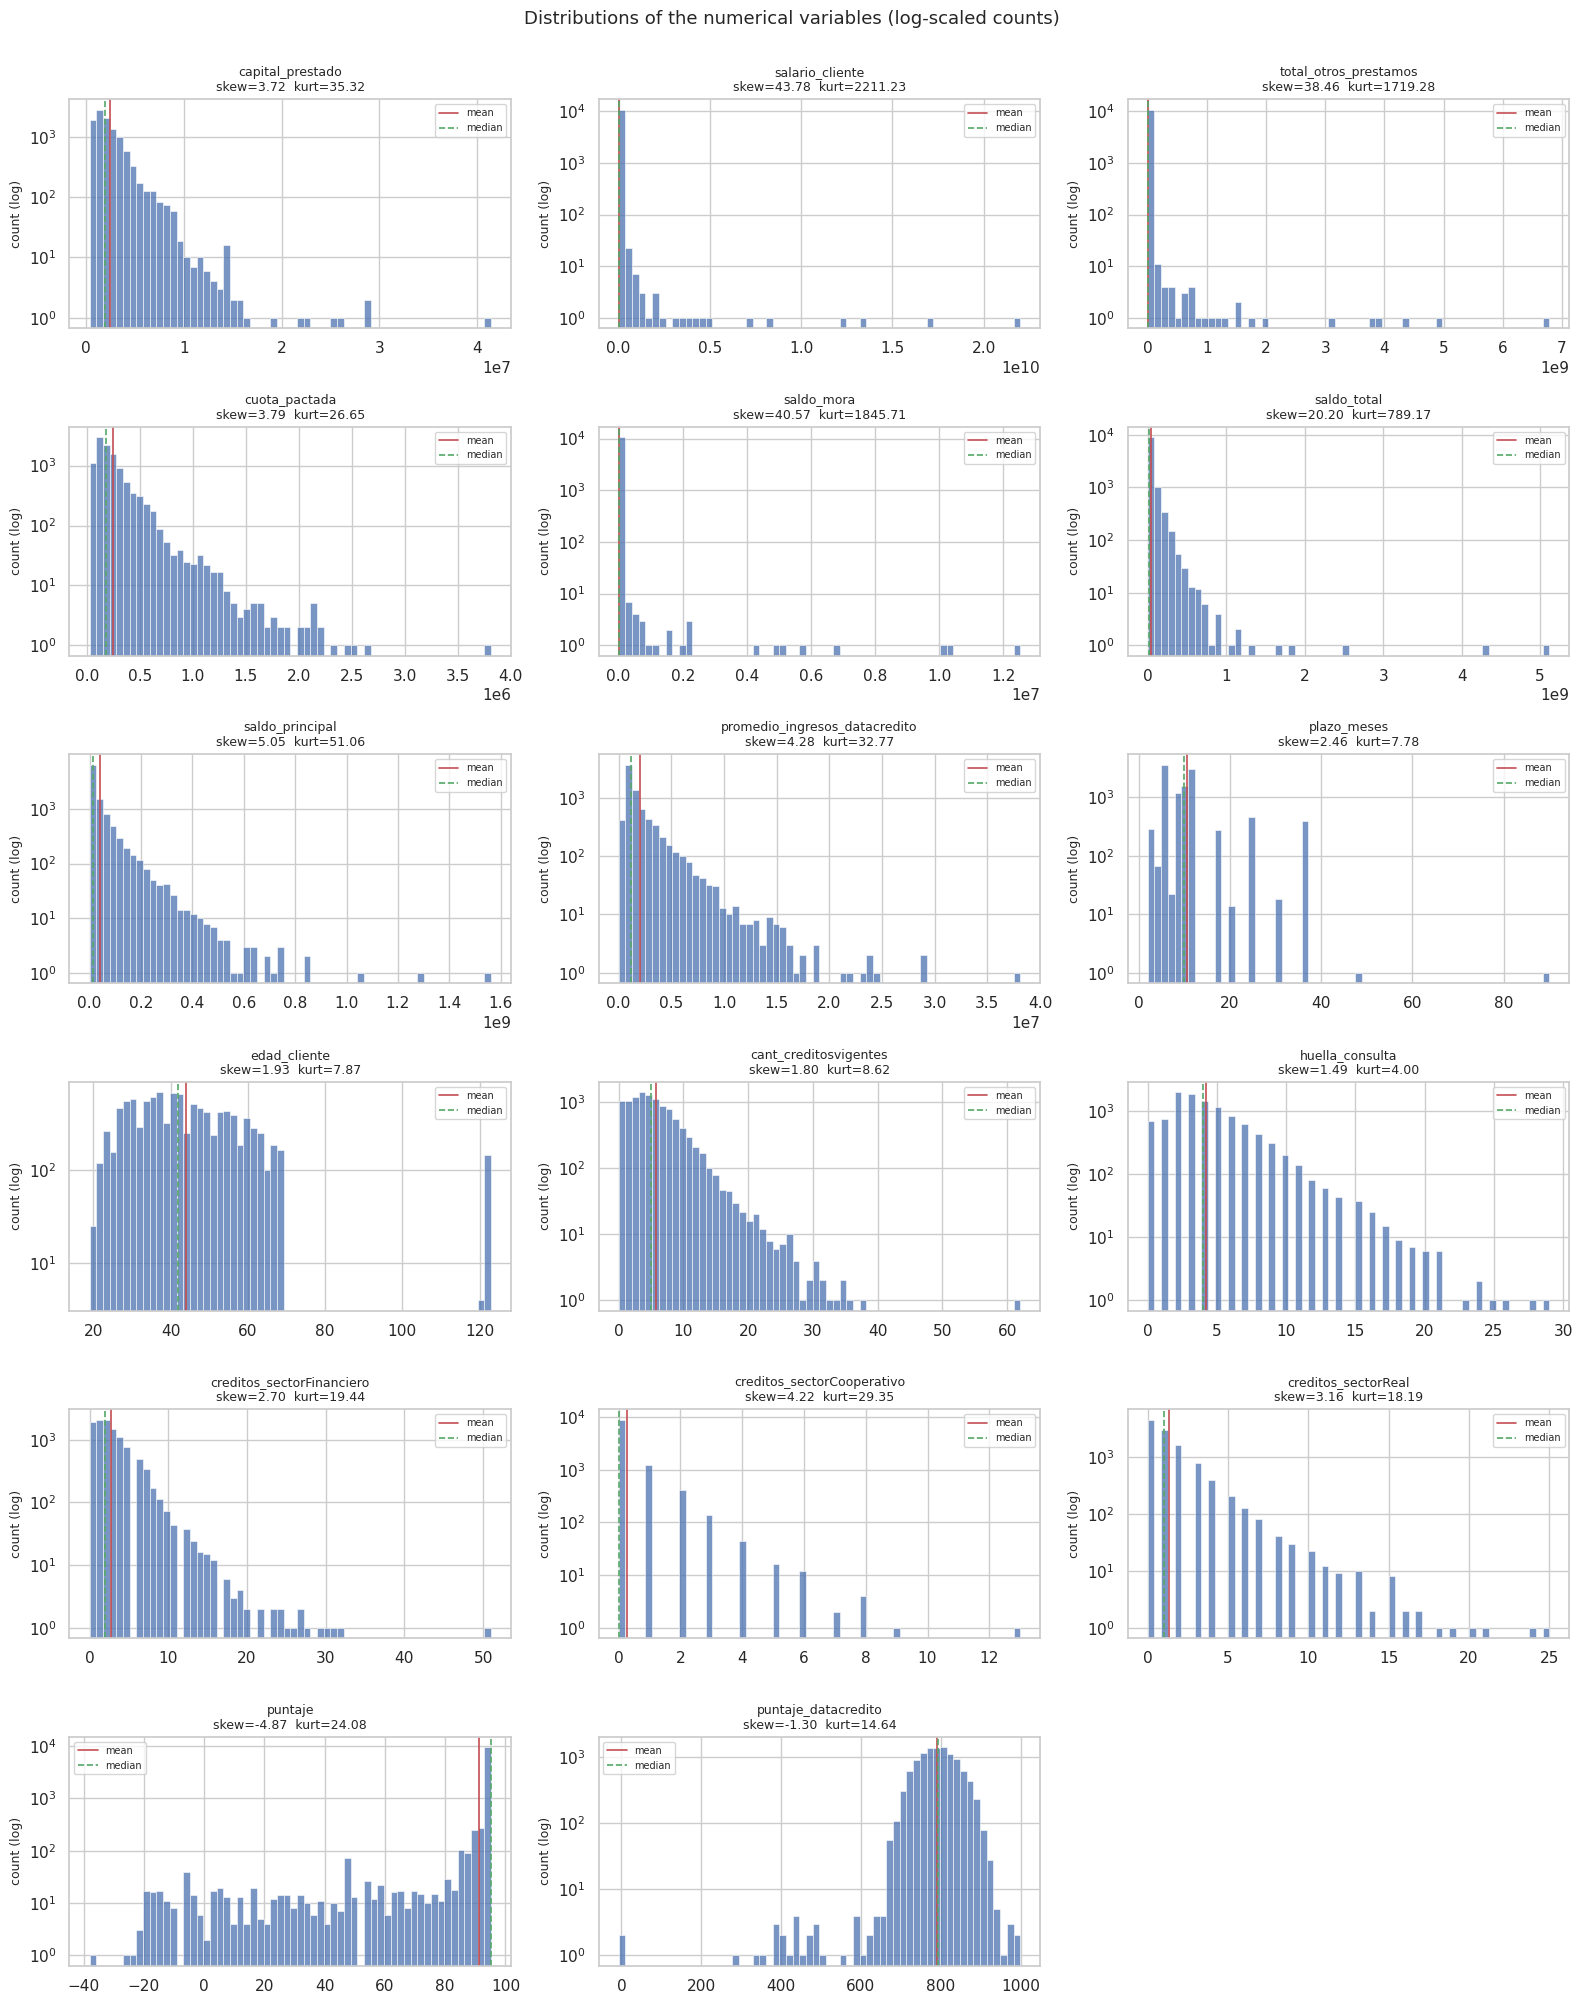

In [23]:
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
for ax, col in zip(axes.ravel(), NUM_COLS):
    s = df[col].astype(float).dropna()
    sns.histplot(s, bins=60, ax=ax, color="#4c72b0", edgecolor=None)
    ax.axvline(s.mean(), color="#c44e52", ls="-", lw=1.2, label="mean")
    ax.axvline(s.median(), color="#55a868", ls="--", lw=1.2, label="median")
    ax.set_yscale("log")
    ax.set_title(f"{col}\nskew={s.skew():.2f}  kurt={s.kurt():.2f}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("count (log)")
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Distributions of the numerical variables (log-scaled counts)", y=1.001, fontsize=13)
show_fig(fig, "03_histograms")
plt.show()

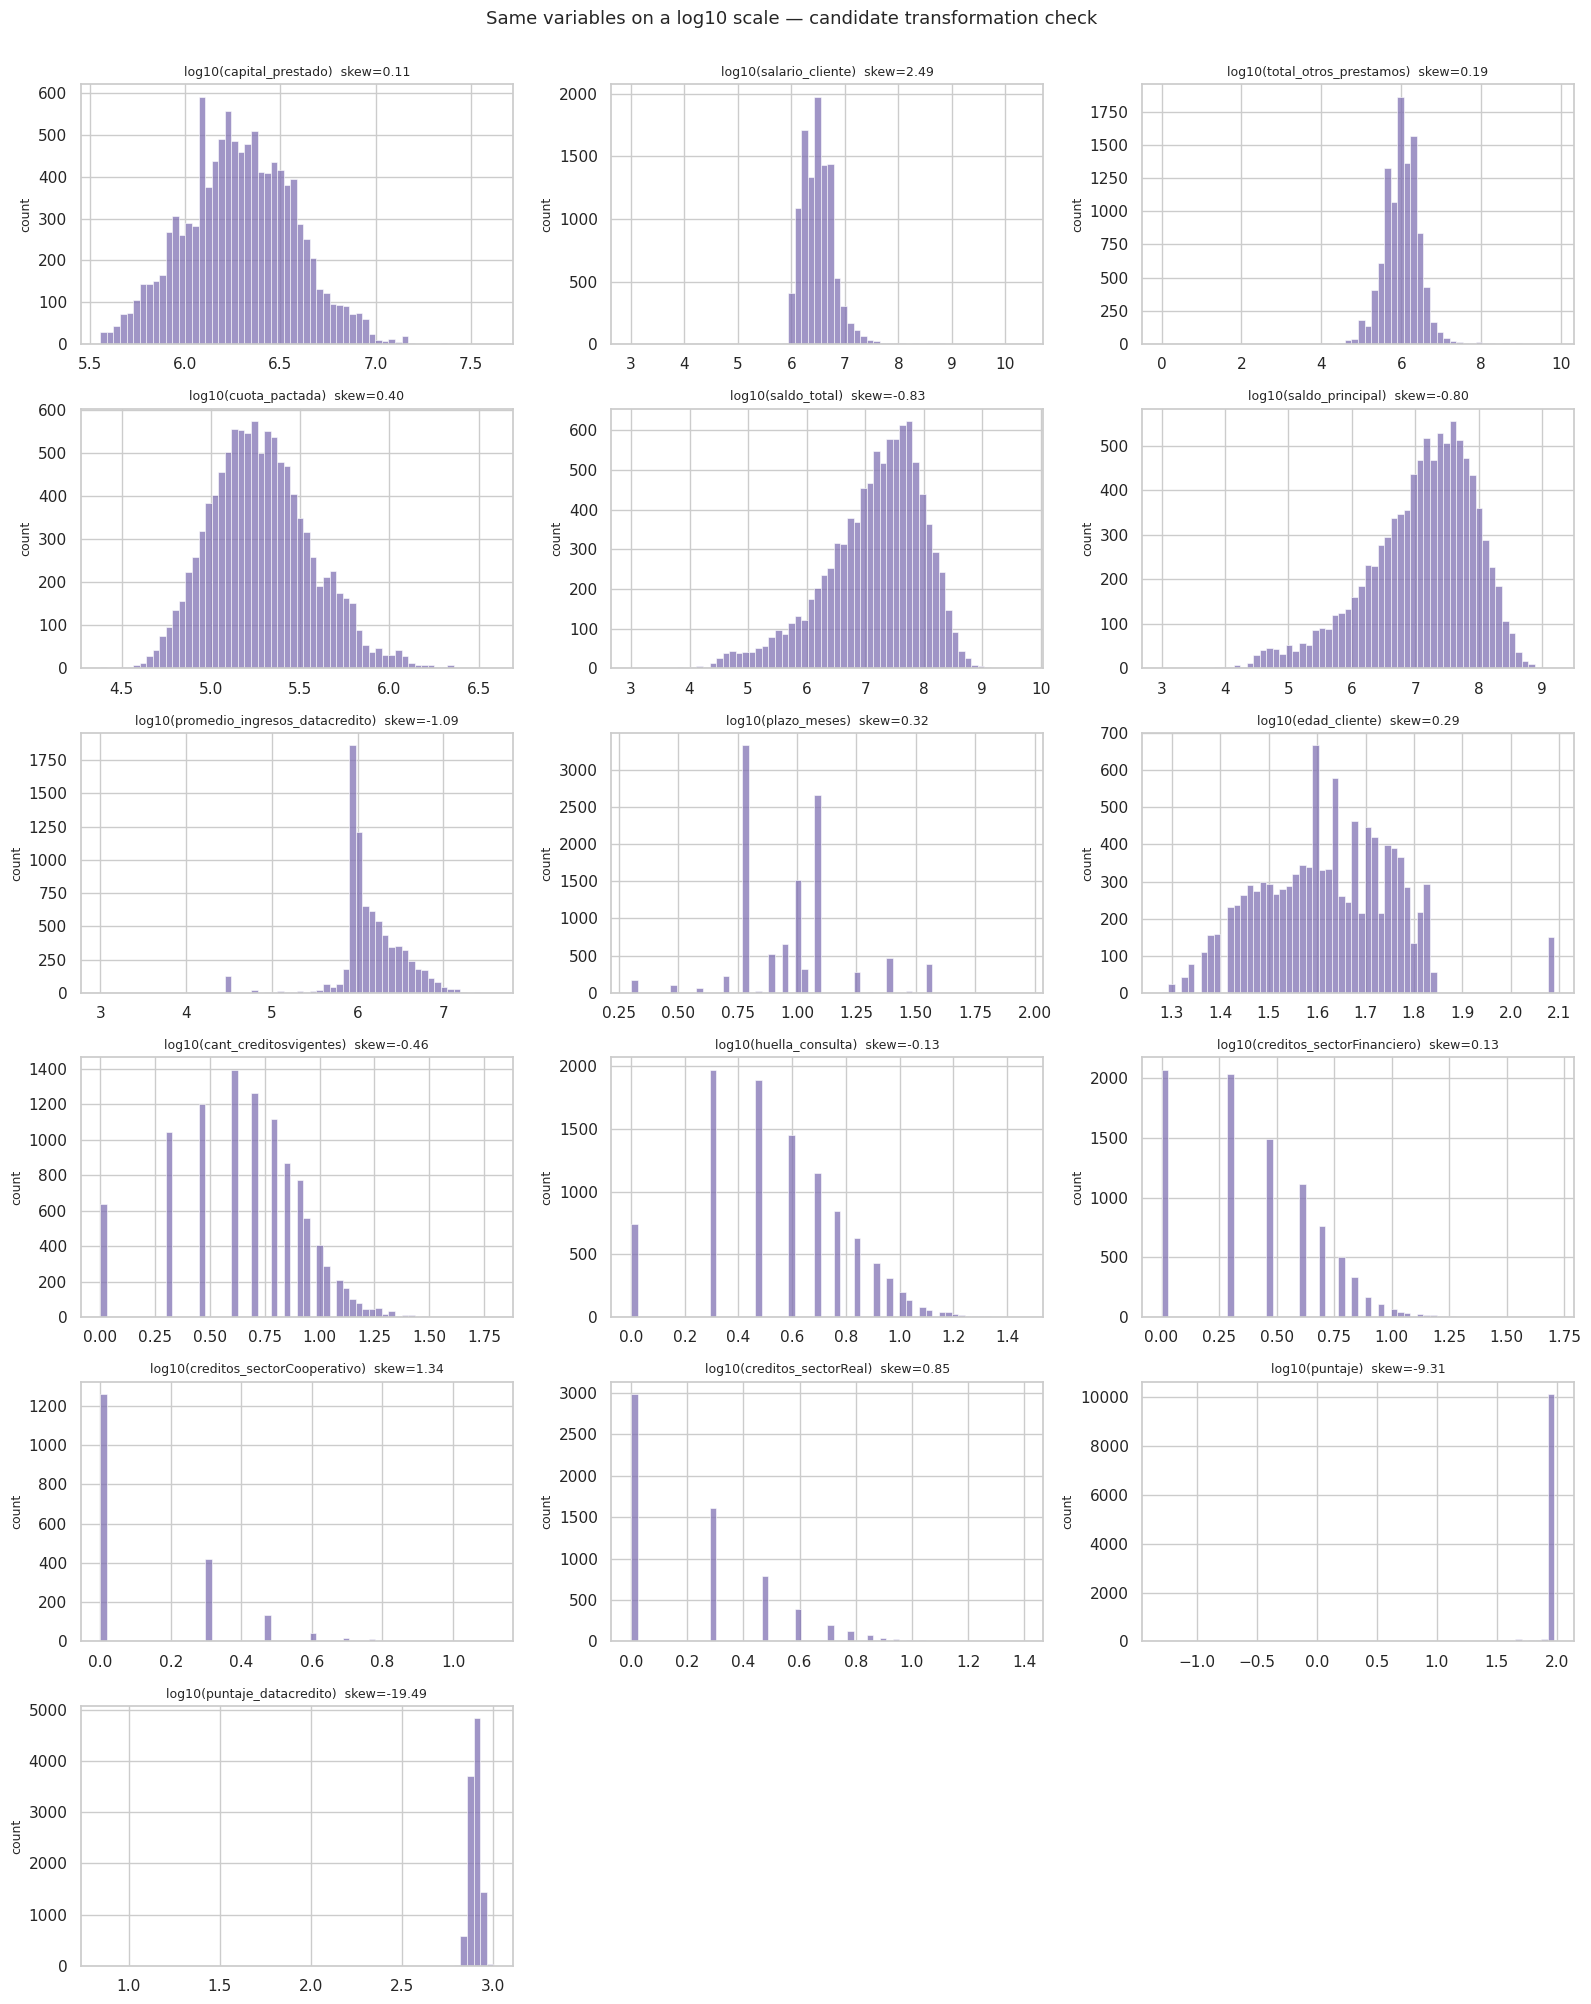

In [24]:
positive = [c for c in NUM_COLS if (df[c].astype(float) > 0).sum() > 200]
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
for ax, col in zip(axes.ravel(), positive):
    s = df[col].astype(float)
    s = s[s > 0]
    sns.histplot(np.log10(s), bins=60, ax=ax, color="#8172b3", edgecolor=None)
    ax.set_title(f"log10({col})  skew={np.log10(s).skew():.2f}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("count")
for ax in axes.ravel()[len(positive):]:
    ax.axis("off")
fig.suptitle("Same variables on a log10 scale — candidate transformation check", y=1.001, fontsize=13)
show_fig(fig, "04_histograms_log")
plt.show()

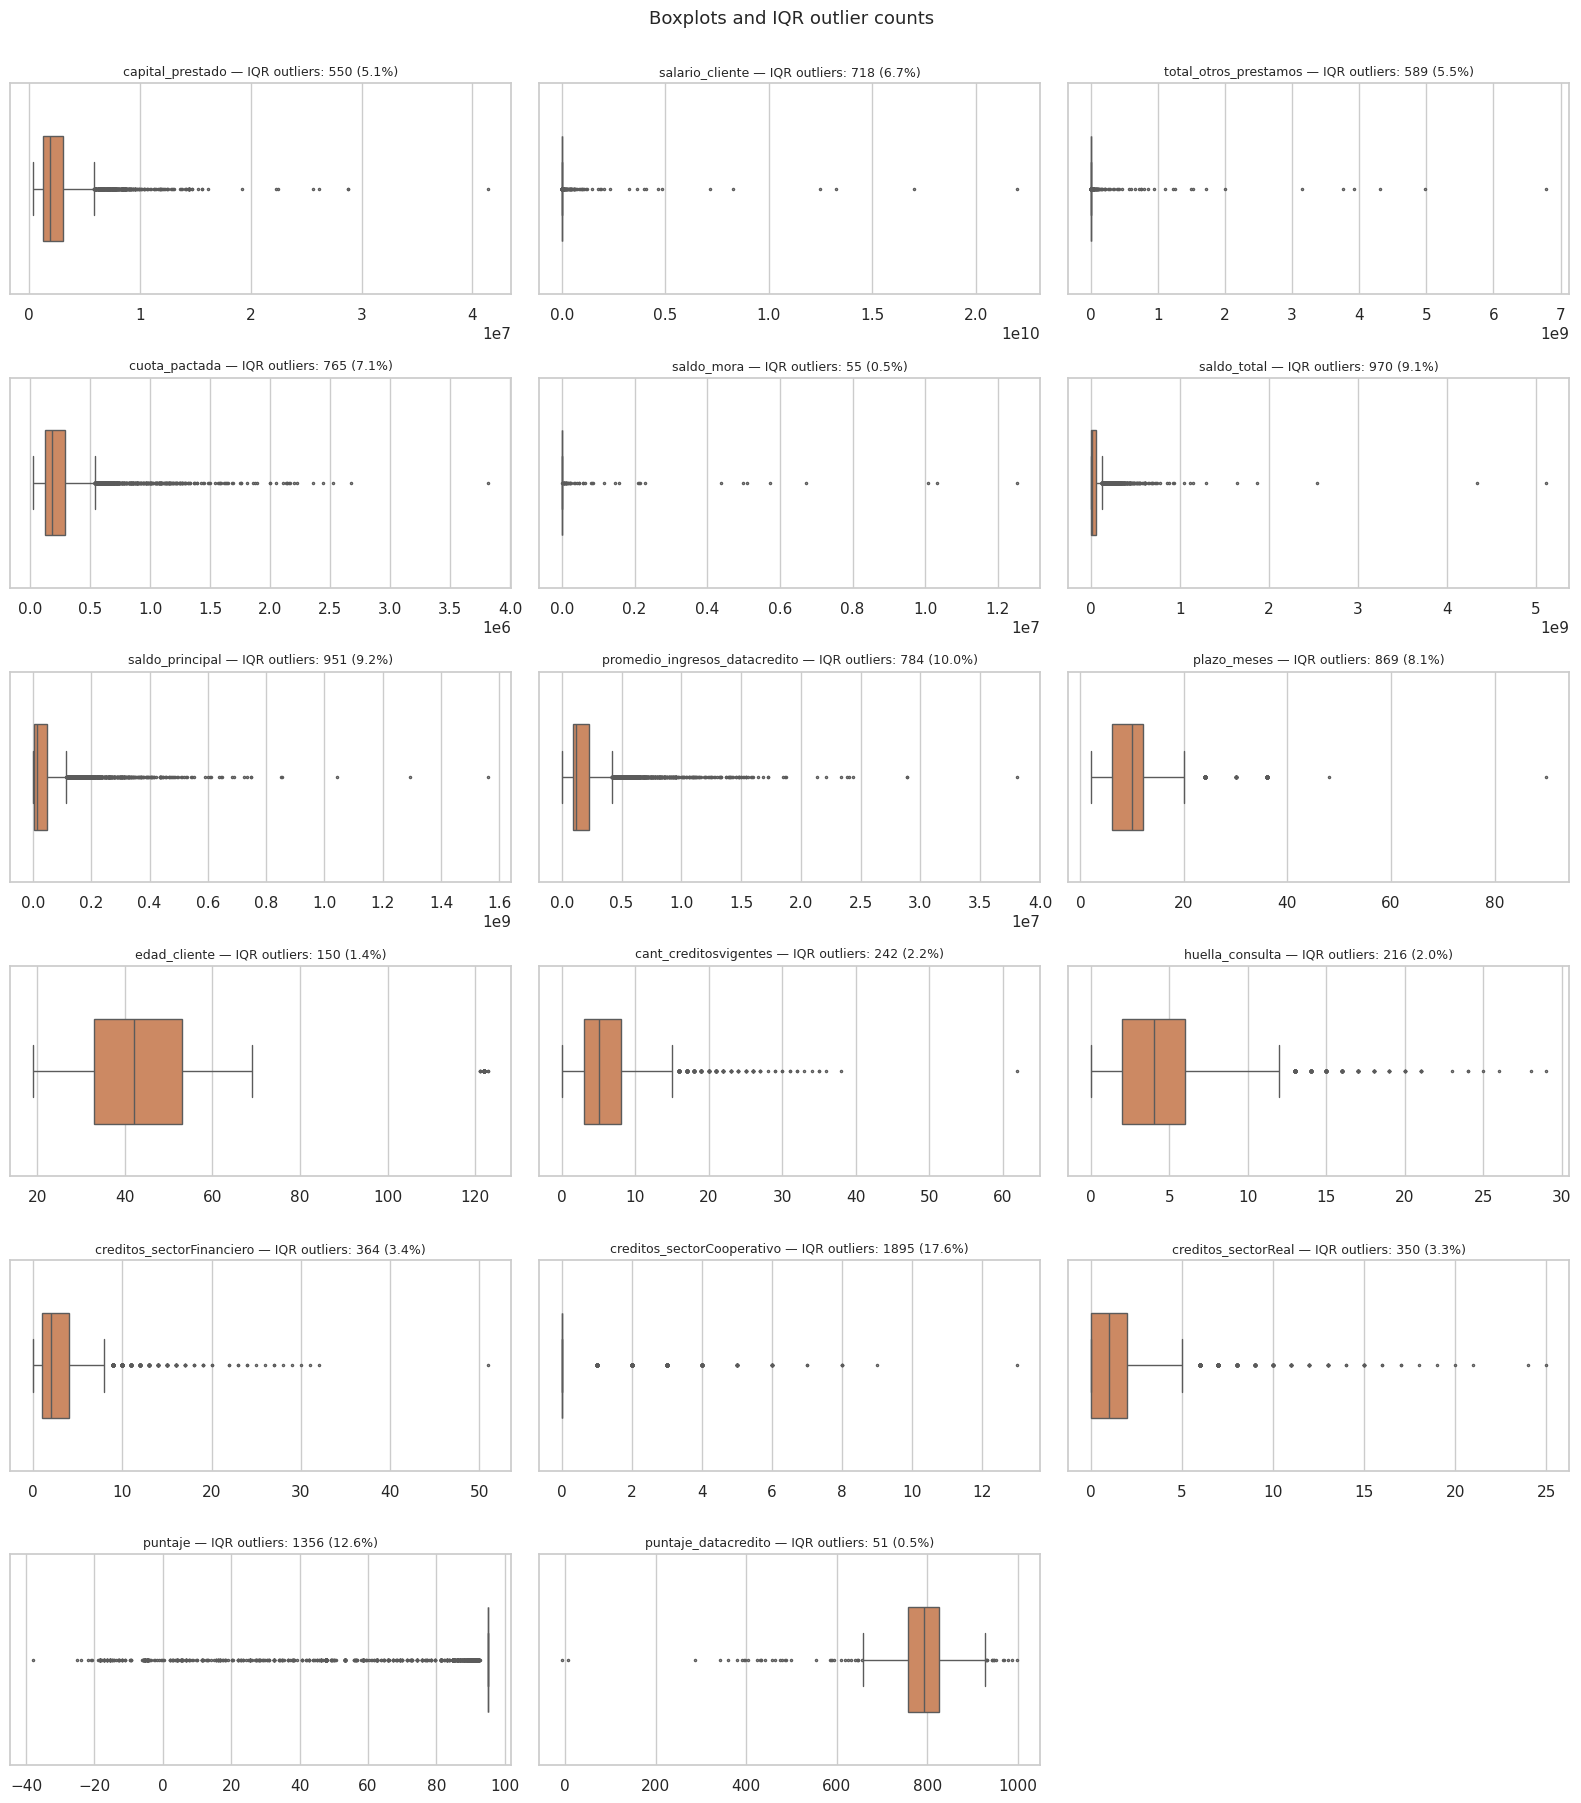

In [25]:
fig, axes = plt.subplots(6, 3, figsize=(16, 18))
for ax, col in zip(axes.ravel(), NUM_COLS):
    s = df[col].astype(float).dropna()
    sns.boxplot(x=s, ax=ax, color="#dd8452", fliersize=1.5, width=.5)
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    n_out = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
    ax.set_title(f"{col} — IQR outliers: {n_out} ({n_out / max(len(s), 1):.1%})", fontsize=9)
    ax.set_xlabel("")
for ax in axes.ravel()[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Boxplots and IQR outlier counts", y=1.001, fontsize=13)
show_fig(fig, "05_boxplots")
plt.show()

In [26]:
tail_table = pd.DataFrame({
    q: df[NUM_COLS].astype(float).quantile(q)
    for q in [0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999, 1.0]
})
tail_table["max / p99"] = tail_table[1.0] / tail_table[0.99].replace(0, np.nan)
tail_table.sort_values("max / p99", ascending=False)

,0.0010,0.0100,0.0500,0.2500,0.5000,0.7500,0.9500,0.9900,0.9990,1.0000,max / p99
salario_cliente,0.0000,"954,263.0000","1,200,000.0000","2,000,000.0000","3,000,000.0000","4,875,808.0000","10,000,000.0000","39,553,562.1800","3,343,833,177.2024","22,000,000,000.0000",556.2078
total_otros_prestamos,0.0000,0.0000,"72,100.0000","500,000.0000","1,000,000.0000","2,000,000.0000","4,798,900.0000","17,946,060.0000","1,231,431,206.0000","6,787,675,263.0000",378.2265
saldo_total,0.0000,0.0000,0.0000,"2,898,000.0000","16,178,000.0000","52,982,000.0000","186,058,700.0000","367,295,260.0000","892,990,362.0001","5,116,066,000.0000",13.9290
saldo_principal,0.0000,0.0000,0.0000,"2,690,000.0000","14,442,500.0000","47,632,250.0000","167,037,650.0000","325,711,870.0000","671,465,171.0001","1,562,285,000.0000",4.7965
capital_prestado,"360,000.0000","468,476.6600","639,708.0000","1,224,831.0000","1,921,920.0000","3,084,840.0000","5,938,828.0000","8,881,109.7600","15,315,104.2020","41,444,153.0000",4.6666
creditos_sectorCooperativo,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,3.0000,6.0000,13.0000,4.3333
creditos_sectorFinanciero,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,7.0000,12.0000,24.0000,51.0000,4.2500
promedio_ingresos_datacredito,"3,714.8160","30,285.0000","607,189.2000","925,157.0000","1,204,496.0000","2,231,859.0000","5,972,733.8000","10,799,234.1600","21,437,126.3760","38,106,581.0000",3.5286
cuota_pactada,"33,874.2520","51,439.9400","71,242.0000","121,041.5000","182,863.0000","287,833.5000","610,395.3000","1,114,004.4200","2,132,993.9440","3,816,752.0000",3.4262
cant_creditosvigentes,0.0000,0.0000,1.0000,3.0000,5.0000,8.0000,13.0000,19.0000,30.2380,62.0000,3.2632


In [27]:
normality = []
for col in NUM_COLS:
    s = df[col].astype(float).dropna()
    sample = s.sample(min(4500, len(s)), random_state=RANDOM_STATE)
    pos = s[s > 0]
    log_sample = np.log10(pos).sample(min(4500, len(pos)), random_state=RANDOM_STATE) if len(pos) > 200 else None
    normality.append({
        "variable": col,
        "shapiro_p_raw": stats.shapiro(sample).pvalue if sample.nunique() > 2 else np.nan,
        "shapiro_p_log10": stats.shapiro(log_sample).pvalue if log_sample is not None and log_sample.nunique() > 2 else np.nan,
        "skew_raw": s.skew(),
        "skew_log10": np.log10(pos).skew() if len(pos) > 200 else np.nan,
    })
normality = pd.DataFrame(normality).set_index("variable")
normality["skew_improved_by_log"] = normality["skew_log10"].abs() < normality["skew_raw"].abs()
normality

,shapiro_p_raw,shapiro_p_log10,skew_raw,skew_log10,skew_improved_by_log
variable,,,,,
capital_prestado,0.0000,0.0000,3.7239,0.1120,True
salario_cliente,0.0000,0.0000,43.7767,2.4886,True
total_otros_prestamos,0.0000,0.0000,38.4639,0.1882,True
cuota_pactada,0.0000,0.0000,3.7933,0.4019,True
saldo_mora,0.0000,NaN,40.5685,NaN,False
saldo_total,0.0000,0.0000,20.1977,-0.8287,True
saldo_principal,0.0000,0.0000,5.0502,-0.8043,True
promedio_ingresos_datacredito,0.0000,0.0000,4.2802,-1.0855,True
plazo_meses,0.0000,0.0000,2.4597,0.3249,True


In [28]:
for col in CAT_COLS:
    vc = df[col].value_counts(dropna=False).to_frame("n")
    vc["pct"] = vc["n"] / len(df)
    print(f"--- {col} ---")
    print(vc.to_string(), "\n")

--- tipo_credito ---
                 n    pct
tipo_credito             
4             7747 0.7198
9             2876 0.2672
10             116 0.0108
6               21 0.0020
7                2 0.0002
68               1 0.0001 

--- tipo_laboral ---
                  n    pct
tipo_laboral              
Empleado       6754 0.6275
Independiente  4009 0.3725 

--- tendencia_ingresos ---
                       n    pct
tendencia_ingresos             
Creciente           5294 0.4919
NaN                 2990 0.2778
Decreciente         1291 0.1199
Estable             1188 0.1104 



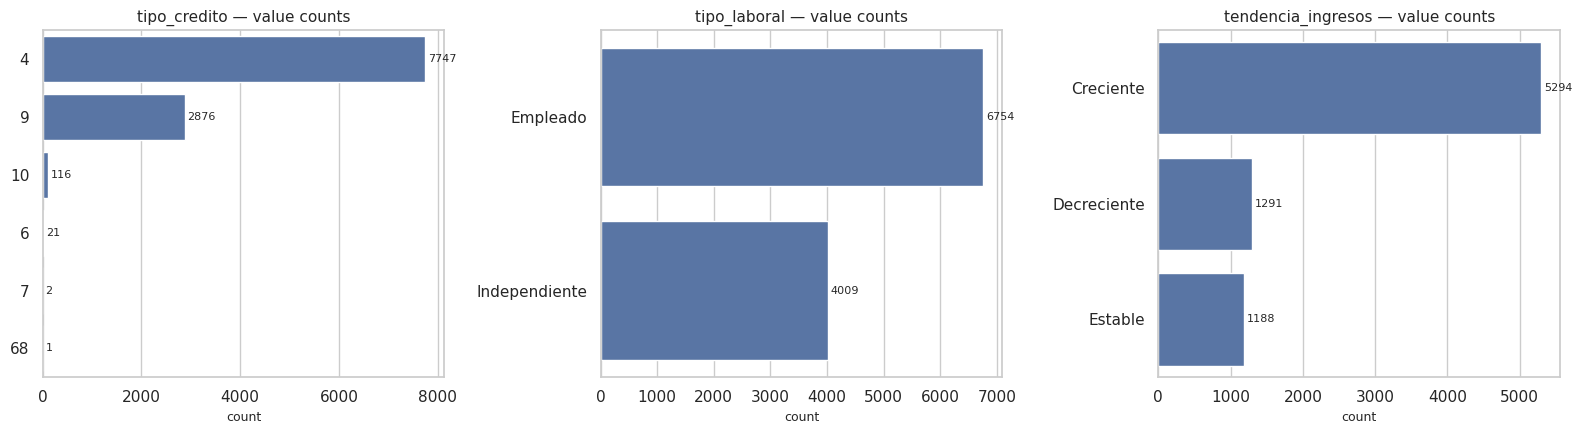

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, CAT_COLS):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#4c72b0")
    for c in ax.containers:
        ax.bar_label(c, fmt="%d", fontsize=8, padding=2)
    ax.set_title(f"{col} — value counts")
    ax.set_ylabel("")
show_fig(fig, "06_countplots")
plt.show()

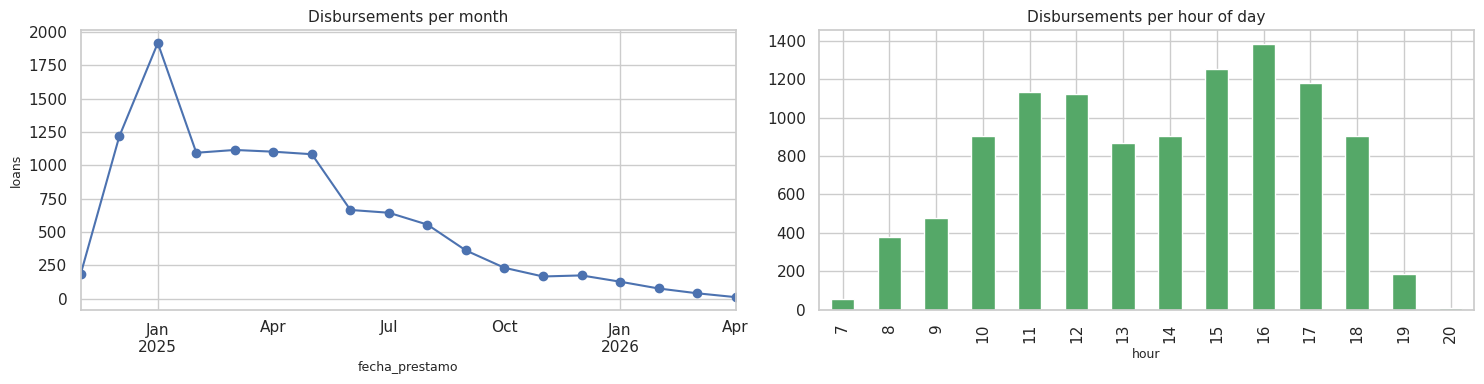

min   2024-11-26 09:17:00
max   2026-04-26 18:43:00


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
monthly = df.set_index("fecha_prestamo").resample("MS").size()
monthly.plot(ax=axes[0], marker="o", color="#4c72b0")
axes[0].set_title("Disbursements per month"); axes[0].set_ylabel("loans")

hourly = df["fecha_prestamo"].dt.hour.value_counts().sort_index()
hourly.plot.bar(ax=axes[1], color="#55a868")
axes[1].set_title("Disbursements per hour of day"); axes[1].set_xlabel("hour")
show_fig(fig, "07_time_profile")
plt.show()

print(df["fecha_prestamo"].agg(["min", "max"]).to_string())

### 3.2 Bivariate analysis against the target

In [31]:
target_dist = df[TARGET].value_counts().to_frame("n")
target_dist["pct"] = target_dist["n"] / len(df)
target_dist.index = target_dist.index.map({1: "1 = paid on time", 0: "0 = default"})
display(target_dist)
print(f"class imbalance ratio: 1 default per {target_dist['n'].max() / target_dist['n'].min():.1f} on-time loans")

,n,pct
Pago_atiempo,,
1 = paid on time,10252,0.9525
0 = default,511,0.0475


class imbalance ratio: 1 default per 20.1 on-time loans


In [32]:
def rate_by_group(frame, col, min_n=20):
    g = frame.groupby(col, observed=True)[TARGET]
    out = pd.DataFrame({"n": g.size(), "default_rate": 1 - g.mean()})
    out["lift_vs_base"] = out["default_rate"] / (1 - frame[TARGET].mean())
    return out[out["n"] >= min_n].sort_values("default_rate", ascending=False)


for col in CAT_COLS:
    print(f"--- {col} ---")
    print(rate_by_group(df, col).to_string(), "\n")

--- tipo_credito ---
                 n  default_rate  lift_vs_base
tipo_credito                                  
6               21        0.4286        9.0268
9             2876        0.0473        0.9960
4             7747        0.0469        0.9869
10             116        0.0259        0.5447 

--- tipo_laboral ---
                  n  default_rate  lift_vs_base
tipo_laboral                                   
Independiente  4009        0.0551        1.1611
Empleado       6754        0.0429        0.9044 

--- tendencia_ingresos ---
                       n  default_rate  lift_vs_base
tendencia_ingresos                                  
Decreciente         1291        0.0627        1.3215
Estable             1188        0.0463        0.9751
Creciente           5294        0.0391        0.8236 



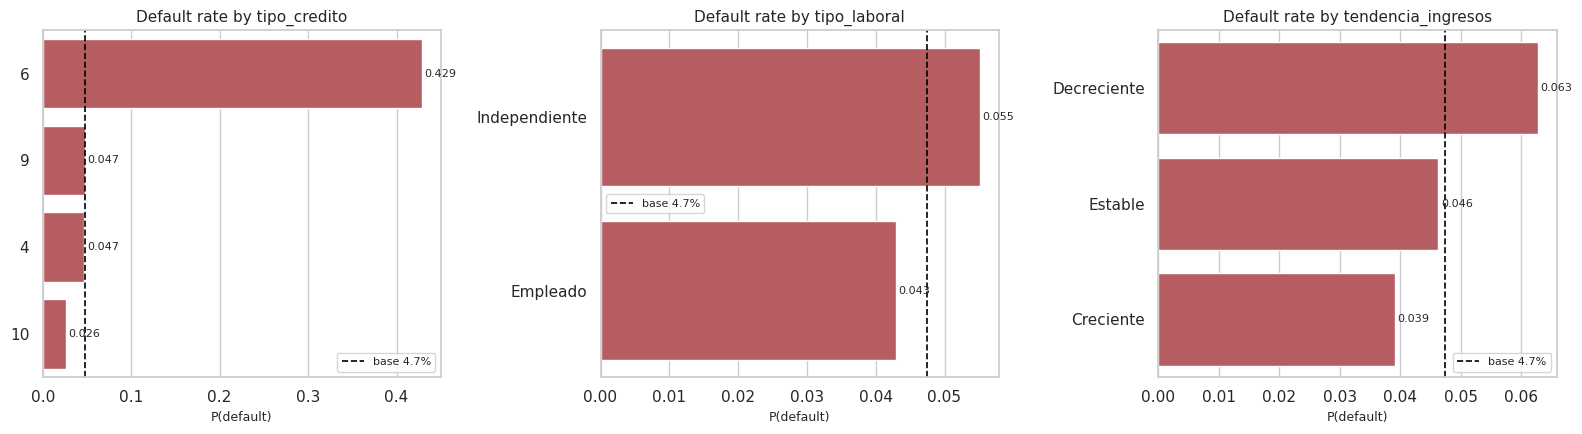

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
base_rate = 1 - df[TARGET].mean()
for ax, col in zip(axes, CAT_COLS):
    t = rate_by_group(df, col)
    sns.barplot(x=t["default_rate"], y=t.index.astype(str), ax=ax, color="#c44e52")
    ax.axvline(base_rate, ls="--", color="black", lw=1.2, label=f"base {base_rate:.1%}")
    for c in ax.containers:
        ax.bar_label(c, fmt="%.3f", fontsize=8, padding=2)
    ax.set_title(f"Default rate by {col}")
    ax.set_xlabel("P(default)"); ax.set_ylabel("")
    ax.legend(fontsize=8)
show_fig(fig, "08_default_rate_categorical")
plt.show()

In [34]:
chi_rows = []
for col in CAT_COLS:
    tab = pd.crosstab(df[col], df[TARGET])
    tab = tab[tab.sum(axis=1) >= 20]
    if len(tab) > 1:
        chi2, p, dof, _ = stats.chi2_contingency(tab)
        cramers_v = np.sqrt(chi2 / (tab.to_numpy().sum() * (min(tab.shape) - 1)))
        chi_rows.append({"variable": col, "chi2": chi2, "dof": dof,
                         "p_value": p, "cramers_v": cramers_v})
pd.DataFrame(chi_rows).set_index("variable")

,chi2,dof,p_value,cramers_v
variable,,,,
tipo_credito,68.6890,3,0.0000,0.0799
tipo_laboral,7.9968,1,0.0047,0.0273
tendencia_ingresos,13.9091,2,0.0010,0.0423


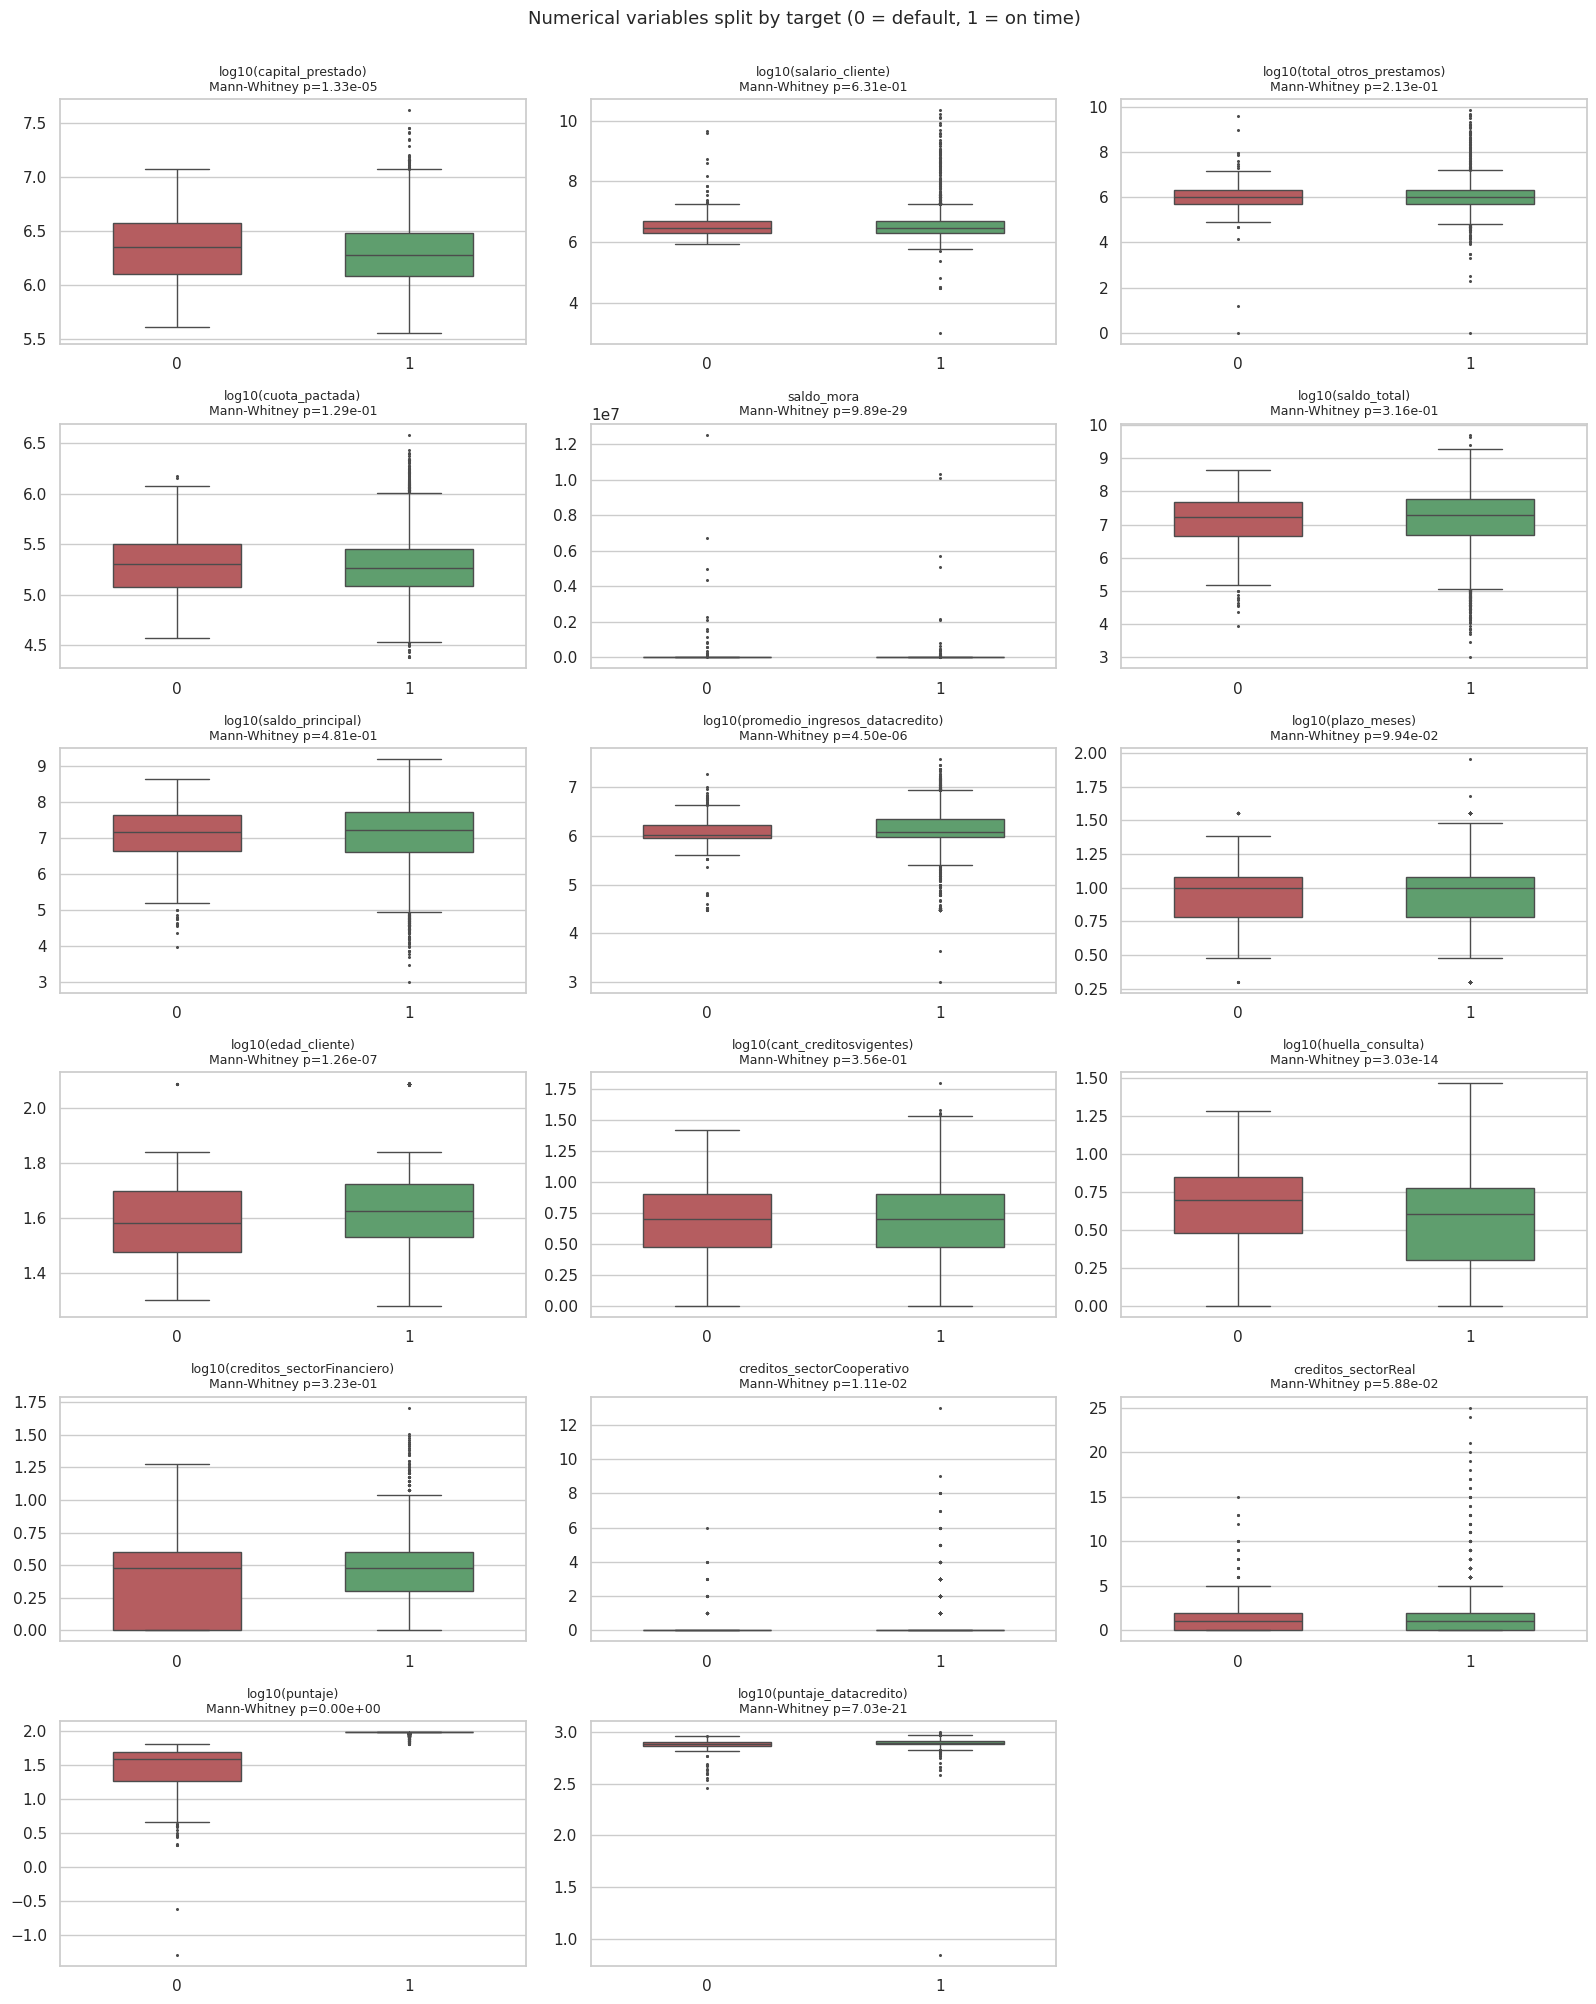

In [35]:
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
for ax, col in zip(axes.ravel(), NUM_COLS):
    s = df[col].astype(float)
    plot_df = pd.DataFrame({col: s, TARGET: df[TARGET]}).dropna()
    if (plot_df[col] > 0).mean() > .8:
        plot_df = plot_df[plot_df[col] > 0]
        plot_df[col] = np.log10(plot_df[col])
        label = f"log10({col})"
    else:
        label = col
    sns.boxplot(data=plot_df, x=TARGET, y=col, ax=ax, palette=["#c44e52", "#55a868"],
                fliersize=1.2, width=.55)
    a = plot_df.loc[plot_df[TARGET] == 1, col]
    b = plot_df.loc[plot_df[TARGET] == 0, col]
    p = stats.mannwhitneyu(a, b).pvalue if min(len(a), len(b)) > 5 else np.nan
    ax.set_title(f"{label}\nMann-Whitney p={p:.2e}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[len(NUM_COLS):]:
    ax.axis("off")
fig.suptitle("Numerical variables split by target (0 = default, 1 = on time)", y=1.001, fontsize=13)
show_fig(fig, "09_boxplot_by_target")
plt.show()

#### 3.2.1 `puntaje` versus the target — separability check

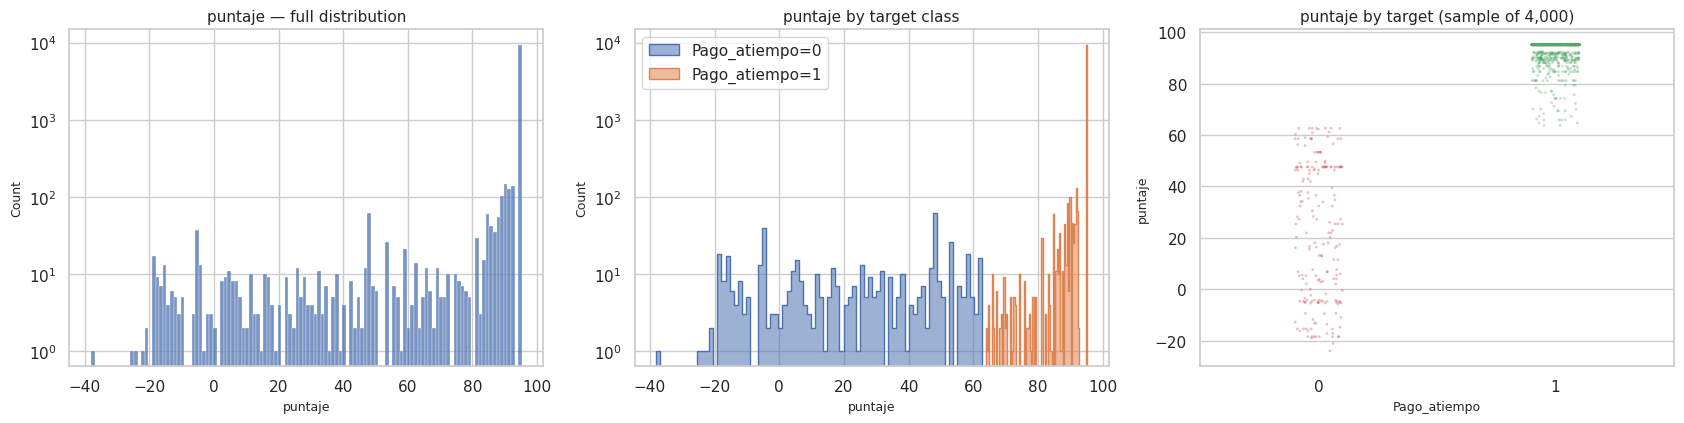

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
sns.histplot(df["puntaje"], bins=120, ax=axes[0], color="#4c72b0")
axes[0].set_yscale("log"); axes[0].set_title("puntaje — full distribution")

for value, group in df.groupby(TARGET):
    sns.histplot(group["puntaje"], bins=80, ax=axes[1], alpha=.55,
                 label=f"{TARGET}={value}", element="step")
axes[1].set_yscale("log"); axes[1].legend(); axes[1].set_title("puntaje by target class")

sns.stripplot(data=df.sample(4000, random_state=RANDOM_STATE), x=TARGET, y="puntaje",
              ax=axes[2], size=2, alpha=.35, palette=["#c44e52", "#55a868"])
axes[2].set_title("puntaje by target (sample of 4,000)")
show_fig(fig, "10_puntaje_separation")
plt.show()

In [37]:
sentinel = CFG["sentinels"]["puntaje"][0]
overlap = pd.DataFrame({
    "metric": ["max puntaje among defaults", "min puntaje among on-time",
               "rows at the sentinel value", "default rate at the sentinel",
               "default rate below the sentinel"],
    "value": [
        df.loc[df[TARGET] == 0, "puntaje"].max(),
        df.loc[df[TARGET] == 1, "puntaje"].min(),
        int(df["puntaje"].eq(sentinel).sum()),
        1 - df.loc[df["puntaje"].eq(sentinel), TARGET].mean(),
        1 - df.loc[df["puntaje"].lt(sentinel), TARGET].mean(),
    ],
})
display(overlap)

cut = (df.loc[df[TARGET] == 0, "puntaje"].max() + df.loc[df[TARGET] == 1, "puntaje"].min()) / 2
print(f"a single threshold at puntaje = {cut:.4f} classifies the target with "
      f"accuracy = {((df['puntaje'] > cut).astype(int) == df[TARGET]).mean():.6f}")

,metric,value
0,max puntaje among defaults,62.6676
1,min puntaje among on-time,63.8097
2,rows at the sentinel value,"9,407.0000"
3,default rate at the sentinel,0.0000
4,default rate below the sentinel,0.3768


a single threshold at puntaje = 63.2386 classifies the target with accuracy = 1.000000


#### 3.2.2 Missingness as a predictor

In [38]:
miss_rows = []
for col in df.columns[df.isna().any()]:
    m = df[col].isna()
    if m.sum() < 30:
        continue
    tab = pd.crosstab(m, df[TARGET])
    chi2, p, *_ = stats.chi2_contingency(tab) if tab.shape == (2, 2) else (np.nan,) * 4
    miss_rows.append({
        "variable": col, "pct_missing": m.mean(),
        "default_rate_when_missing": 1 - df.loc[m, TARGET].mean(),
        "default_rate_when_present": 1 - df.loc[~m, TARGET].mean(),
        "chi2_p": p,
    })
miss_signal = pd.DataFrame(miss_rows).set_index("variable")
miss_signal["ratio"] = (miss_signal["default_rate_when_missing"]
                        / miss_signal["default_rate_when_present"])
miss_signal.sort_values("ratio", ascending=False)

,pct_missing,default_rate_when_missing,default_rate_when_present,chi2_p,ratio
variable,,,,,
delta_ingresos_datacredito,0.9946,0.0477,0.0000,0.1629,inf
puntaje_datacredito,0.0140,0.0728,0.0471,0.1993,1.5461
saldo_principal,0.0376,0.0716,0.0465,0.0272,1.5388
saldo_total,0.0145,0.0705,0.0471,0.2407,1.4959
saldo_mora,0.0145,0.0705,0.0471,0.2407,1.4959
promedio_ingresos_datacredito,0.2722,0.0573,0.0438,0.0038,1.3094
tendencia_ingresos,0.2778,0.0562,0.0441,0.0097,1.2733


### 3.3 Multivariate analysis

#### 3.3.1 All-vs-all correlation: Pearson (linear) and Spearman (monotonic)

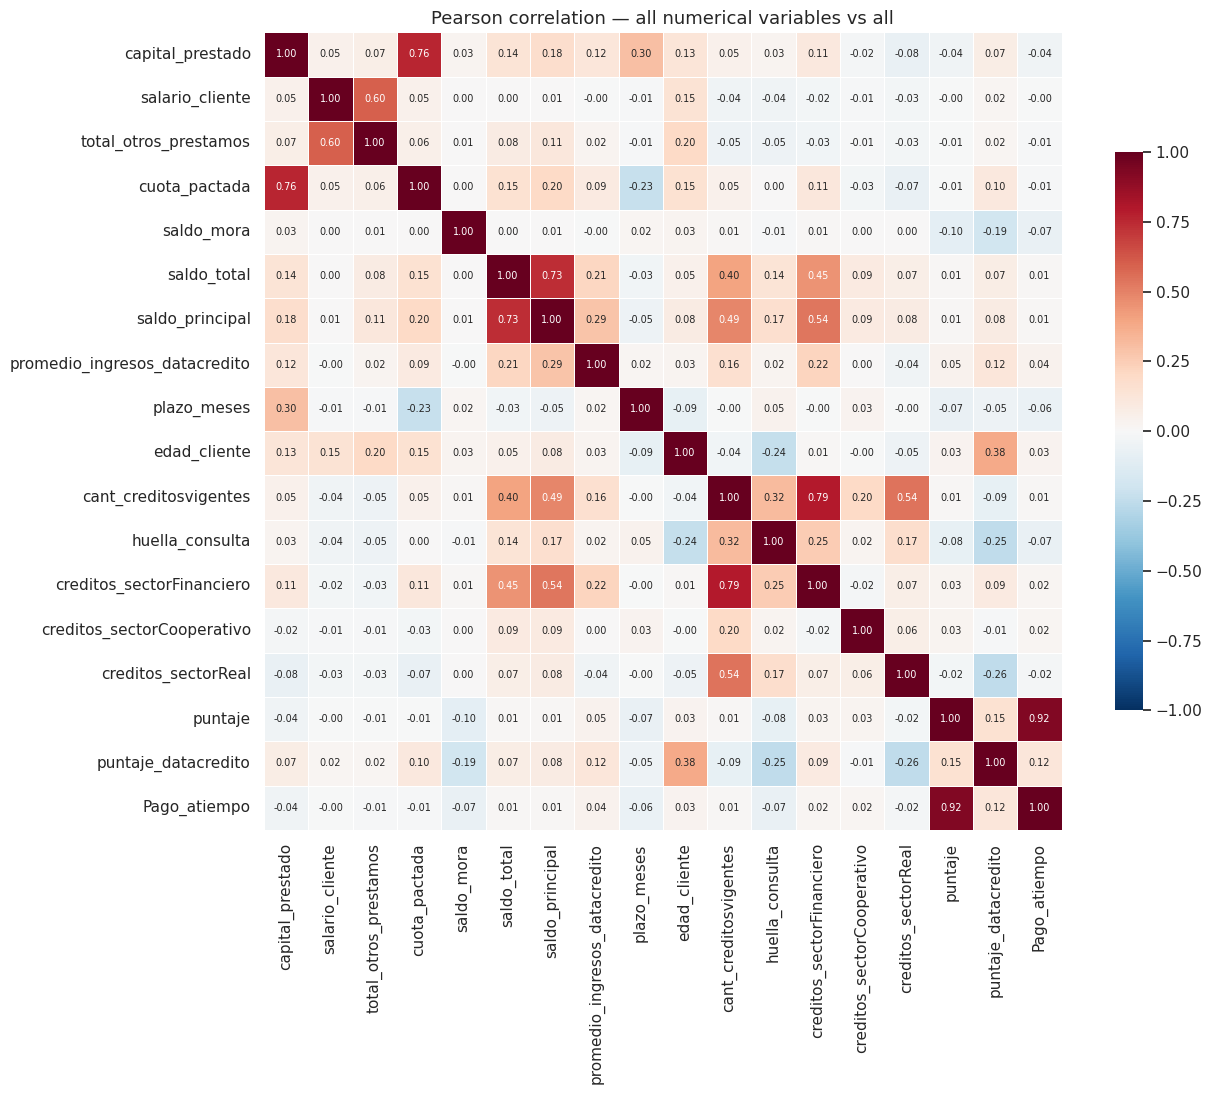

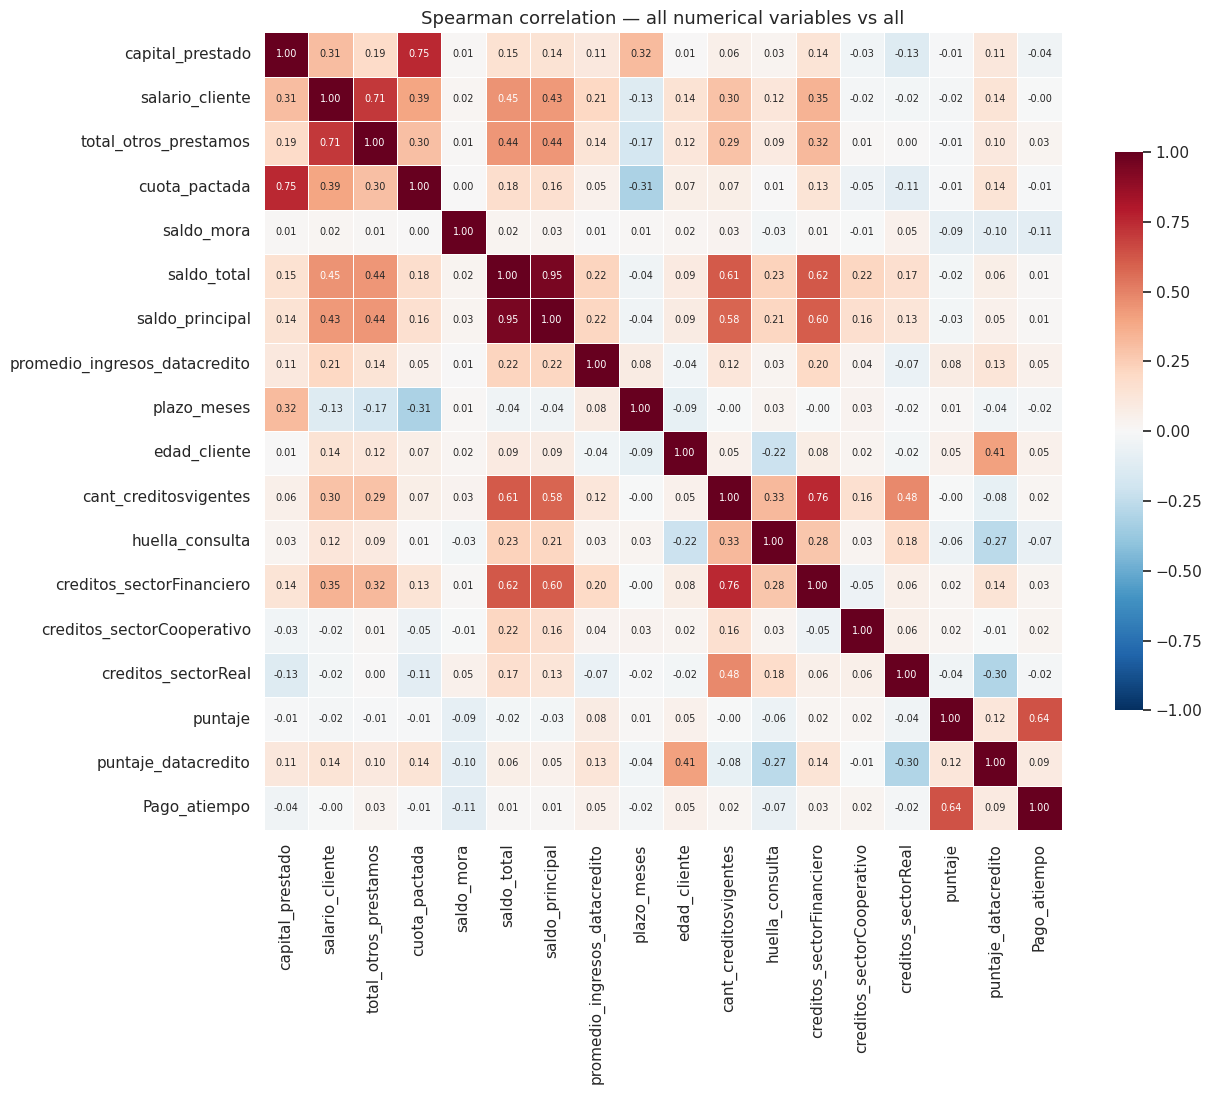

In [39]:
CORR_COLS = NUM_COLS + [TARGET]
num_frame = df[CORR_COLS].astype(float)

pearson = num_frame.corr(method="pearson")
spearman = num_frame.corr(method="spearman")

for name, matrix in [("Pearson", pearson), ("Spearman", spearman)]:
    fig, ax = plt.subplots(figsize=(13.5, 11))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=.5, annot_kws={"size": 7},
                cbar_kws={"shrink": .7}, ax=ax)
    ax.set_title(f"{name} correlation — all numerical variables vs all", fontsize=13)
    show_fig(fig, f"11_corr_{name.lower()}")
    plt.show()

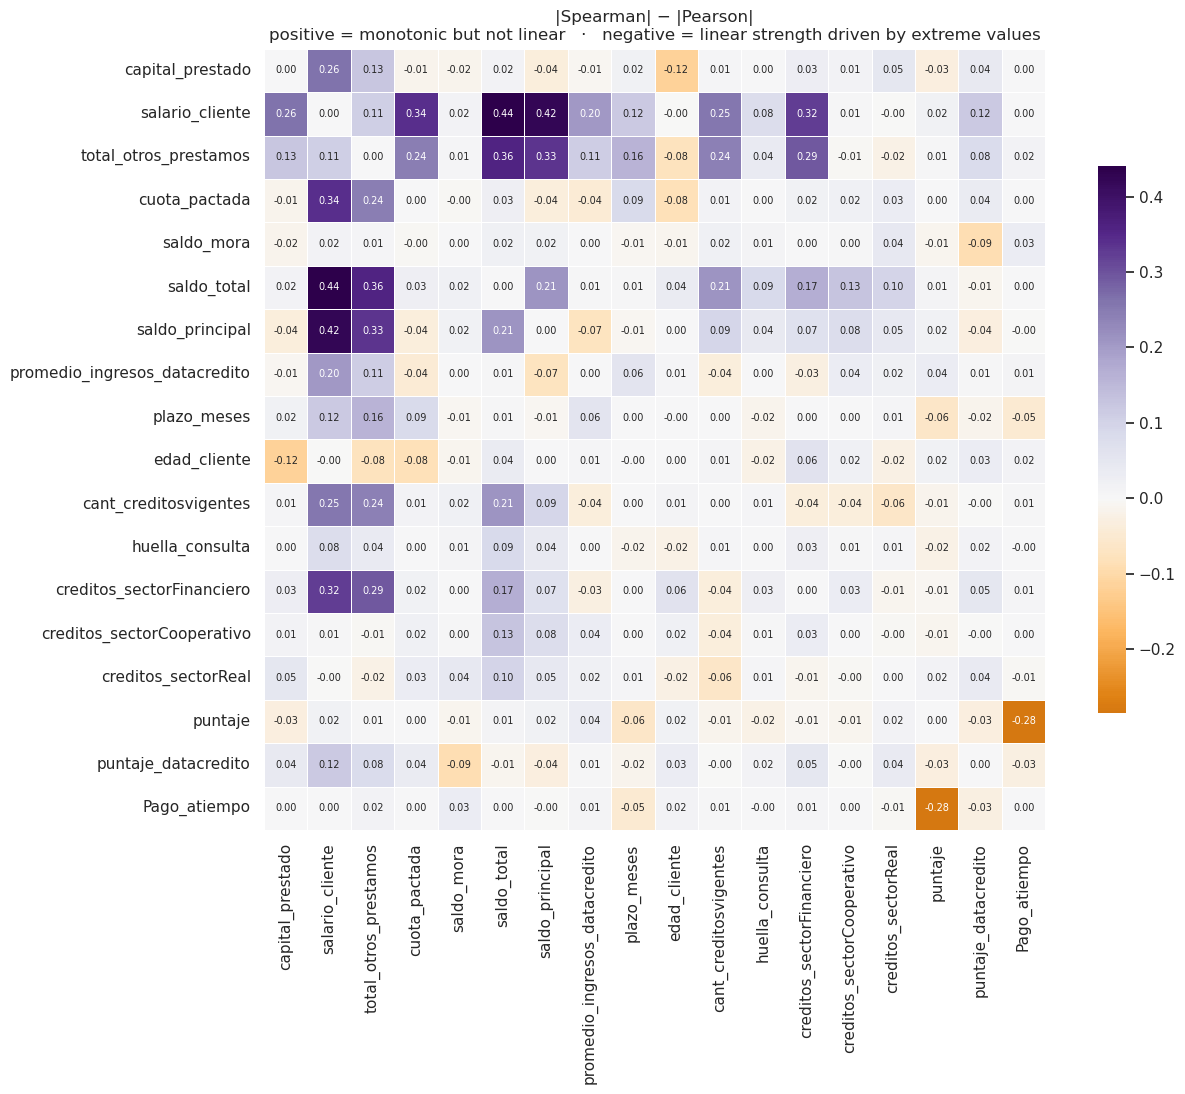

In [40]:
fig, ax = plt.subplots(figsize=(13.5, 11))
gap_matrix = spearman.abs() - pearson.abs()
sns.heatmap(gap_matrix, annot=True, fmt=".2f", cmap="PuOr", center=0,
            square=True, linewidths=.5, annot_kws={"size": 7},
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("|Spearman| − |Pearson|\npositive = monotonic but not linear   ·   "
             "negative = linear strength driven by extreme values", fontsize=12)
show_fig(fig, "12_corr_gap")
plt.show()

In [41]:
def upper_pairs(matrix, name):
    mask = np.triu(np.ones(matrix.shape, dtype=bool), k=1)
    return matrix.where(mask).stack().rename(name)


pairs = pd.concat([upper_pairs(pearson, "pearson"),
                   upper_pairs(spearman, "spearman")], axis=1)
pairs["abs_spearman"] = pairs["spearman"].abs()
pairs["gap"] = pairs["spearman"].abs() - pairs["pearson"].abs()

TOP_N = CFG["eda"]["top_pairs"]
top_monotonic = pairs.sort_values("abs_spearman", ascending=False).head(TOP_N)
top_monotonic.drop(columns="abs_spearman")

pearson  spearman     gap
saldo_total           saldo_principal             0.7347    0.9463  0.2117
cant_creditosvigentes creditos_sectorFinanciero   0.7913    0.7552 -0.0360
capital_prestado      cuota_pactada               0.7641    0.7507 -0.0134
salario_cliente       total_otros_prestamos       0.5970    0.7058  0.1089
puntaje               Pago_atiempo                0.9231    0.6389 -0.2842
saldo_total           creditos_sectorFinanciero   0.4520    0.6215  0.1695
                      cant_creditosvigentes       0.4021    0.6136  0.2115
saldo_principal       creditos_sectorFinanciero   0.5373    0.6045  0.0672
                      cant_creditosvigentes       0.4860    0.5789  0.0929
cant_creditosvigentes creditos_sectorReal         0.5407    0.4781 -0.0626
salario_cliente       saldo_total                 0.0048    0.4454  0.4406
total_otros_prestamos saldo_total                 0.0828    0.4438  0.3611
                      saldo_principal             0.1102    0.4435  0.3333
salario_cliente       saldo_principal             0.0072    0.4308  0.4236
edad_cliente          puntaje_datacredito         0.3797    0.4129  0.0331
salario_cliente       cuota_pactada               0.0524    0.3933  0.3409
                      creditos_sectorFinanciero  -0.0243    0.3474  0.3232
cant_creditosvigentes huella_consulta             0.3176    0.3272  0.0097
total_otros_prestamos creditos_sectorFinanciero  -0.0319    0.3232  0.2912
capital_prestado      plazo_meses                 0.2998    0.3189  0.0192
cuota_pactada         plazo_meses                -0.2272   -0.3126  0.0854
capital_prestado      salario_cliente             0.0470    0.3111  0.2640
total_otros_prestamos cuota_pactada               0.0594    0.3030  0.2435
creditos_sectorReal   puntaje_datacredito        -0.2577   -0.2981  0.0404
salario_cliente       cant_creditosvigentes      -0.0406    0.2956  0.2550

In [42]:
pairs.sort_values("gap", ascending=False).head(15).drop(columns="abs_spearman")

pearson  spearman    gap
salario_cliente       saldo_total                     0.0048    0.4454 0.4406
                      saldo_principal                 0.0072    0.4308 0.4236
total_otros_prestamos saldo_total                     0.0828    0.4438 0.3611
salario_cliente       cuota_pactada                   0.0524    0.3933 0.3409
total_otros_prestamos saldo_principal                 0.1102    0.4435 0.3333
salario_cliente       creditos_sectorFinanciero      -0.0243    0.3474 0.3232
total_otros_prestamos creditos_sectorFinanciero      -0.0319    0.3232 0.2912
capital_prestado      salario_cliente                 0.0470    0.3111 0.2640
salario_cliente       cant_creditosvigentes          -0.0406    0.2956 0.2550
total_otros_prestamos cuota_pactada                   0.0594    0.3030 0.2435
                      cant_creditosvigentes          -0.0502    0.2916 0.2414
saldo_total           saldo_principal                 0.7347    0.9463 0.2117
                      cant_creditosvigentes           0.4021    0.6136 0.2115
salario_cliente       promedio_ingresos_datacredito  -0.0044    0.2074 0.2030
saldo_total           creditos_sectorFinanciero       0.4520    0.6215 0.1695

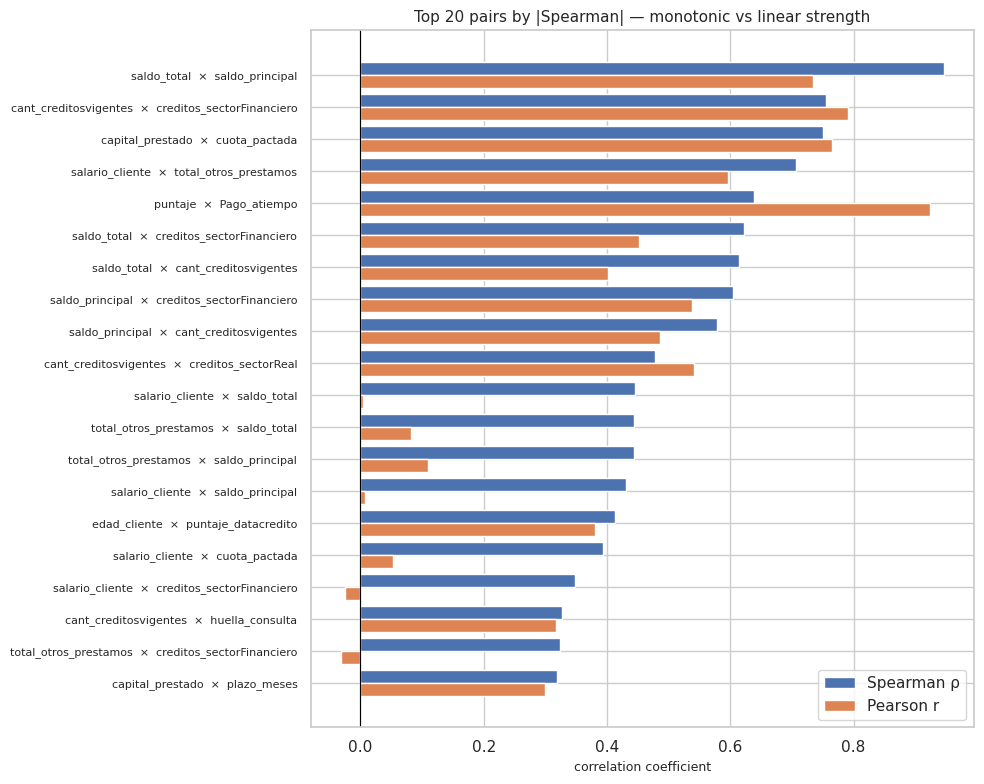

In [43]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_pairs = pairs.sort_values("abs_spearman", ascending=False).head(20).iloc[::-1]
labels = [f"{a}  ×  {b}" for a, b in plot_pairs.index]
ypos = np.arange(len(plot_pairs))
ax.barh(ypos + .2, plot_pairs["spearman"], height=.4, color="#4c72b0", label="Spearman ρ")
ax.barh(ypos - .2, plot_pairs["pearson"], height=.4, color="#dd8452", label="Pearson r")
ax.set_yticks(ypos); ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("correlation coefficient")
ax.set_title("Top 20 pairs by |Spearman| — monotonic vs linear strength")
ax.legend()
show_fig(fig, "13_top_pairs")
plt.show()

In [44]:
# Statistical significance of the monotonic relationships, pairwise-complete.
sig_rows = []
for a, b in top_monotonic.index:
    sub = num_frame[[a, b]].dropna()
    rho, p_rho = stats.spearmanr(sub[a], sub[b])
    r, p_r = stats.pearsonr(sub[a], sub[b])
    tau, p_tau = stats.kendalltau(sub[a], sub[b])
    sig_rows.append({"var_x": a, "var_y": b, "n": len(sub),
                     "spearman_rho": rho, "p_spearman": p_rho,
                     "pearson_r": r, "p_pearson": p_r,
                     "kendall_tau": tau, "p_kendall": p_tau})
pd.DataFrame(sig_rows).set_index(["var_x", "var_y"])

n  spearman_rho  p_spearman  pearson_r  p_pearson  kendall_tau  p_kendall
var_x                 var_y                                                                                                   
saldo_total           saldo_principal            10358        0.9463      0.0000     0.7347     0.0000       0.9091     0.0000
cant_creditosvigentes creditos_sectorFinanciero  10763        0.7552      0.0000     0.7913     0.0000       0.6292     0.0000
capital_prestado      cuota_pactada              10763        0.7507      0.0000     0.7641     0.0000       0.5773     0.0000
salario_cliente       total_otros_prestamos      10763        0.7058      0.0000     0.5970     0.0000       0.5524     0.0000
puntaje               Pago_atiempo               10763        0.6389      0.0000     0.9231     0.0000       0.6195     0.0000
saldo_total           creditos_sectorFinanciero  10607        0.6215      0.0000     0.4520     0.0000       0.4732     0.0000
                      cant_creditosvigentes      10607        0.6136      0.0000     0.4021     0.0000       0.4590     0.0000
saldo_principal       creditos_sectorFinanciero  10358        0.6045      0.0000     0.5373     0.0000       0.4573     0.0000
                      cant_creditosvigentes      10358        0.5789      0.0000     0.4860     0.0000       0.4284     0.0000
cant_creditosvigentes creditos_sectorReal        10763        0.4781      0.0000     0.5407     0.0000       0.3853     0.0000
salario_cliente       saldo_total                10607        0.4454      0.0000     0.0048     0.6225       0.3131     0.0000
total_otros_prestamos saldo_total                10607        0.4438      0.0000     0.0828     0.0000       0.3171     0.0000
                      saldo_principal            10358        0.4435      0.0000     0.1102     0.0000       0.3173     0.0000
salario_cliente       saldo_principal            10358        0.4308      0.0000     0.0072     0.4656       0.3028     0.0000
edad_cliente          puntaje_datacredito        10612        0.4129      0.0000     0.3797     0.0000       0.2862     0.0000
salario_cliente       cuota_pactada              10763        0.3933      0.0000     0.0524     0.0000       0.2748     0.0000
                      creditos_sectorFinanciero  10763        0.3474      0.0000    -0.0243     0.0118       0.2594     0.0000
cant_creditosvigentes huella_consulta            10763        0.3272      0.0000     0.3176     0.0000       0.2451     0.0000
total_otros_prestamos creditos_sectorFinanciero  10763        0.3232      0.0000    -0.0319     0.0009       0.2419     0.0000
capital_prestado      plazo_meses                10763        0.3189      0.0000     0.2998     0.0000       0.2350     0.0000
cuota_pactada         plazo_meses                10763       -0.3126      0.0000    -0.2272     0.0000      -0.2276     0.0000
capital_prestado      salario_cliente            10763        0.3111      0.0000     0.0470     0.0000       0.2151     0.0000
total_otros_prestamos cuota_pactada              10763        0.3030      0.0000     0.0594     0.0000       0.2104     0.0000
creditos_sectorReal   puntaje_datacredito        10612       -0.2981      0.0000    -0.2577     0.0000      -0.2246     0.0000
salario_cliente       cant_creditosvigentes      10763        0.2956      0.0000    -0.0406     0.0000       0.2151     0.0000

#### 3.3.2 Scatter plots of the strongest monotonic pairs

pairs plotted: 12


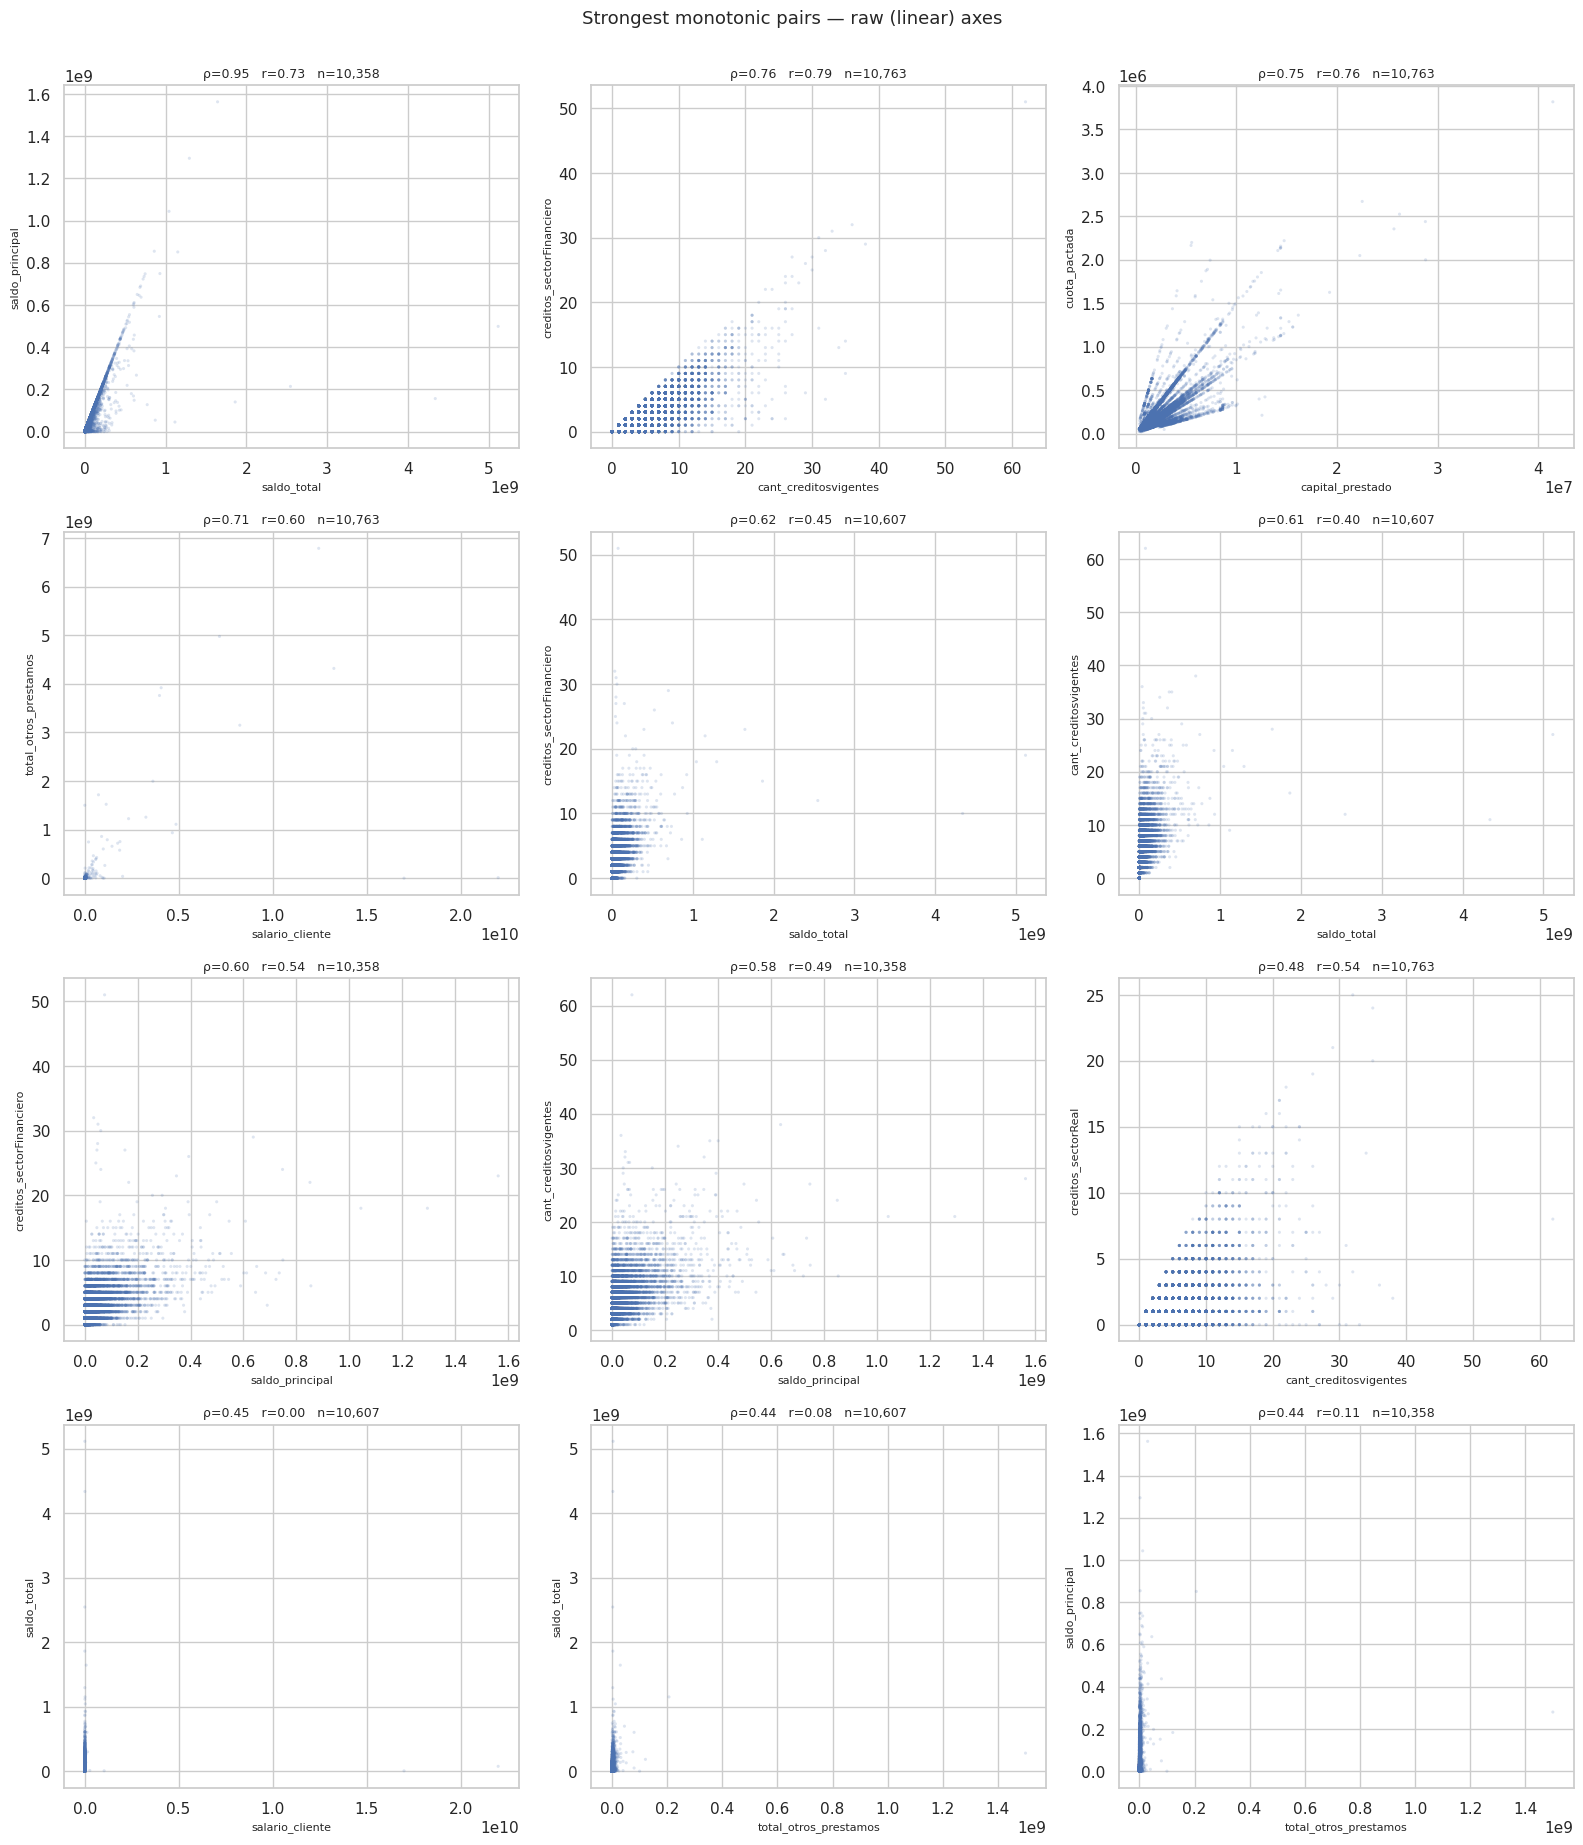

In [45]:
SCATTER_PAIRS = [p for p in top_monotonic.index if TARGET not in p][:12]
print("pairs plotted:", len(SCATTER_PAIRS))


def scatter_grid(pairs_to_plot, log_axes, filename, suptitle):
    n = len(pairs_to_plot)
    rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(16, 4.6 * rows))
    for ax, (x, y) in zip(np.atleast_1d(axes).ravel(), pairs_to_plot):
        d = num_frame[[x, y]].dropna()
        if log_axes:
            d = d[(d[x] > 0) & (d[y] > 0)]
        rho = stats.spearmanr(d[x], d[y]).statistic
        r = stats.pearsonr(d[x], d[y]).statistic
        ax.scatter(d[x], d[y], s=5, alpha=.18, color="#4c72b0", edgecolors="none")
        if log_axes:
            ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel(x, fontsize=8); ax.set_ylabel(y, fontsize=8)
        ax.set_title(f"ρ={rho:.2f}   r={r:.2f}   n={len(d):,}", fontsize=9)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    fig.suptitle(suptitle, y=1.002, fontsize=13)
    show_fig(fig, filename)
    plt.show()


scatter_grid(SCATTER_PAIRS, False, "14_scatter_linear",
             "Strongest monotonic pairs — raw (linear) axes")

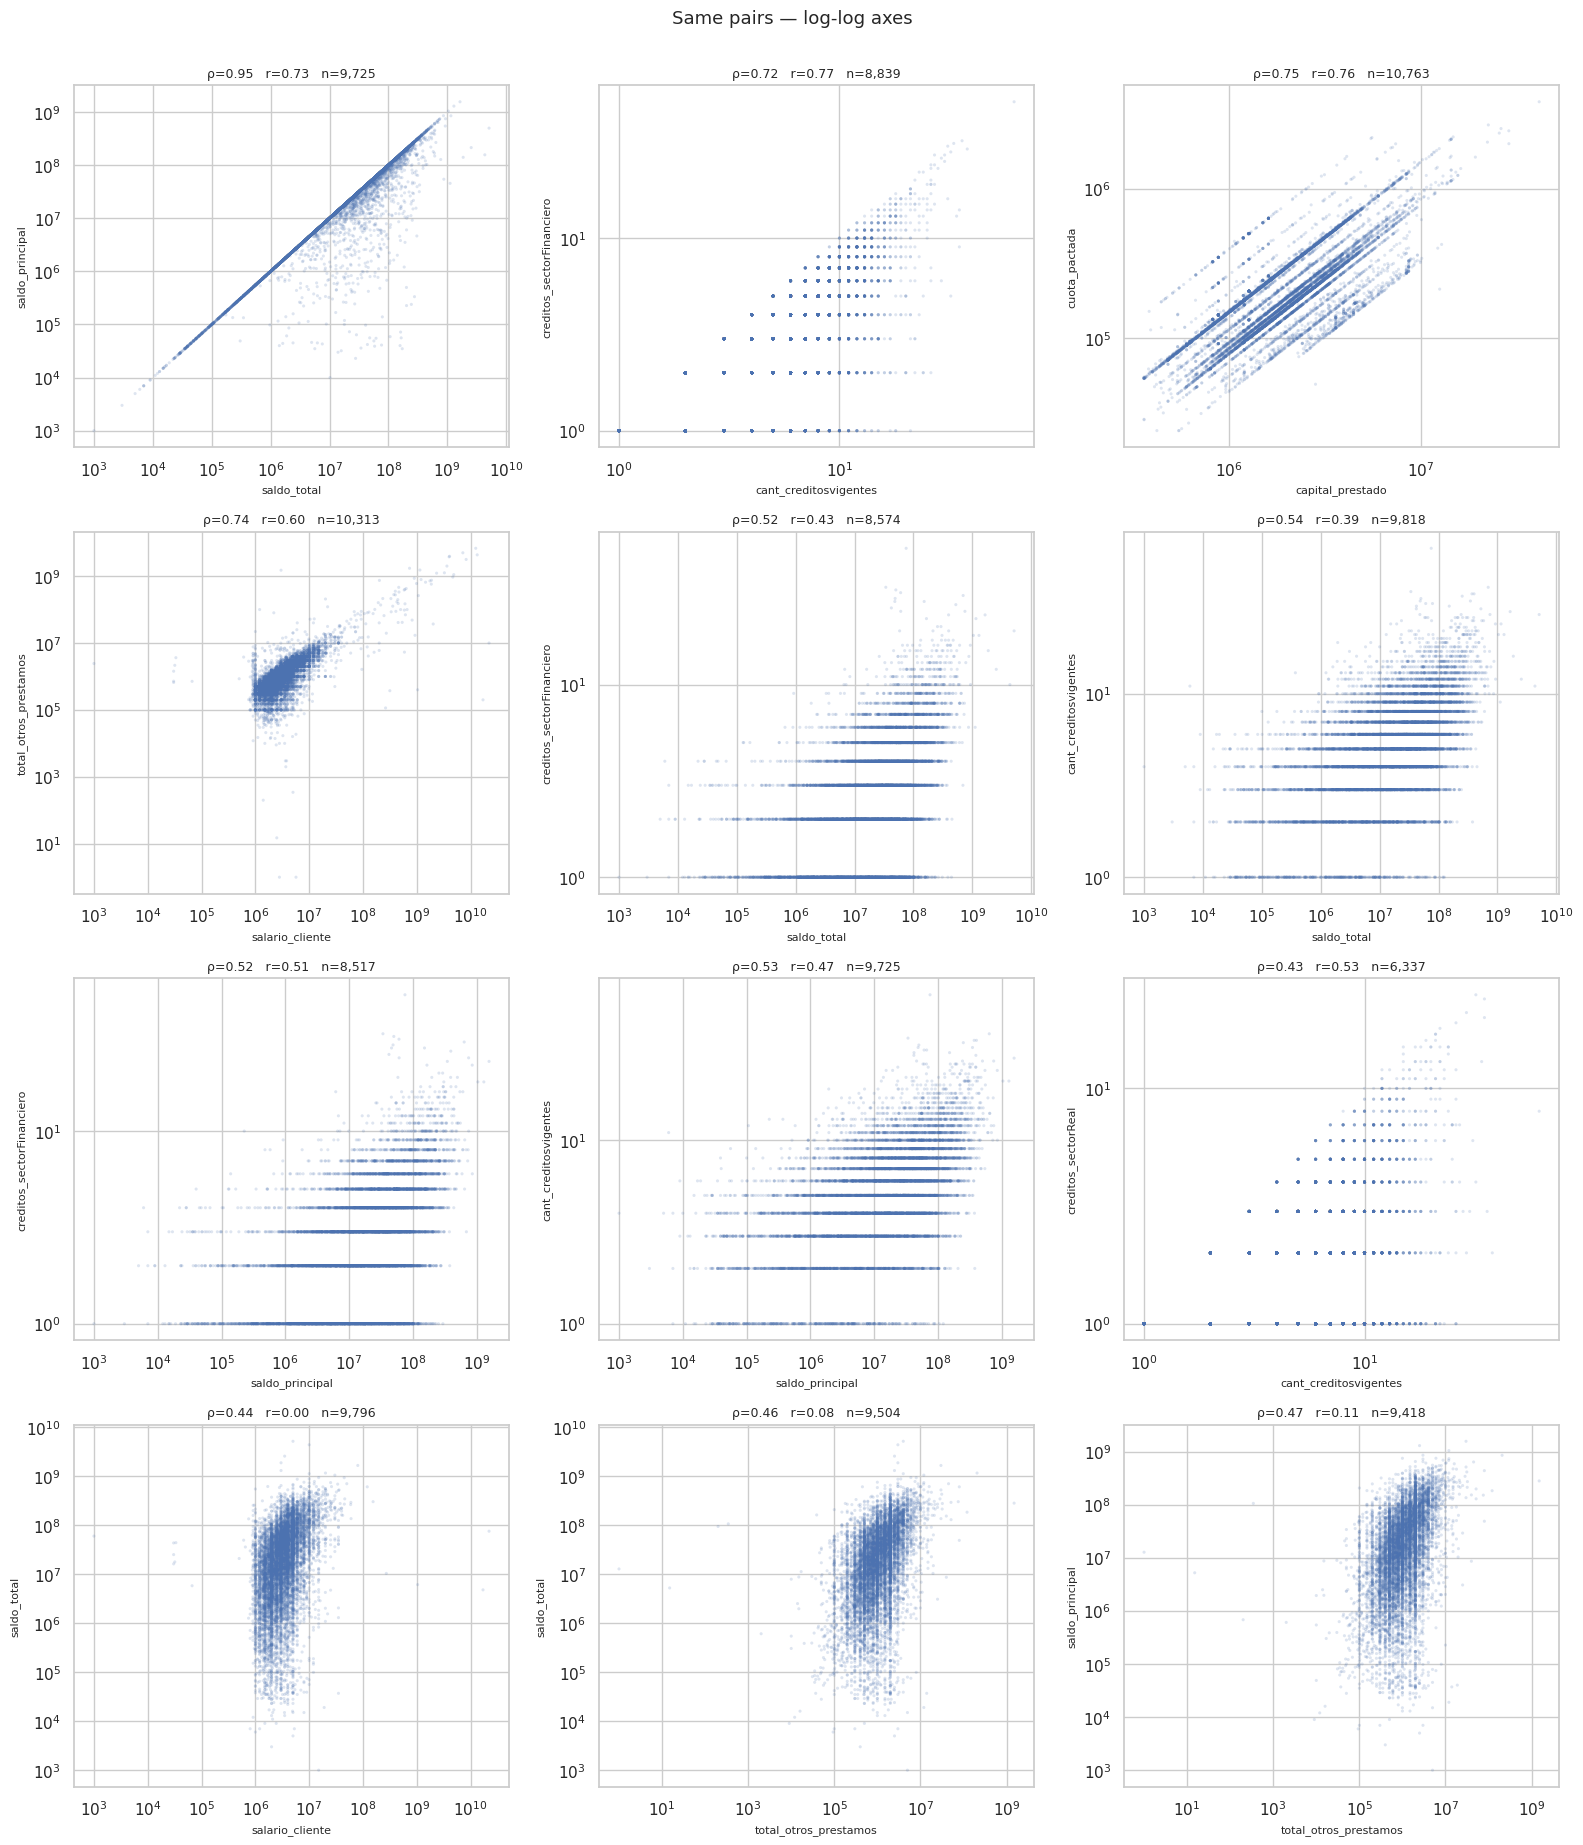

In [46]:
scatter_grid(SCATTER_PAIRS, True, "15_scatter_log",
             "Same pairs — log-log axes")

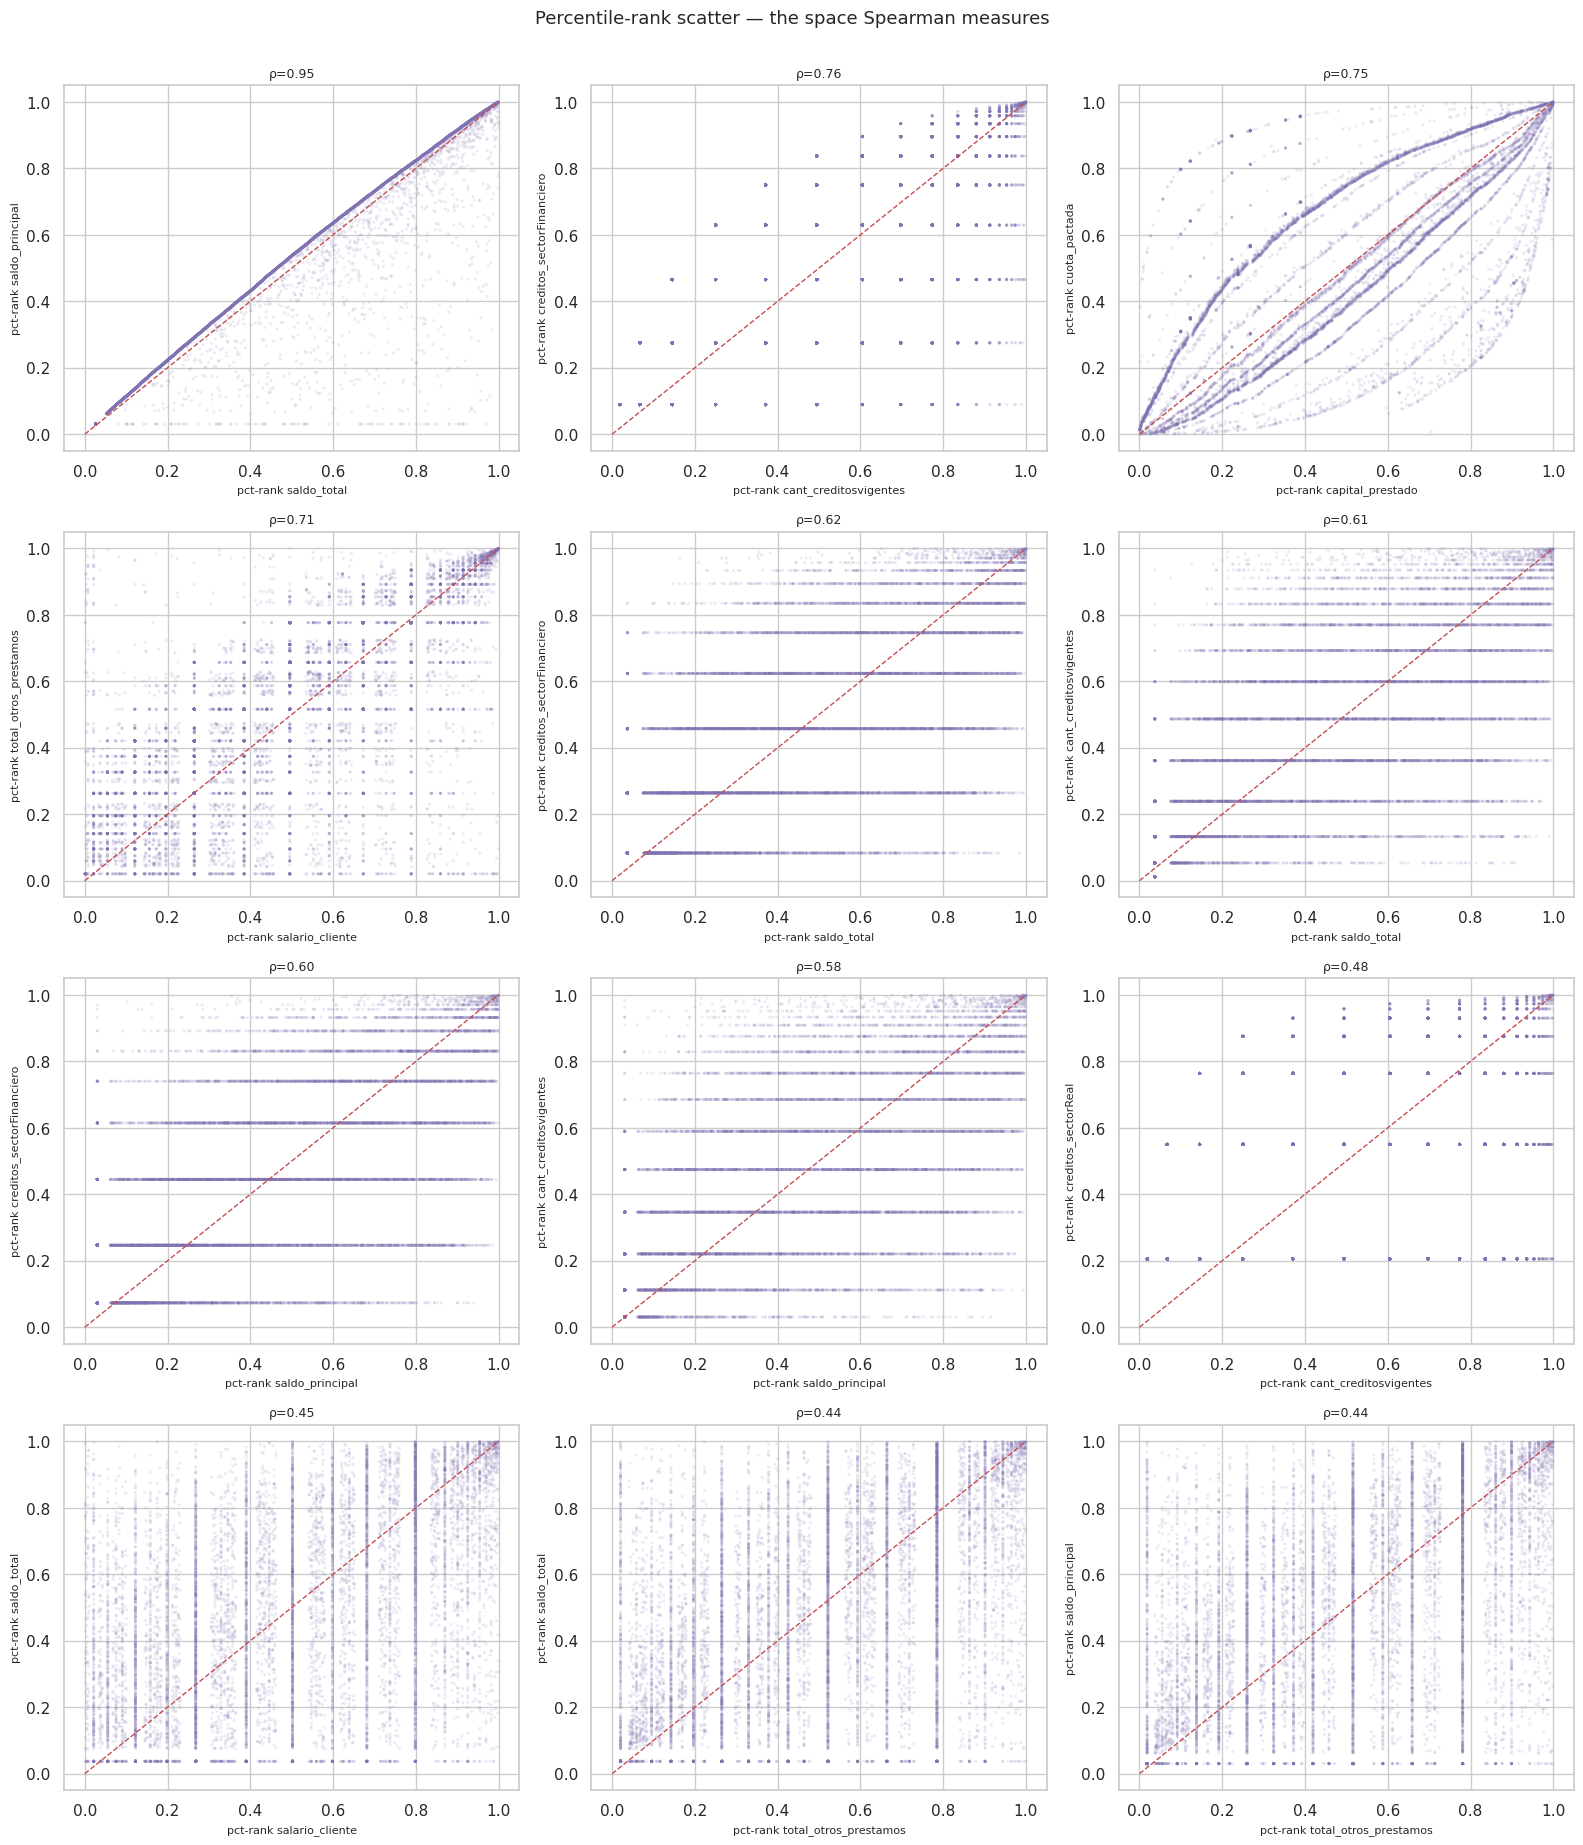

In [47]:
# Rank-transformed view: the space in which Spearman actually operates.
def rank_grid(pairs_to_plot, filename):
    n = len(pairs_to_plot)
    rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(rows, 3, figsize=(16, 4.6 * rows))
    for ax, (x, y) in zip(np.atleast_1d(axes).ravel(), pairs_to_plot):
        d = num_frame[[x, y]].dropna()
        rx, ry = d[x].rank(pct=True), d[y].rank(pct=True)
        ax.scatter(rx, ry, s=5, alpha=.15, color="#8172b3", edgecolors="none")
        ax.plot([0, 1], [0, 1], color="#c44e52", lw=1, ls="--")
        ax.set_xlabel(f"pct-rank {x}", fontsize=8)
        ax.set_ylabel(f"pct-rank {y}", fontsize=8)
        ax.set_title(f"ρ={stats.spearmanr(d[x], d[y]).statistic:.2f}", fontsize=9)
    for ax in np.atleast_1d(axes).ravel()[n:]:
        ax.axis("off")
    fig.suptitle("Percentile-rank scatter — the space Spearman measures", y=1.002, fontsize=13)
    show_fig(fig, filename)
    plt.show()


rank_grid(SCATTER_PAIRS, "16_scatter_ranks")

#### 3.3.3 Redundancy: variable clustering on the Spearman distance

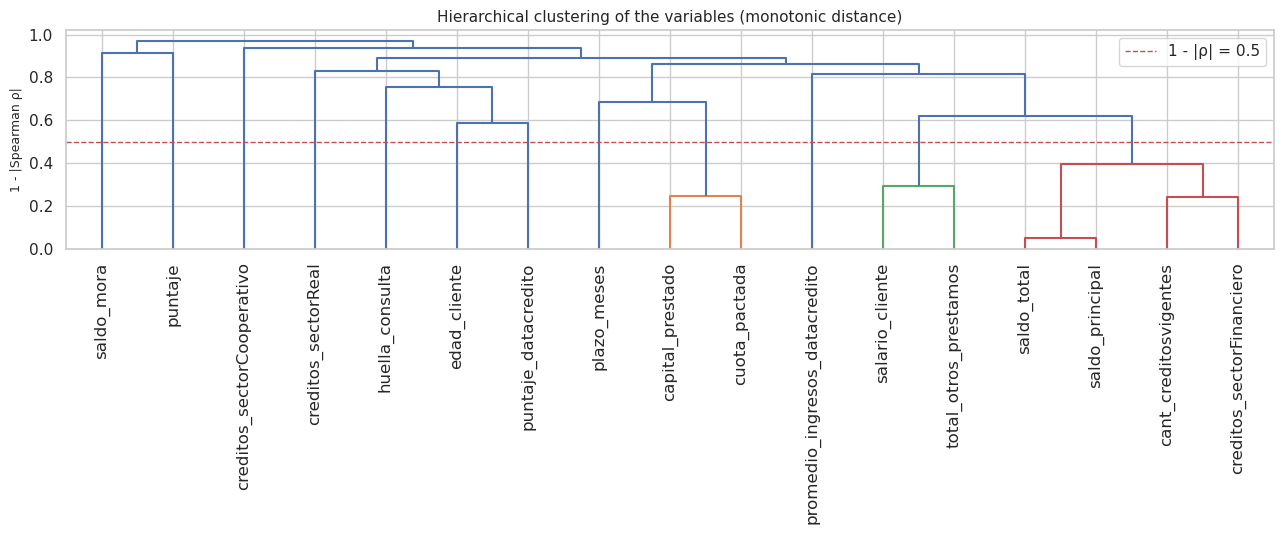

In [48]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

feat = [c for c in NUM_COLS]
rho = num_frame[feat].corr(method="spearman")
# linkage() needs a finite distance for every pair. A correlation that is undefined
# (no overlapping non-null rows) becomes distance 1.0 -- maximally far apart, the
# conservative choice, and it affects only this dendrogram scaffold, never the data.
distance = (1 - rho.abs()).fillna(1.0).to_numpy(copy=True)
distance = (distance + distance.T) / 2          # enforce exact symmetry
np.fill_diagonal(distance, 0)
Z = linkage(squareform(distance, checks=False), method="average")

fig, ax = plt.subplots(figsize=(13, 5.5))
dendrogram(Z, labels=feat, leaf_rotation=90, color_threshold=.5, ax=ax)
ax.axhline(.5, color="#c44e52", ls="--", lw=1, label="1 - |ρ| = 0.5")
ax.set_ylabel("1 - |Spearman ρ|")
ax.set_title("Hierarchical clustering of the variables (monotonic distance)")
ax.legend()
show_fig(fig, "17_dendrogram")
plt.show()

In [49]:
redundant = pairs[pairs["spearman"].abs() > .70].sort_values("spearman", key=abs, ascending=False)
redundant.drop(columns="abs_spearman")

,,pearson,spearman,gap
saldo_total,saldo_principal,0.7347,0.9463,0.2117
cant_creditosvigentes,creditos_sectorFinanciero,0.7913,0.7552,-0.0360
capital_prestado,cuota_pactada,0.7641,0.7507,-0.0134
salario_cliente,total_otros_prestamos,0.5970,0.7058,0.1089


#### 3.3.4 Pairplot and categorical hue

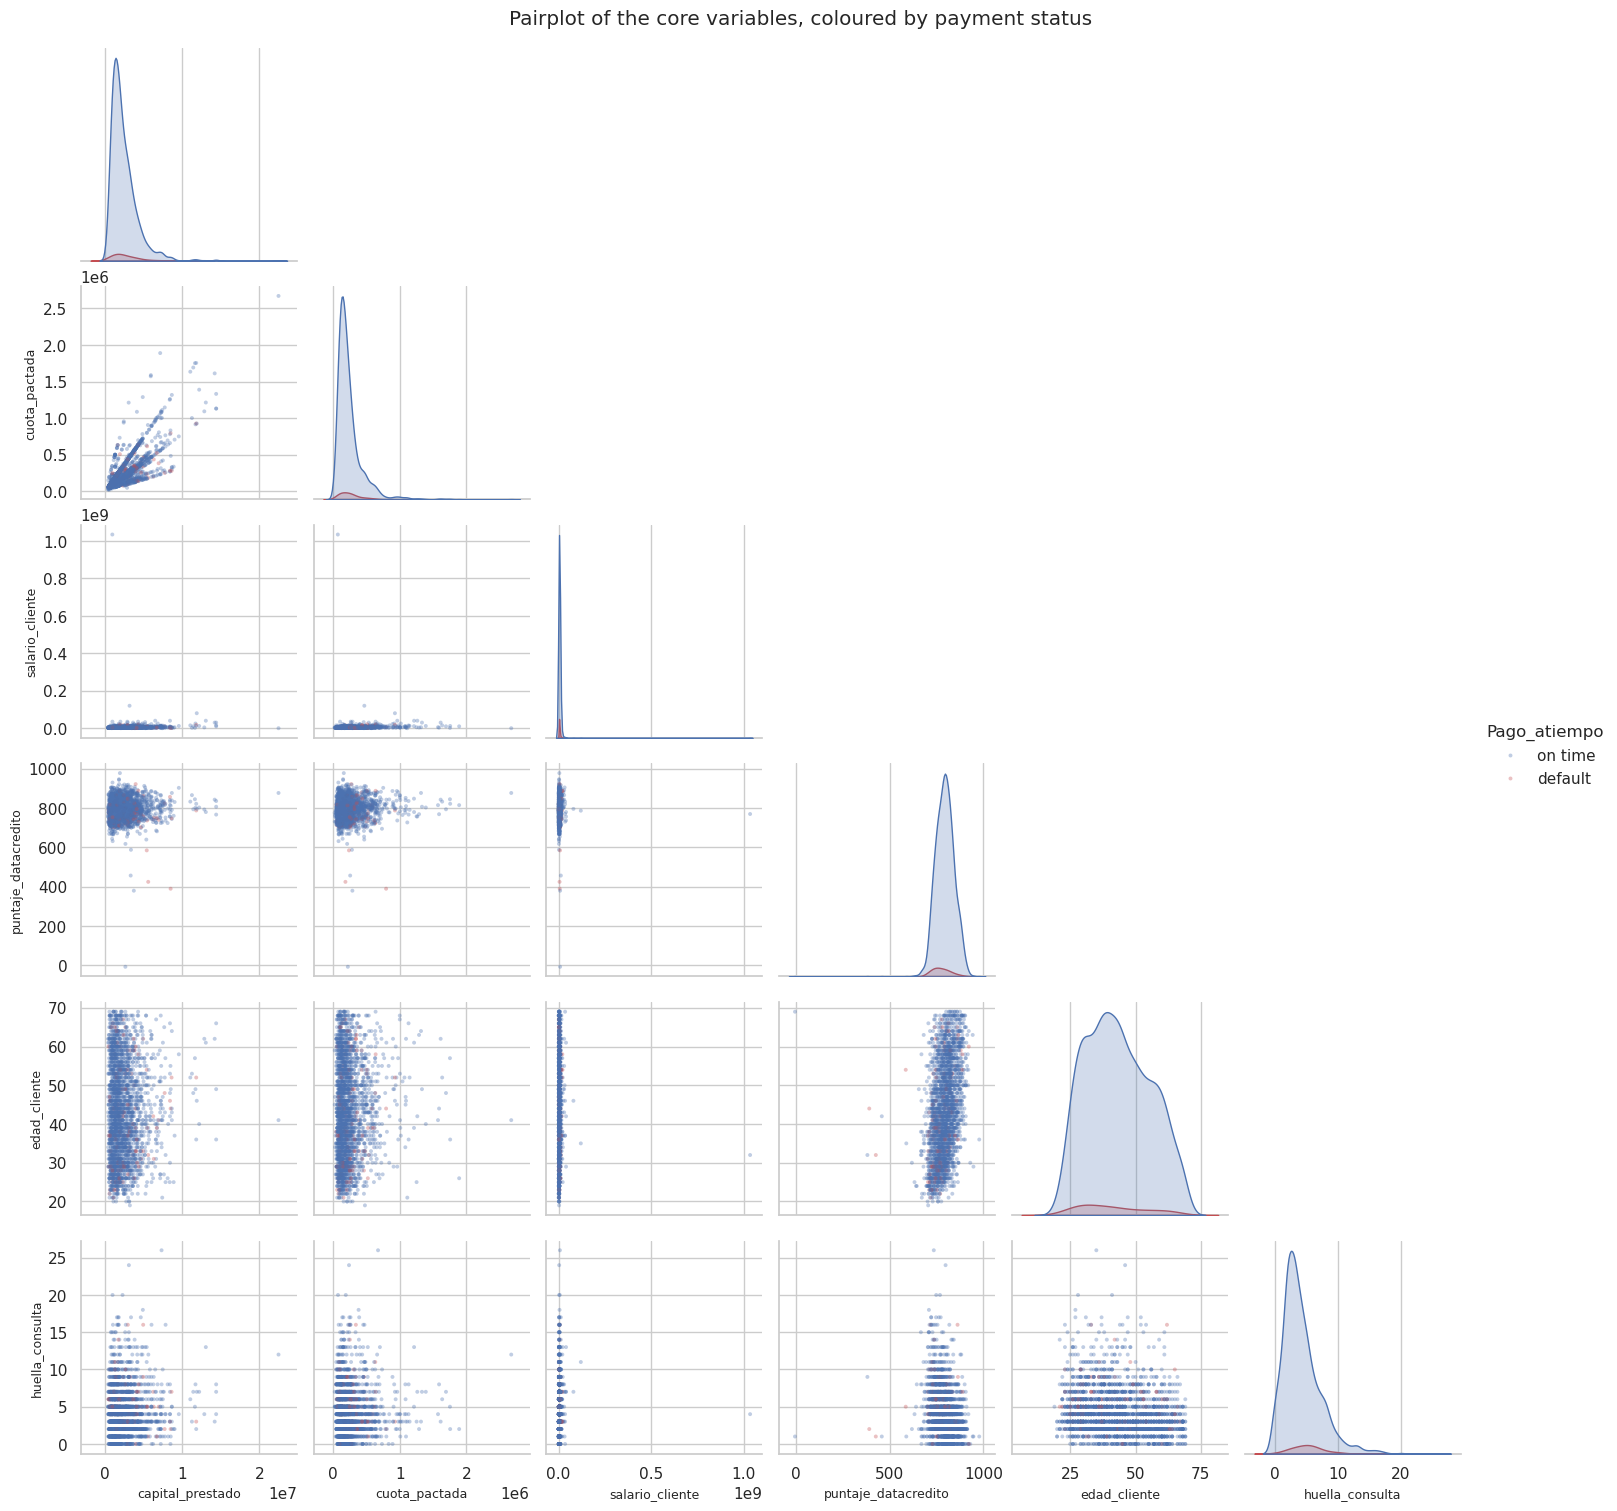

In [50]:
PAIRPLOT_COLS = ["capital_prestado", "cuota_pactada", "salario_cliente",
                 "puntaje_datacredito", "edad_cliente", "huella_consulta"]
sample = df[PAIRPLOT_COLS + [TARGET]].dropna().sample(2500, random_state=RANDOM_STATE).copy()
sample[TARGET] = sample[TARGET].map({0: "default", 1: "on time"})

g = sns.pairplot(sample, hue=TARGET, corner=True, diag_kind="kde",
                 plot_kws={"s": 8, "alpha": .35, "edgecolor": "none"},
                 palette={"default": "#c44e52", "on time": "#4c72b0"})
g.figure.suptitle("Pairplot of the core variables, coloured by payment status", y=1.01)
FIGURE_INDEX.append("18_pairplot")
plt.show()

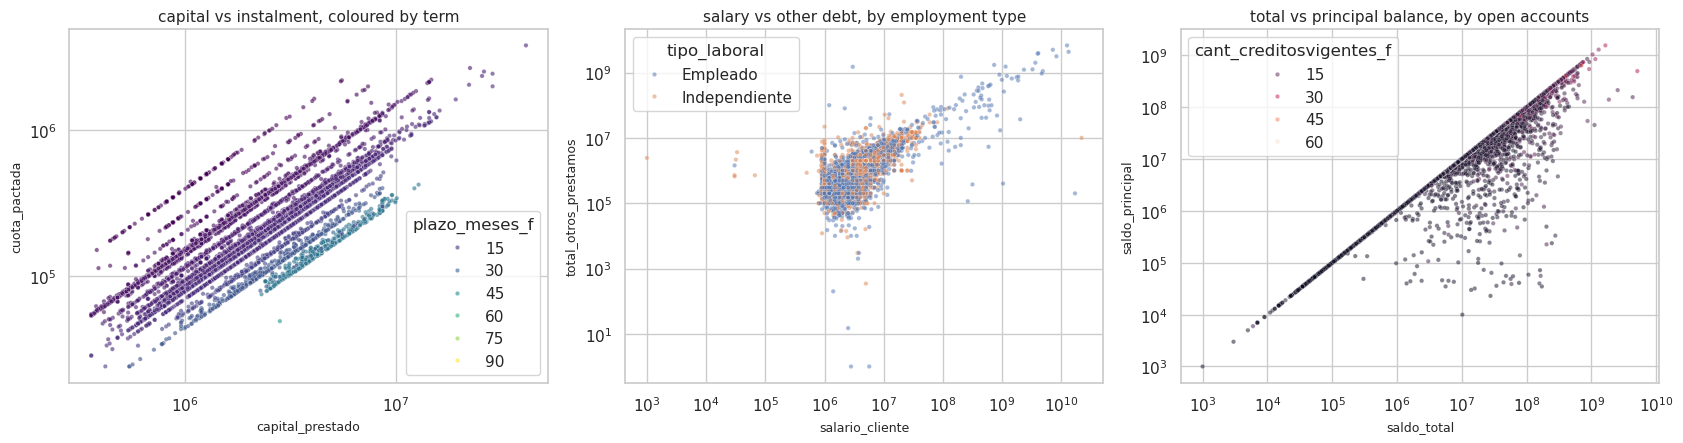

In [51]:
# Int64 (nullable) does not survive seaborn's legend locator -> cast the hue columns.
hue_df = df.assign(
    plazo_meses_f=df["plazo_meses"].astype(float),
    cant_creditosvigentes_f=df["cant_creditosvigentes"].astype(float),
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
sns.scatterplot(data=hue_df, x="capital_prestado", y="cuota_pactada", hue="plazo_meses_f",
                palette="viridis", s=10, alpha=.6, ax=axes[0], legend="brief")
axes[0].set(xscale="log", yscale="log", title="capital vs instalment, coloured by term")

sns.scatterplot(data=hue_df[hue_df["salario_cliente"] > 0], x="salario_cliente",
                y="total_otros_prestamos", hue="tipo_laboral", s=10, alpha=.5, ax=axes[1])
axes[1].set(xscale="log", yscale="log", title="salary vs other debt, by employment type")

sns.scatterplot(data=hue_df[hue_df["saldo_total"] > 0], x="saldo_total", y="saldo_principal",
                hue="cant_creditosvigentes_f", palette="rocket", s=10, alpha=.5, ax=axes[2])
axes[2].set(xscale="log", yscale="log", title="total vs principal balance, by open accounts")
show_fig(fig, "19_scatter_hue")
plt.show()

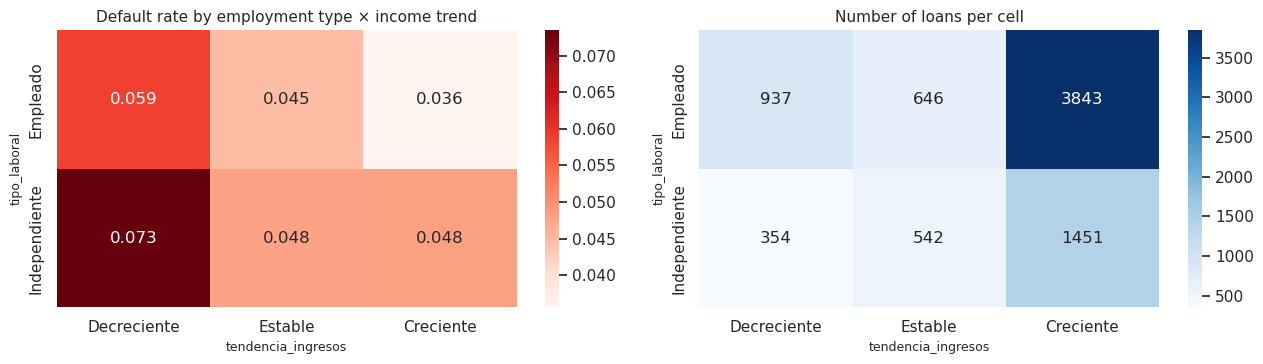

In [52]:
pivot_ratio = pd.pivot_table(
    df, index="tipo_laboral", columns="tendencia_ingresos", values=TARGET,
    aggfunc=lambda s: 1 - s.mean(), observed=True)
pivot_n = pd.pivot_table(df, index="tipo_laboral", columns="tendencia_ingresos",
                         values=TARGET, aggfunc="size", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(pivot_ratio, annot=True, fmt=".3f", cmap="Reds", ax=axes[0])
axes[0].set_title("Default rate by employment type × income trend")
sns.heatmap(pivot_n, annot=True, fmt=".0f", cmap="Blues", ax=axes[1])
axes[1].set_title("Number of loans per cell")
show_fig(fig, "20_pivot_default")
plt.show()

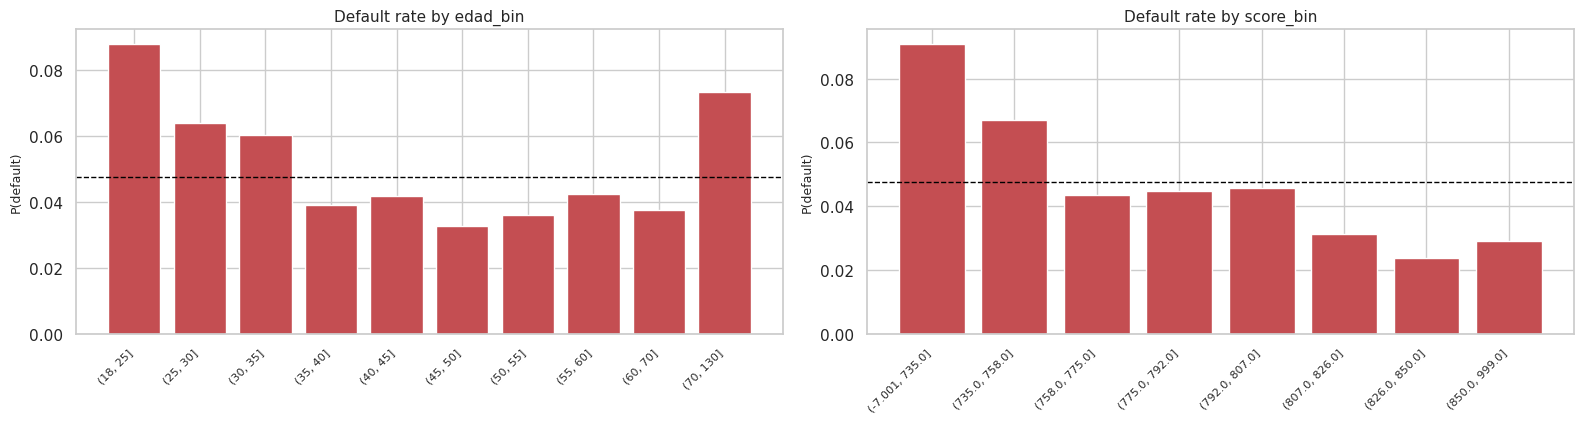

In [53]:
df["edad_bin"] = pd.cut(df["edad_cliente"].astype(float),
                        bins=[18, 25, 30, 35, 40, 45, 50, 55, 60, 70, 130])
df["score_bin"] = pd.qcut(df["puntaje_datacredito"], 8, duplicates="drop")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.4))
for ax, col in zip(axes, ["edad_bin", "score_bin"]):
    t = rate_by_group(df, col).sort_index()
    ax.bar(range(len(t)), t["default_rate"], color="#c44e52")
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([str(i) for i in t.index], rotation=45, ha="right", fontsize=8)
    ax.axhline(base_rate, ls="--", color="black", lw=1)
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("P(default)")
show_fig(fig, "21_default_by_bins")
plt.show()

## 4. Calculated variablesColumns derived arithmetically from the ones already in the file — ratios, shares,differences and date parts. They are *calculated*, not imputed: every one of them isnull wherever its inputs are null, and none of them fills a gap in the source data.The point of computing them here is diagnostic. A ratio can show a relationship the tworaw columns hide (`carga_financiera_total`), and a ratio can also expose a unit errorthe raw columns do not (section 2.4.1 found the thousands-of-pesos scale exactly thisway). Which of these survive into a model is a question for the modelling stage; thissection only ranks them by how strongly they move with the target.

In [54]:
calc = pd.DataFrame(index=df.index)
salary = df["salario_cliente"].replace(0, np.nan)
accounts = df["cant_creditosvigentes"].astype(float).replace(0, np.nan)

# --- affordability -------------------------------------------------------
# total_otros_prestamos is a self-declared MONTHLY instalment on other loans, not an
# outstanding balance: 76% of its values are round multiples of 100,000 COP and it runs
# at 0.33x monthly salary. It therefore adds to cuota_pactada directly, with no /12.
calc["ratio_cuota_salario"] = df["cuota_pactada"] / salary
calc["ratio_pagos_otros_salario"] = df["total_otros_prestamos"] / salary
calc["ratio_capital_salario"] = df["capital_prestado"] / salary
calc["carga_financiera_total"] = (df["cuota_pactada"] + df["total_otros_prestamos"]) / salary

# --- contract shape ------------------------------------------------------
calc["cuota_sobre_capital"] = df["cuota_pactada"] / df["capital_prestado"]
calc["cobertura_cuotas"] = df["cuota_pactada"] * df["plazo_meses"] / df["capital_prestado"]
calc["log_capital"] = np.log10(df["capital_prestado"])

# --- bureau behaviour ----------------------------------------------------
calc["intensidad_consulta"] = df["huella_consulta"] / (df["cant_creditosvigentes"].astype(float) + 1)
calc["creditos_por_anio_adulto"] = (df["cant_creditosvigentes"].astype(float)
                                  / (df["edad_cliente"].astype(float) - 18).clip(lower=1))
calc["share_sector_financiero"] = df["creditos_sectorFinanciero"] / accounts
calc["share_sector_real"] = df["creditos_sectorReal"] / accounts
calc["share_sector_cooperativo"] = df["creditos_sectorCooperativo"] / accounts
calc["sectores_distintos"] = (df[["creditos_sectorFinanciero", "creditos_sectorCooperativo",
                                "creditos_sectorReal"]].astype(float) > 0).sum(axis=1)
calc["creditos_no_reportados"] = (df["cant_creditosvigentes"].astype(float)
                                - df[["creditos_sectorFinanciero", "creditos_sectorCooperativo",
                                      "creditos_sectorReal"]].astype(float).sum(axis=1))

# --- balances ------------------------------------------------------------
# NaN saldo_mora is "no bureau balance on file", not "no arrears". Comparing against 0
# would read those 156 clients as the safest in the book; the unknown stays unknown.
calc["tiene_mora"] = (df["saldo_mora"] > 0).astype(float).where(df["saldo_mora"].notna())
calc["ratio_mora_saldo"] = df["saldo_mora"] / df["saldo_total"].replace(0, np.nan)
calc["interes_devengado"] = df["saldo_total"] - df["saldo_principal"]
calc["saldo_por_credito"] = df["saldo_total"] / accounts
calc["ratio_saldo_capital"] = df["saldo_total"] / df["capital_prestado"]

# --- income consistency --------------------------------------------------
calc["desfase_ingresos"] = df["promedio_ingresos_datacredito"] / salary
calc["ingreso_declarado_mayor"] = (salary > df["promedio_ingresos_datacredito"]).astype(float)
calc["sin_info_ingresos_bureau"] = df["promedio_ingresos_datacredito"].isna().astype(float)
calc["sin_score_bureau"] = df["puntaje_datacredito"].isna().astype(float)
calc["n_reglas_violadas"] = df["n_reglas_violadas"]

# --- temporal ------------------------------------------------------------
calc["mes_desembolso"] = df["fecha_prestamo"].dt.month
calc["dia_semana_desembolso"] = df["fecha_prestamo"].dt.dayofweek
calc["hora_desembolso"] = df["fecha_prestamo"].dt.hour
calc["antiguedad_dias"] = (df["fecha_prestamo"].max() - df["fecha_prestamo"]).dt.days

calc = calc.replace([np.inf, -np.inf], np.nan)
describe_extended(calc)

,count,mean,std,min,25%,50%,75%,max,range,IQR,variance,CV,skew,kurtosis,n_missing,pct_missing,n_unique,n_zeros
ratio_cuota_salario,"10,739.0000",0.0947,1.2434,0.0000,0.0387,0.0609,0.0954,125.8020,125.8020,0.0567,1.5462,13.1339,96.8022,"9,737.6226",24,0.0022,10447,0
ratio_pagos_otros_salario,"10,739.0000",0.6852,24.0779,0.0000,0.2086,0.3333,0.4750,"2,439.0000","2,439.0000",0.2664,579.7466,35.1407,97.5780,"9,813.7471",24,0.0022,2726,426
ratio_capital_salario,"10,739.0000",0.9218,8.3417,0.0001,0.3702,0.6331,1.0207,840.0000,839.9999,0.6505,69.5833,9.0497,95.3979,"9,543.8766",24,0.0022,9208,0
carga_financiera_total,"10,739.0000",0.7799,25.2769,0.0000,0.2877,0.4208,0.5439,"2,564.8020","2,564.8020",0.2562,638.9225,32.4121,97.9544,"9,876.5454",24,0.0022,10535,0
cuota_sobre_capital,"10,763.0000",0.1095,0.0549,0.0169,0.0785,0.0925,0.1485,0.4167,0.3997,0.0701,0.0030,0.5014,2.4019,9.9203,0,0.0000,9450,0
cobertura_cuotas,"10,763.0000",0.9116,0.0889,0.7880,0.8504,0.8942,0.9415,1.5241,0.7361,0.0912,0.0079,0.0976,2.3051,7.4123,0,0.0000,9443,0
log_capital,"10,763.0000",6.2886,0.2881,5.5563,6.0881,6.2837,6.4892,7.6175,2.0612,0.4012,0.0830,0.0458,0.1120,-0.1103,0,0.0000,7306,0
intensidad_consulta,"10,763.0000",0.7742,0.7233,0.0000,0.3333,0.6000,1.0000,15.0000,15.0000,0.6667,0.5231,0.9342,3.6071,31.5575,0,0.0000,255,700
creditos_por_anio_adulto,"10,763.0000",0.2997,0.2936,0.0000,0.1220,0.2273,0.3846,7.0000,7.0000,0.2627,0.0862,0.9797,4.1630,43.9372,0,0.0000,548,405
share_sector_financiero,"10,358.0000",0.4637,0.2889,0.0000,0.2500,0.5000,0.6667,1.0000,1.0000,0.4167,0.0835,0.6230,-0.0065,-0.7686,405,0.0376,158,1519


In [55]:
LEAKAGE = CFG["leakage_columns"]
candidates = pd.concat([df[[c for c in NUM_COLS if c not in LEAKAGE]].astype(float), calc], axis=1)

rows = []
for name, s in candidates.items():
    m = s.notna()
    if m.sum() < 200 or s[m].nunique() < 2:
        continue
    rho, p_rho = stats.spearmanr(s[m], df.loc[m, TARGET])
    on_time = s[m][df.loc[m, TARGET] == 1]
    default = s[m][df.loc[m, TARGET] == 0]
    p_mwu = stats.mannwhitneyu(on_time, default).pvalue if min(len(on_time), len(default)) > 5 else np.nan
    rows.append({"feature": name, "spearman_vs_target": rho, "p_spearman": p_rho,
                 "mannwhitney_p": p_mwu, "n": int(m.sum()),
                 "origin": "calculated" if name in calc.columns else "original"})

ranking = (pd.DataFrame(rows)
           .assign(abs_rho=lambda t: t["spearman_vs_target"].abs())
           .sort_values("abs_rho", ascending=False)
           .drop(columns="abs_rho")
           .set_index("feature"))
ranking["significant_5pct"] = ranking["p_spearman"] < .05
ranking

,spearman_vs_target,p_spearman,mannwhitney_p,n,origin,significant_5pct
feature,,,,,,
ratio_mora_saldo,-0.1135,0.0000,0.0000,9818,calculated,True
saldo_mora,-0.1080,0.0000,0.0000,10607,original,True
tiene_mora,-0.1078,0.0000,0.0000,10607,calculated,True
puntaje_datacredito,0.0909,0.0000,0.0000,10612,original,True
intensidad_consulta,-0.0765,0.0000,0.0000,10763,calculated,True
huella_consulta,-0.0729,0.0000,0.0000,10763,original,True
desfase_ingresos,0.0521,0.0000,0.0000,7817,calculated,True
promedio_ingresos_datacredito,0.0515,0.0000,0.0000,7833,original,True
edad_cliente,0.0509,0.0000,0.0000,10763,original,True


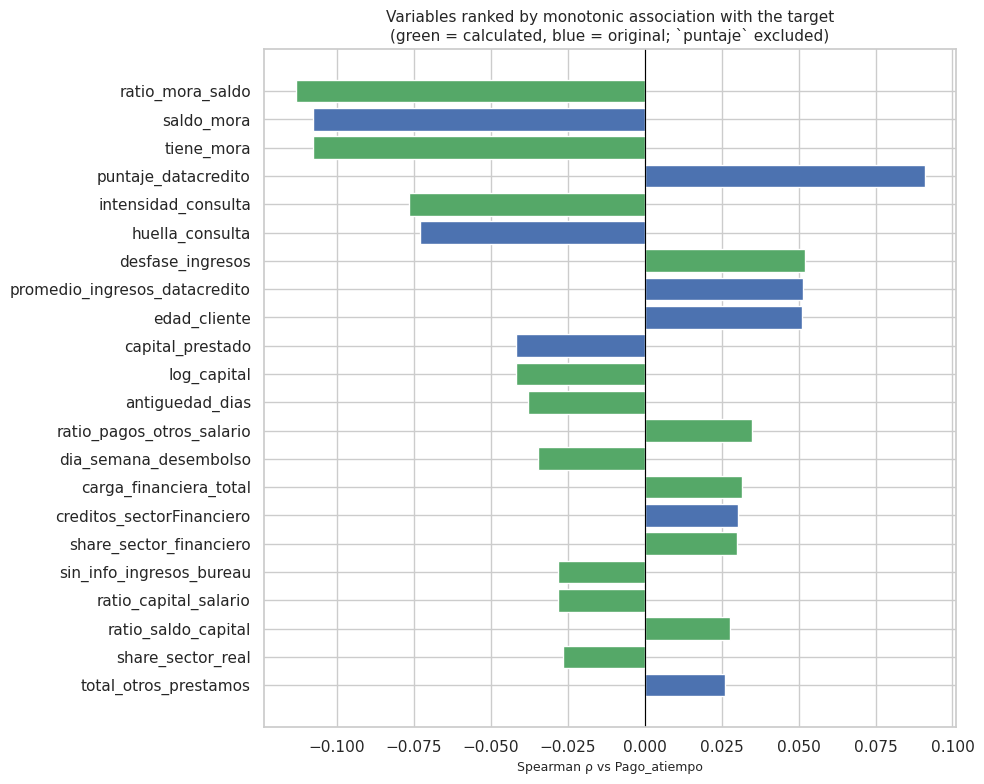

In [56]:
fig, ax = plt.subplots(figsize=(10, 8))
top = ranking.head(22).iloc[::-1]
colors = np.where(top["origin"] == "calculated", "#55a868", "#4c72b0")
ax.barh(top.index, top["spearman_vs_target"], color=colors)
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("Spearman ρ vs Pago_atiempo")
ax.set_title("Variables ranked by monotonic association with the target\n"
             "(green = calculated, blue = original; `puntaje` excluded)")
show_fig(fig, "22_variable_ranking")
plt.show()

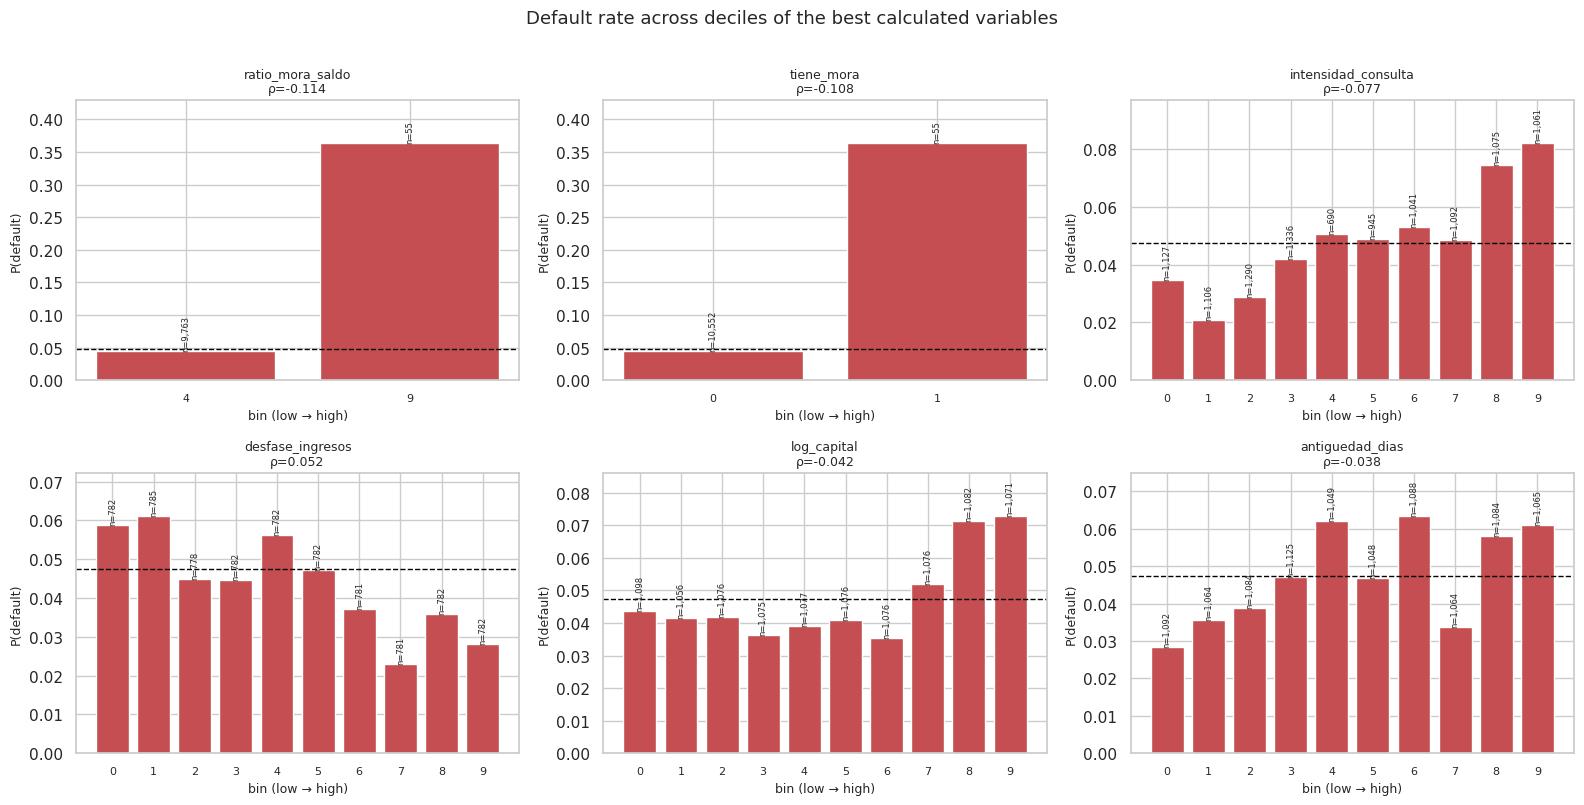

In [57]:
def decile_curve(series, n_bins=10):
    """Quantile bins when the variable is continuous enough, raw values otherwise.

    Sparse variables (mostly zeros) collapse into a single qcut bin, which would
    render as one flat bar; grouping by value keeps them readable.
    """
    s = series.replace([np.inf, -np.inf], np.nan)
    binned = pd.qcut(s, n_bins, duplicates="drop", labels=False)
    if binned.nunique() < 3:
        binned = s if s.nunique() <= 12 else s.rank(pct=True).mul(n_bins).clip(upper=n_bins - 1) // 1
    g = df[TARGET].groupby(binned)
    out = pd.DataFrame({"n": g.size(), "default_rate": 1 - g.mean()})
    return out[out["n"] >= 20]


BEST = ranking[ranking["origin"] == "calculated"].head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, name in zip(axes.ravel(), BEST):
    t = decile_curve(calc[name])
    ax.bar(range(len(t)), t["default_rate"], color="#c44e52")
    ax.set_xticks(range(len(t)))
    ax.set_xticklabels([f"{i:g}" if isinstance(i, float) else str(i) for i in t.index],
                       fontsize=8)
    for x, (n, rate) in enumerate(zip(t["n"], t["default_rate"])):
        ax.text(x, rate, f"n={n:,}", ha="center", va="bottom", fontsize=6, rotation=90)
    ax.axhline(base_rate, ls="--", color="black", lw=1)
    ax.margins(y=.18)
    ax.set_title(f"{name}\nρ={ranking.loc[name, 'spearman_vs_target']:.3f}", fontsize=9)
    ax.set_xlabel("bin (low → high)"); ax.set_ylabel("P(default)")
for ax in axes.ravel()[len(BEST):]:
    ax.axis("off")
fig.suptitle("Default rate across deciles of the best calculated variables", y=1.005, fontsize=13)
show_fig(fig, "23_decile_curves")
plt.show()

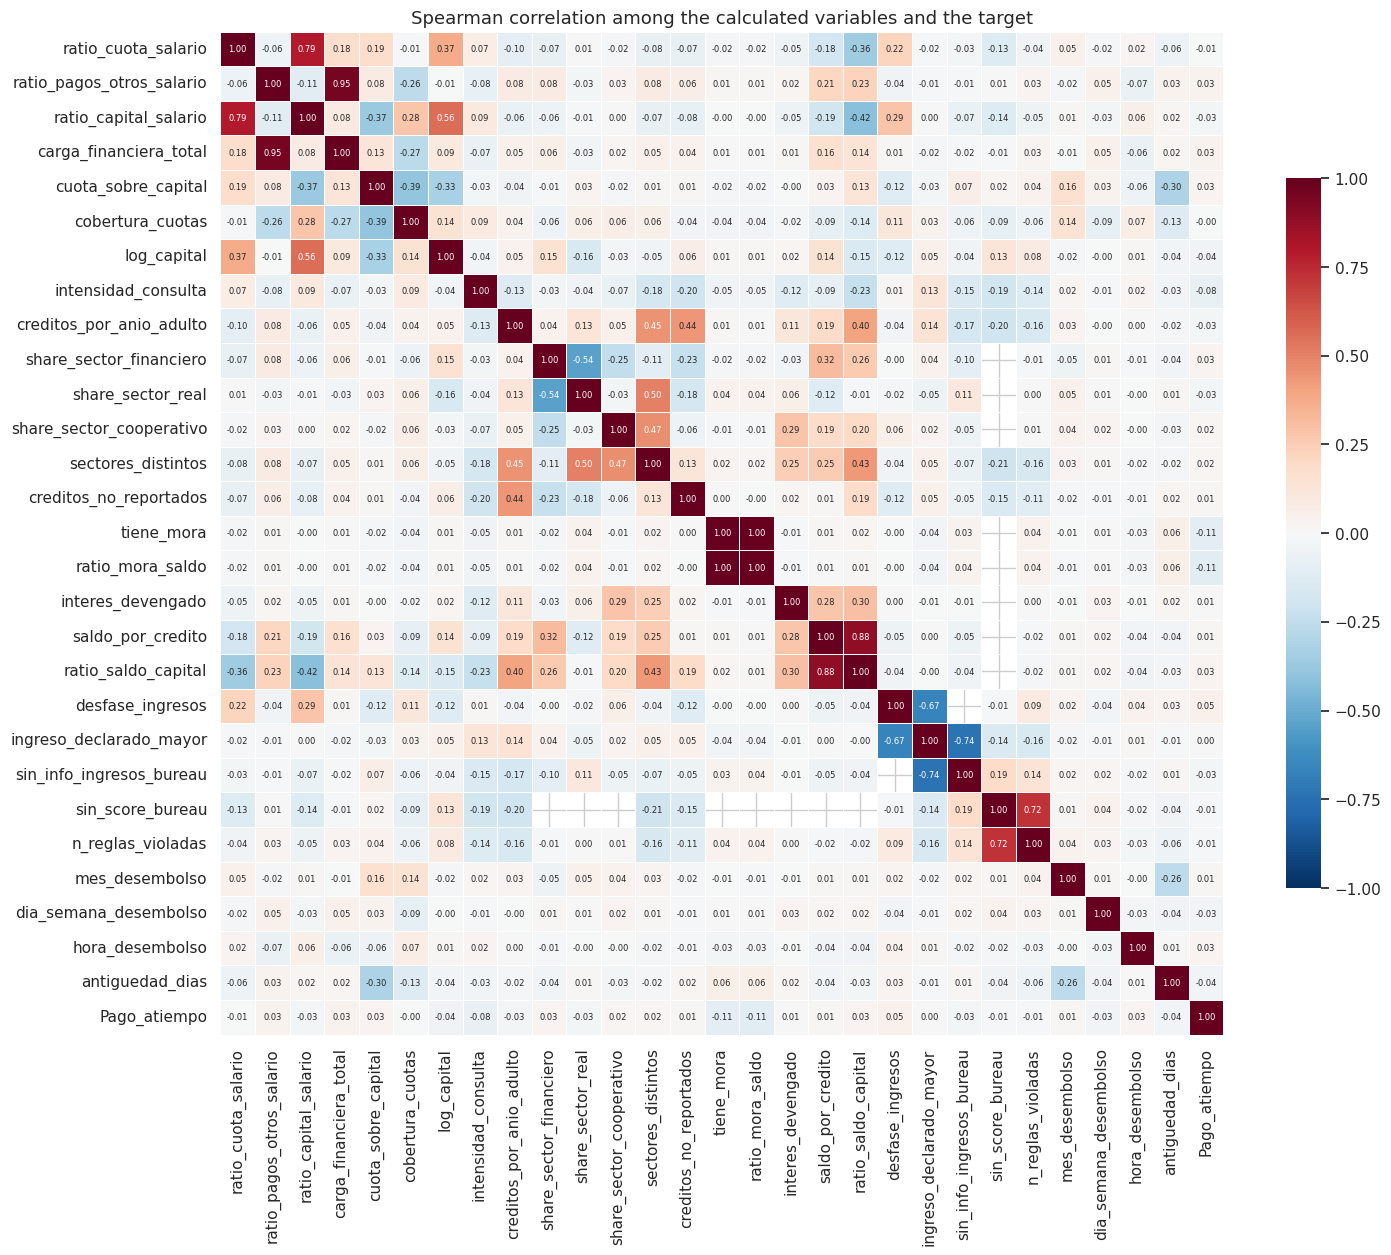

In [58]:
calc_num = pd.concat([calc, df[[TARGET]]], axis=1).astype(float)
calc_spearman = calc_num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(15, 12.5))
sns.heatmap(calc_spearman, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=.4, annot_kws={"size": 6}, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Spearman correlation among the calculated variables and the target", fontsize=13)
show_fig(fig, "24_corr_calculated")
plt.show()

In [59]:
calc_pairs = upper_pairs(calc_spearman, "spearman").to_frame()
calc_pairs["abs"] = calc_pairs["spearman"].abs()
calc_pairs.sort_values("abs", ascending=False).head(20).drop(columns="abs")

,,spearman
tiene_mora,ratio_mora_saldo,1.0000
ratio_pagos_otros_salario,carga_financiera_total,0.9544
saldo_por_credito,ratio_saldo_capital,0.8831
ratio_cuota_salario,ratio_capital_salario,0.7940
ingreso_declarado_mayor,sin_info_ingresos_bureau,-0.7407
sin_score_bureau,n_reglas_violadas,0.7229
desfase_ingresos,ingreso_declarado_mayor,-0.6673
ratio_capital_salario,log_capital,0.5591
share_sector_financiero,share_sector_real,-0.5416
share_sector_real,sectores_distintos,0.5018


## 5. Consolidated outputs

### 5.1 Modelling dataset

In [60]:
# n_reglas_violadas_todas is kept out: it counts the `puntaje` range rule and
# therefore carries the same leakage as `puntaje` itself.
HELPER_COLS = ["edad_bin", "score_bin", "delta_ingresos_datacredito",
               "n_reglas_violadas_todas"]
# n_reglas_violadas survives as calc_n_reglas_violadas; keeping both would put two
# perfectly collinear columns in the frame.
DUPLICATED_IN_CALC = ["n_reglas_violadas"]

model_df = pd.concat([
    df.drop(columns=HELPER_COLS + LEAKAGE + DUPLICATED_IN_CALC),
    calc.add_prefix("calc_"),
], axis=1)

# Asserted rather than trusted: this frame is the one thing in the notebook someone
# else might pick up and train on, and section 3.2.1 shows what `puntaje` does to a
# model. A print claiming the column was excluded is not a guarantee that it was.
assert not set(LEAKAGE) & set(model_df.columns),     f"leakage column reached the modelling frame: {set(LEAKAGE) & set(model_df.columns)}"

print("modelling frame:", model_df.shape)
print("target:", TARGET, "| positive class rate:", model_df[TARGET].mean())
print("dropped helper columns:", HELPER_COLS)
print("dropped as duplicated in calc:", DUPLICATED_IN_CALC)
print("excluded from modelling (leakage):", LEAKAGE, "-- verified absent")
model_df.head()

modelling frame: (10763, 49)
target: Pago_atiempo | positive class rate: 0.9525225308928738
dropped helper columns: ['edad_bin', 'score_bin', 'delta_ingresos_datacredito', 'n_reglas_violadas_todas']
dropped as duplicated in calc: ['n_reglas_violadas']
excluded from modelling (leakage): ['puntaje'] -- verified absent


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo,calc_ratio_cuota_salario,calc_ratio_pagos_otros_salario,calc_ratio_capital_salario,calc_carga_financiera_total,calc_cuota_sobre_capital,calc_cobertura_cuotas,calc_log_capital,calc_intensidad_consulta,calc_creditos_por_anio_adulto,calc_share_sector_financiero,calc_share_sector_real,calc_share_sector_cooperativo,calc_sectores_distintos,calc_creditos_no_reportados,calc_tiene_mora,calc_ratio_mora_saldo,calc_interes_devengado,calc_saldo_por_credito,calc_ratio_saldo_capital,calc_desfase_ingresos,calc_ingreso_declarado_mayor,calc_sin_info_ingresos_bureau,calc_sin_score_bureau,calc_n_reglas_violadas,calc_mes_desembolso,calc_dia_semana_desembolso,calc_hora_desembolso,calc_antiguedad_dias
0,4,2025-01-07 14:40:00,1852560,12,32,Empleado,3500000,1000000,128650,795.0000,0,2,0.0000,0.0000,NaN,0,0,0,"916,148.0000",Creciente,1,0.0368,0.2857,0.5293,0.3225,0.0694,0.8333,6.2678,2.0000,0.0000,<NA>,<NA>,<NA>,0,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.2618,1.0000,0.0000,0.0000,0,1,1,14,474
1,4,2025-01-09 11:18:00,3181080,6,34,Empleado,5000000,2000000,441817,796.0000,0,7,0.0000,0.0000,NaN,0,0,0,"4,473,774.0000",Creciente,1,0.0884,0.4000,0.6362,0.4884,0.1389,0.8333,6.5026,7.0000,0.0000,<NA>,<NA>,<NA>,0,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.8948,1.0000,0.0000,0.0000,0,1,3,11,472
2,9,2024-12-26 18:52:00,670200,5,34,Independiente,5000000,2000000,108632,727.0000,5,0,0.0000,"274,561,000.0000","274,561,000.0000",2,0,1,NaN,NaN,1,0.0217,0.4000,0.1340,0.4217,0.1621,0.8104,5.8262,0.0000,0.3125,0.4000,0.2000,0.0000,2,2.0000,0.0000,0.0000,0.0000,"54,912,200.0000",409.6702,NaN,0.0000,1.0000,0.0000,0,12,3,18,485
3,9,2024-12-04 14:20:00,506807,2,25,Independiente,3000000,900000,199684,864.0000,8,1,0.0000,"27,564,000.0000","27,564,000.0000",1,0,6,NaN,NaN,1,0.0666,0.3000,0.1689,0.3666,0.3940,0.7880,5.7048,0.1111,1.1429,0.1250,0.7500,0.0000,2,1.0000,0.0000,0.0000,0.0000,"3,445,500.0000",54.3876,NaN,0.0000,1.0000,0.0000,0,12,2,14,508
4,4,2025-04-30 18:41:00,999780,10,26,Empleado,2000000,600000,92509,771.0000,0,3,0.0000,0.0000,NaN,0,0,0,"61,000.0000",Creciente,1,0.0463,0.3000,0.4999,0.3463,0.0925,0.9253,5.9999,3.0000,0.0000,<NA>,<NA>,<NA>,0,0.0000,0.0000,NaN,NaN,NaN,0.0000,0.0305,1.0000,0.0000,0.0000,0,4,2,18,361


### 5.2 Data-quality and validation-rule summary

In [61]:
summary = pd.concat([
    validation[["rule_min", "rule_max", "observed_min", "observed_max",
                "n_below", "n_above", "pct_out_of_range"]],
], axis=1)
summary

,rule_min,rule_max,observed_min,observed_max,n_below,n_above,pct_out_of_range
variable,,,,,,,
edad_cliente,18,90,19.0000,123.0000,0,150,0.0139
puntaje_datacredito,150,950,-7.0000,999.0000,2,6,0.0007
puntaje,0,100,-38.0100,95.2278,135,0,0.0125
salario_cliente,1000000,100000000,0.0000,"22,000,000,000.0000",112,74,0.0173
capital_prestado,100000,50000000,"360,000.0000","41,444,153.0000",0,0,0.0000
plazo_meses,1,60,2.0000,90.0000,0,1,0.0001
cuota_pactada,10000,5000000,"23,944.0000","3,816,752.0000",0,0,0.0000
total_otros_prestamos,0,500000000,0.0000,"6,787,675,263.0000",0,22,0.0020
cant_creditosvigentes,0,40,0.0000,62.0000,0,1,0.0001


In [62]:
# Completeness is a statement about the SOURCE data, so the analysis by-products
# have to come out first -- delta_ingresos_datacredito alone is null in 10,705 of
# 10,763 rows and would drag "rows fully complete" from 71% down to 56 rows.
source_cols = df.drop(columns=[c for c in HELPER_COLS if c in df.columns])

quality = pd.DataFrame([
    {"check": "rows", "value": len(df)},
    {"check": "columns after cleaning", "value": df.shape[1]},
    {"check": "source columns (excl. analysis by-products)", "value": source_cols.shape[1]},
    {"check": "full-row duplicates", "value": int(raw.duplicated().sum())},
    {"check": "source columns with missing values", "value": int(source_cols.isna().any().sum())},
    {"check": "rows fully complete (source columns)",
     "value": int(source_cols.notna().all(axis=1).sum())},
    {"check": "rows violating >= 1 range rule", "value": int((df["n_reglas_violadas"] > 0).sum())},
    {"check": "target positive rate", "value": float(df[TARGET].mean())},
    {"check": "columns dropped", "value": ", ".join(DROP)},
    {"check": "columns flagged as leakage", "value": ", ".join(LEAKAGE)},
    {"check": "date range", "value": f"{df['fecha_prestamo'].min():%Y-%m-%d} → {df['fecha_prestamo'].max():%Y-%m-%d}"},
]).set_index("check")
quality

,value
check,
rows,10763
columns after cleaning,27
source columns (excl. analysis by-products),23
full-row duplicates,0
source columns with missing values,6
rows fully complete (source columns),7617
rows violating >= 1 range rule,277
target positive rate,0.9525
columns dropped,saldo_mora_codeudor


## 6. The seven findingsSections 1–5 are the working trail: everything that was loaded, typed, validated andcalculated, in the order it happened. This section is the distilled read — the sevenfindings that survived, in the order they are worth telling, each one a single-gridfigure with its own title and axes.It is the same set, in the same order, as `report/REPORT.md` and the written report.Every number quoted in the prose below is **printed by the cell underneath it**, so thenotebook and the report cannot drift apart without it being visible here.| # | Finding | The one line ||---|---|---|| 1 | `puntaje` is target leakage | The most predictive column in the file cannot be used, and here is the proof || 2 | What a legitimate score looks like | The contrast with finding 1 *is* the argument || 3 | Pearson misses what Spearman finds | Reporting Pearson alone would have discarded every salary-derived variable || 4 | Two columns that do not mean what their names say | Both silently corrupt every ratio built on them || 5 | Arrears already on file | The one rule that works today and needs no model || 6 | Inquiry intensity | The best variable we calculated, and the bureau's own documentation explains why || 7 | The leakage-free signals combined | The size of the opportunity, honestly labelled as indicative |Findings 1–4 answer *can we trust this data*. Findings 5–7 answer *what do we do onMonday*. Nothing in 5–7 is credible until 1–4 have been dealt with.

### Finding 1 · `puntaje` is target leakage#### 6.1.1 The two classes never overlap`puntaje` split by outcome on a log count scale. The two classes do not merely separatewell — they leave an **empty corridor** between them that contains no loan of eitherclass. *Any* threshold inside that corridor reproduces the label for every row in thefile. This is not one lucky cut; it is a whole interval of them, which is why the figureshades the band instead of drawing a single line.**What it means.** This is not a strong predictor, it is the answer written into thecolumn. A model trained on it scores perfectly in validation and collapses the day itmeets a live application, because at origination this column either does not exist ordoes not yet hold this value.

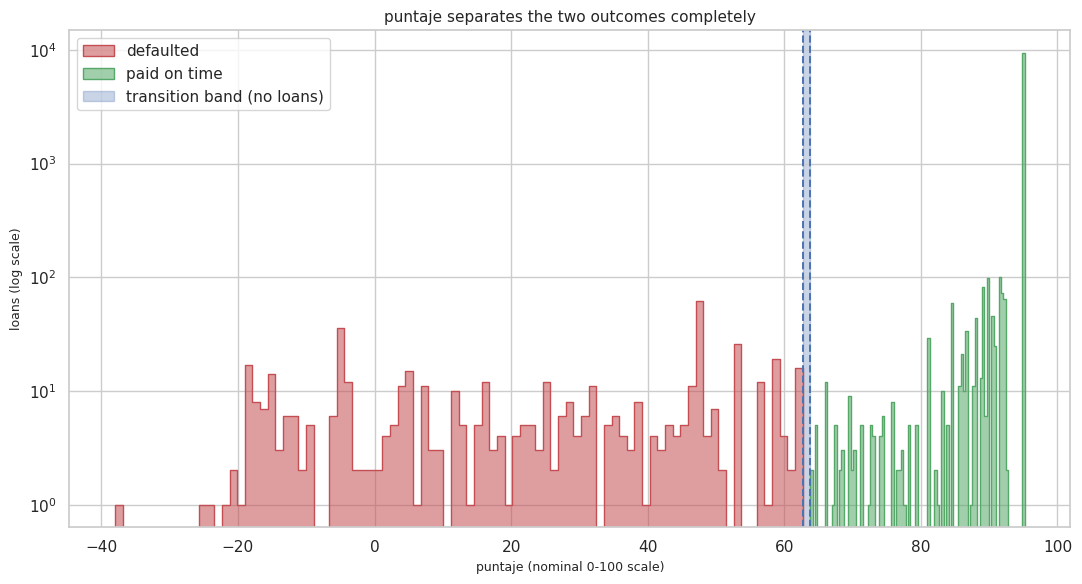

highest puntaje among defaults : 62.67
lowest  puntaje among paid     : 63.81
empty corridor                 : 1.14 points wide
accuracy of the midpoint cut   : 1.0000 on 10,763 rows
observed minimum               : -38.01  (nominal floor is 0)
rows below zero                : 135 -- of which defaults: 135


In [63]:
gap_lo = df.loc[df[TARGET] == 0, "puntaje"].max()
gap_hi = df.loc[df[TARGET] == 1, "puntaje"].min()
cut = (gap_lo + gap_hi) / 2
accuracy = ((df["puntaje"] > cut).astype(int) == df[TARGET]).mean()

# Asserted, not assumed: the whole argument is that the corridor is EMPTY. If a single
# loan of either class ever landed inside it the figure would still look convincing.
assert df["puntaje"].between(gap_lo, gap_hi, inclusive="neither").sum() == 0

n_below_zero = int((df["puntaje"] < 0).sum())
defaults_below_zero = int((df.loc[df["puntaje"] < 0, TARGET] == 0).sum())

fig, ax = plt.subplots(figsize=(11, 6))
for value, colour, label in [(0, "#c44e52", "defaulted"), (1, "#55a868", "paid on time")]:
    sns.histplot(df.loc[df[TARGET] == value, "puntaje"], bins=90, ax=ax,
                 color=colour, label=label, element="step", alpha=.55)
# ~1.1 wide on a ~135-wide axis, so the edges have to be drawn for the band to register
# at all. That narrowness is itself the finding.
ax.axvspan(gap_lo, gap_hi, color="#4c72b0", alpha=.30, zorder=0,
           label="transition band (no loans)")
for edge in (gap_lo, gap_hi):
    ax.axvline(edge, color="#4c72b0", ls="--", lw=1.4, zorder=1)
ax.set_yscale("log")
ax.set_xlabel("puntaje (nominal 0-100 scale)")
ax.set_ylabel("loans (log scale)")
ax.set_title("puntaje separates the two outcomes completely")
ax.legend(loc="upper left")
show_fig(fig, "F01_leakage_score_distribution")
plt.show()

print(f"highest puntaje among defaults : {gap_lo:.2f}")
print(f"lowest  puntaje among paid     : {gap_hi:.2f}")
print(f"empty corridor                 : {gap_hi - gap_lo:.2f} points wide")
print(f"accuracy of the midpoint cut   : {accuracy:.4f} on {len(df):,} rows")
print(f"observed minimum               : {df['puntaje'].min():.2f}  (nominal floor is 0)")
print(f"rows below zero                : {n_below_zero} -- of which defaults: {defaults_below_zero}")

The column also runs *below zero* against a nominal 0–100 scale, and the rows that doare **all** defaults — finding 1 showing up a second time, in the data-quality layer.#### 6.1.2 It is a two-state flag, not a gradientMost of the book sits on **one repeated value**, and every loan on it paid on time. Theremaining rows carry a genuine-looking score and contain **every default in the file**.The repeated value is acting as *"nothing bad on file"*: this is not a score with asentinel in it, it is a flag with a score attached to the bad half.

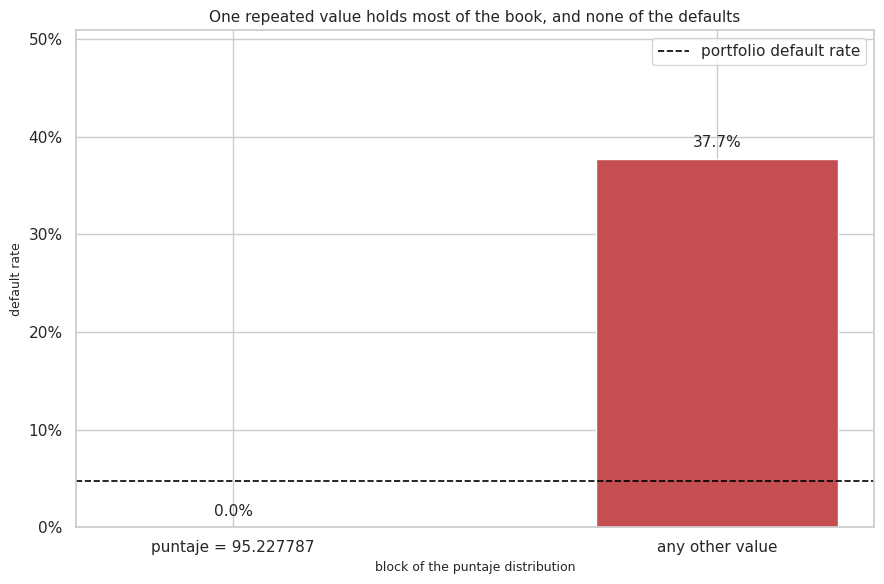

,n,pct_of_book,defaults,default_rate
puntaje = 95.227787,9407,0.8740,0,0.0000
any other value,1356,0.1260,511,0.3768


In [64]:
sentinel = CFG["sentinels"]["puntaje"][0]
at_sentinel = df["puntaje"].eq(sentinel)

blocks = pd.DataFrame({
    "n": [int(at_sentinel.sum()), int((~at_sentinel).sum())],
    "default_rate": [1 - df.loc[at_sentinel, TARGET].mean(),
                     1 - df.loc[~at_sentinel, TARGET].mean()],
}, index=[f"puntaje = {sentinel}", "any other value"])
blocks["defaults"] = [int((df.loc[at_sentinel, TARGET] == 0).sum()),
                      int((df.loc[~at_sentinel, TARGET] == 0).sum())]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.bar(blocks.index, blocks["default_rate"], color=["#4c72b0", "#c44e52"], width=.5)
ax.axhline(base_rate, ls="--", color="black", lw=1.2, label="portfolio default rate")
for bar, rate in zip(bars, blocks["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + .012, f"{rate:.1%}",
            ha="center", fontsize=11)
ax.set_ylim(0, blocks["default_rate"].max() * 1.35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("block of the puntaje distribution")
ax.set_ylabel("default rate")
ax.set_title("One repeated value holds most of the book, and none of the defaults")
ax.legend()
show_fig(fig, "F02_leakage_sentinel_block")
plt.show()

blocks["pct_of_book"] = blocks["n"] / len(df)
display(blocks[["n", "pct_of_book", "defaults", "default_rate"]])

**Confirmed against the Colombian regulatory context.** The Superintendencia Financierarequires supervised entities to assess credit risk at origination *and throughout the lifeof the credit*, so a warehouse routinely holds two different scores per loan. In Colombian*score de comportamiento* (behavioural) models the client is labelled "bad" on reachingarrears beyond 60 or 90 days inside a 12-month observation window — the same event`Pago_atiempo` encodes. A behavioural score is therefore **a function of the outcome byconstruction**, and that is exactly the shape here: perfect separation, a"nothing-on-file" default value for the majority who never went bad, and a real score onlyfor the clients who generated payment history worth scoring.`puntaje` is on a 0–100 scale and is **not** the DataCrédito score, which runs 150–950 andlives in the separate `puntaje_datacredito` column — finding 2.**What we do about it.** Flagged in `config.json` under `leakage_columns` and excludedfrom every ranking and from the modelling frame in section 5.1. It is deliberately *kept*in the dataset so section 3.2.1 can demonstrate the problem rather than quietly hide it.#### 6.1.3 The trap worth repeating: leakage propagatesA data-quality variable counting range-rule violations per row was, at first, by far thestrongest non-`puntaje` signal in the project. It was fake. One of the rules bounds`puntaje` to [0, 100], and every row violating it is a default — the counter waslaundering the leakage through an innocent-looking aggregate. Rebuilt from leakage-freerules only (section 2.6), it collapses to nothing.**Removing the leaking column is not enough; everything derived from it has to be auditedtoo.**

In [65]:
rho_all = stats.spearmanr(df["n_reglas_violadas_todas"], df[TARGET]).statistic
rho_safe = stats.spearmanr(df["n_reglas_violadas"], df[TARGET]).statistic
print(f"rule counter including the puntaje rule : rho = {rho_all:+.3f}")
print(f"rule counter from leakage-free rules    : rho = {rho_safe:+.3f}")
print(f"\nthe difference is entirely the {int((df['puntaje'] < 0).sum())} out-of-range puntaje rows, "
      f"which are {(df.loc[df['puntaje'] < 0, TARGET] == 0).mean():.0%} defaults")

rule counter including the puntaje rule : rho = -0.287
rule counter from leakage-free rules    : rho = -0.008

the difference is entirely the 135 out-of-range puntaje rows, which are 100% defaults


### Finding 2 · What a legitimate score looks likeIf finding 1 is *"this column is too good to be true"*, finding 2 is *"here is the samekind of quantity, behaving the way it should"*. The contrast is the argument.#### 6.2.1 The distribution`puntaje_datacredito` is unimodal, left-skewed and concentrated at the top of the scale.Practically the whole book sits between 650 and 900.

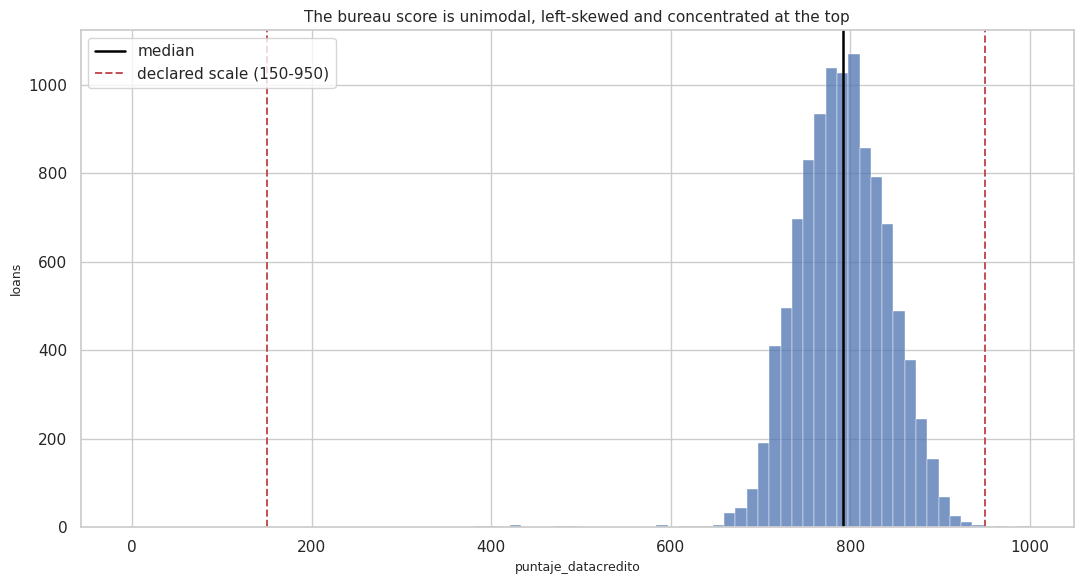

median 792 | IQR 758-826
skew / kurtosis, all values      : -1.30 / 14.6
skew / kurtosis, inside 150-950 : -0.71 / 5.2

The shape statistics are reported both ways on purpose. The 8 impossible
values below inflate the kurtosis roughly threefold on their own; quoting only the
unrestricted moment would describe the defects, not the distribution.
out-of-scale values: ['-7', '7', '951', '968', '969', '978', '987', '999']


In [66]:
score = df["puntaje_datacredito"].astype(float)
lo, hi = REF["bureau_score_range"]
in_scale = score.where(score.between(lo, hi))
out_of_scale = score[(score < lo) | (score > hi)]

fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(score, bins=80, ax=ax, color="#4c72b0", edgecolor="white", linewidth=.3)
ax.axvline(score.median(), color="black", lw=1.8, label="median")
ax.axvline(lo, color="#c44e52", ls="--", lw=1.4, label=f"declared scale ({lo}-{hi})")
ax.axvline(hi, color="#c44e52", ls="--", lw=1.4)
ax.set_xlabel("puntaje_datacredito")
ax.set_ylabel("loans")
ax.set_title("The bureau score is unimodal, left-skewed and concentrated at the top")
ax.legend(loc="upper left")
show_fig(fig, "F03_bureau_score_distribution")
plt.show()

print(f"median {score.median():.0f} | IQR {score.quantile(.25):.0f}-{score.quantile(.75):.0f}")
print(f"skew / kurtosis, all values      : {score.skew():+.2f} / {score.kurt():.1f}")
print(f"skew / kurtosis, inside {lo}-{hi} : {in_scale.skew():+.2f} / {in_scale.kurt():.1f}")
print(f"\nThe shape statistics are reported both ways on purpose. The {len(out_of_scale)} impossible")
print(f"values below inflate the kurtosis roughly threefold on their own; quoting only the")
print(f"unrestricted moment would describe the defects, not the distribution.")
print(f"out-of-scale values: {[f'{v:g}' for v in sorted(out_of_scale.unique())]}")

**Two data issues, and what the notebook does with each.**- **The rows storing `0`.** Zero is not a bureau score of zero, it means *not scored*. It  is declared in `config.json` under `sentinels` and converted to null in section 2.4.  Left as a number it would have dragged the mean down by ~10 points and put a phantom  spike at the bottom of every histogram. Turning a disguised unknown into an explicit  null is the opposite of imputing: it *removes* a value the file was asserting falsely.- **The handful of values outside the official 150–950 scale.** These are impossible  values, not extreme clients. They are **counted and reported (section 2.6), not  nulled and not repaired** — this notebook does not fix data, it documents it. So they  remain in the column, and every shape statistic above is therefore given twice.`150–950` is the published DataCrédito Experian range, so the rule is external, not fittedto the data.

In [67]:
unscored = score.isna()
print(f"no bureau score at all       : {int(unscored.sum())} rows")
print(f"  of which sentinel zeros    : {n_unscored_sentinel}")
print(f"  of which genuinely blank   : {int(unscored.sum()) - n_unscored_sentinel}")
print(f"still out of the 150-950 scale after cleaning: {len(out_of_scale)} rows -- "
      f"flagged, not corrected")

no bureau score at all       : 151 rows
  of which sentinel zeros    : 145
  of which genuinely blank   : 6
still out of the 150-950 scale after cleaning: 8 rows -- flagged, not corrected


**What it means for the business.** A median in the high 700s on a 150–950 scale is awell-rated book. Combined with the arrears rate in finding 5, the reading is that **thelender is already pre-screening hard on the bureau**. That matters for interpretation: theweak correlations everywhere in this dataset are partly a *consequence of goodunderwriting*, not evidence that bureau data is useless.#### 6.2.2 It behaves like a scoreDefault rate falls **monotonically** across the bands. Statistically solid, practicallymodest — and the second strongest leakage-free signal in the file.**Read it honestly.** The two leftmost bars are hatched because they rest on very fewloans. The direction is real; the exact heights are not.

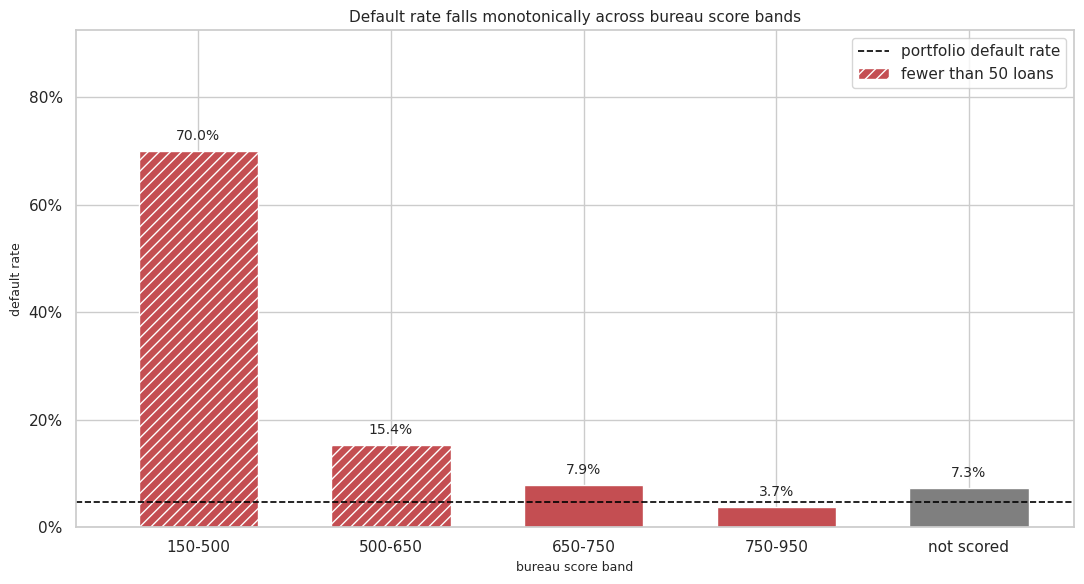

,n,default_rate
puntaje_datacredito,,
150-500,20,0.7000
500-650,13,0.1538
650-750,2136,0.0791
750-950,8435,0.0373


Spearman vs target: rho = +0.091 (p = 6.1e-21)
unscored clients  : 7.3% vs 4.7% overall, on 151 loans -- chi2 p = 0.20


In [68]:
labels = ["150-500", "500-650", "650-750", "750-950"]
bands = pd.cut(in_scale, [lo, 500, 650, 750, hi], labels=labels)
g = df[TARGET].groupby(bands, observed=False)
band_tab = pd.DataFrame({"n": g.size(), "default_rate": 1 - g.mean()})
unscored_rate = 1 - df.loc[unscored, TARGET].mean()
unscored_p = stats.chi2_contingency(pd.crosstab(unscored, df[TARGET]).to_numpy())[1]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(range(len(band_tab)), band_tab["default_rate"], color="#c44e52", width=.62)
for bar, n in zip(bars, band_tab["n"]):
    if n < 50:                        # the height is real, the precision is not
        bar.set_hatch("///"); bar.set_edgecolor("white")
ax.bar(0, 0, color="#c44e52", hatch="///", edgecolor="white", label="fewer than 50 loans")
ax.bar(len(band_tab), unscored_rate, color="#7f7f7f", width=.62)
ax.axhline(base_rate, ls="--", color="black", lw=1.2, label="portfolio default rate")
for i, rate in enumerate(band_tab["default_rate"]):
    ax.text(i, rate + .02, f"{rate:.1%}", ha="center", fontsize=10)
ax.text(len(band_tab), unscored_rate + .02, f"{unscored_rate:.1%}", ha="center", fontsize=10)
ax.set_xticks(range(len(band_tab) + 1))
ax.set_xticklabels(labels + ["not scored"])
ax.set_xlabel("bureau score band")
ax.set_ylabel("default rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, band_tab["default_rate"].max() * 1.32)
ax.set_title("Default rate falls monotonically across bureau score bands")
ax.legend()
show_fig(fig, "F04_bureau_score_default_by_band")
plt.show()

display(band_tab)
m = score.notna()
rho, p = stats.spearmanr(score[m], df.loc[m, TARGET])
print(f"Spearman vs target: rho = {rho:+.3f} (p = {p:.1e})")
print(f"unscored clients  : {unscored_rate:.1%} vs {base_rate:.1%} overall, "
      f"on {int(unscored.sum())} loans -- chi2 p = {unscored_p:.2f}")

**The unscored group.** Clients with no bureau score default above the portfolio rate, buton so few loans that the difference is **not statistically significant**.`sin_score_bureau` is worth keeping because missingness is often informative, but thisdataset does not prove it is. Its sister variable `sin_info_ingresos_bureau` (no bureauincome record) *does* separate.

In [69]:
no_income = df["promedio_ingresos_datacredito"].isna()
print(f"sin_info_ingresos_bureau: {int(no_income.sum()):,} rows, "
      f"{1 - df.loc[no_income, TARGET].mean():.2%} default "
      f"vs {1 - df.loc[~no_income, TARGET].mean():.2%} for the rest")

sin_info_ingresos_bureau: 2,930 rows, 5.73% default vs 4.38% for the rest


#### 6.2.3 The comparison that carries the argumentSame encoding as figure F01 — split by outcome, log counts — so the two can be read sideby side. There the classes never touch. Here they overlap almost completely: knowing aclient's bureau score narrows the answer, it does not give it away.**Scores that predict look like slopes. Scores that leak look like walls.** That is adiagnostic anyone in the room can apply to the next dataset without any statistics.

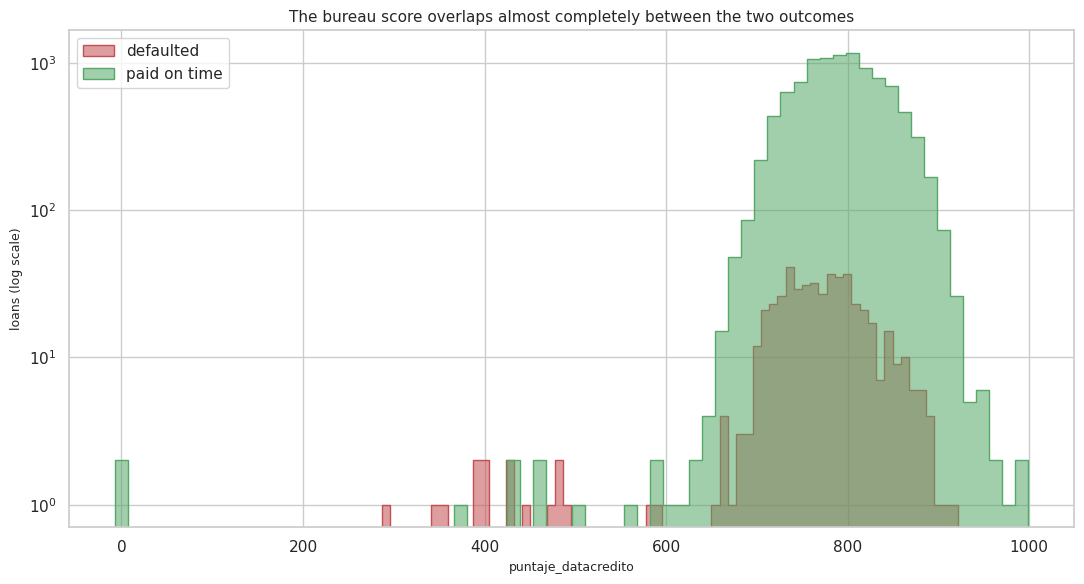

the two classes overlap over 287-922, which contains 99.7% of all scored loans
compare finding 1: an empty corridor, 0% of loans inside it


In [70]:
fig, ax = plt.subplots(figsize=(11, 6))
for value, colour, label in [(0, "#c44e52", "defaulted"), (1, "#55a868", "paid on time")]:
    sns.histplot(score[df[TARGET] == value], bins=70, ax=ax,
                 color=colour, label=label, element="step", alpha=.55)
ax.set_yscale("log")
ax.set_xlabel("puntaje_datacredito")
ax.set_ylabel("loans (log scale)")
ax.set_title("The bureau score overlaps almost completely between the two outcomes")
ax.legend(loc="upper left")
show_fig(fig, "F19_bureau_score_by_outcome")
plt.show()

ov_lo = max(score[df[TARGET] == 0].min(), score[df[TARGET] == 1].min())
ov_hi = min(score[df[TARGET] == 0].max(), score[df[TARGET] == 1].max())
inside = score.between(ov_lo, ov_hi).sum()
print(f"the two classes overlap over {ov_lo:.0f}-{ov_hi:.0f}, which contains "
      f"{inside / score.notna().sum():.1%} of all scored loans")
print(f"compare finding 1: an empty corridor, 0% of loans inside it")

#### 6.2.4 The two scores are not the same instrumentIf `puntaje` were an internal recalibration of the bureau score, this plot would show adiagonal. It does not. The dashed line is the **hypothetical** relationship — whereclients would fall if both instruments ranked the same risk and each used its declaredscale end to end. It is anchored on the two official ranges, not fitted to this sample, soit is a reference rather than a result.The repeated-value line spans the entire bureau range: clients the bureau rates asidentical land on both sides of the split that decides the outcome. Whatever `puntaje` ismeasuring, it is not bureau risk.

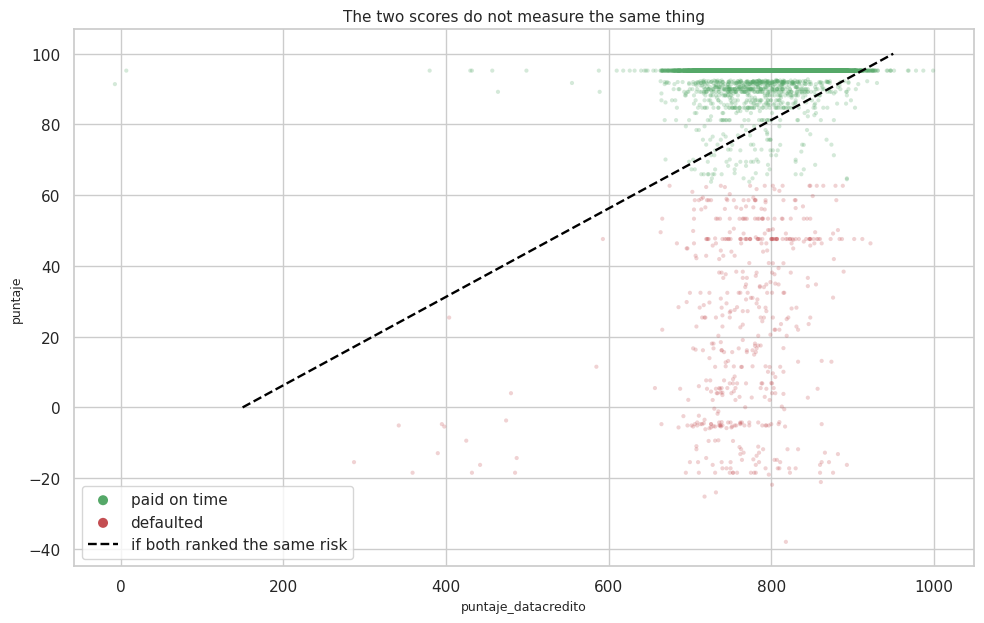

Spearman between the two scores: rho = +0.1181 on n = 10,612


In [71]:
both = df["puntaje"].notna() & score.notna()
fig, ax = plt.subplots(figsize=(10, 6.4))
for value, colour, label in [(1, "#55a868", "paid on time"), (0, "#c44e52", "defaulted")]:
    m = both & df[TARGET].eq(value)
    ax.scatter(score[m], df.loc[m, "puntaje"], s=9, alpha=.25,
               color=colour, edgecolor="none", label=label)
ax.plot([lo, hi], [0, 100], ls="--", color="black", lw=1.7, zorder=4,
        label="if both ranked the same risk")
ax.set_xlabel("puntaje_datacredito")
ax.set_ylabel("puntaje")
ax.set_title("The two scores do not measure the same thing")
leg = ax.legend(loc="lower left", markerscale=2.4)
for h in leg.legend_handles:
    h.set_alpha(1)
show_fig(fig, "F18_two_scores_against_each_other")
plt.show()

rho_scores = stats.spearmanr(df.loc[both, "puntaje"], score[both]).statistic
print(f"Spearman between the two scores: rho = {rho_scores:+.4f} on n = {int(both.sum()):,}")

### Finding 3 · Pearson misses what Spearman finds#### 6.3.1 Where the two measures disagreeThe twelve variable pairs with the largest `|rho| - |r|` gap. Almost all of them share oneshape: **rho between 0.29 and 0.45 while r is indistinguishable from zero**, and in fourcases r is slightly *negative*. Only one pair in the chart is strong under both measures,and it is there for contrast.**Why the three starred pairs and not literally the top three.** The literal rankingspends its second slot on `salario_cliente x saldo_principal`, which is the samerelationship as slot one: `saldo_total` and `saldo_principal` correlate at rho = 0.95 andare *exactly equal* in most rows (the difference is accrued interest). Presenting bothwould be presenting one finding twice. The starred three are the top three **distinct**relationships.

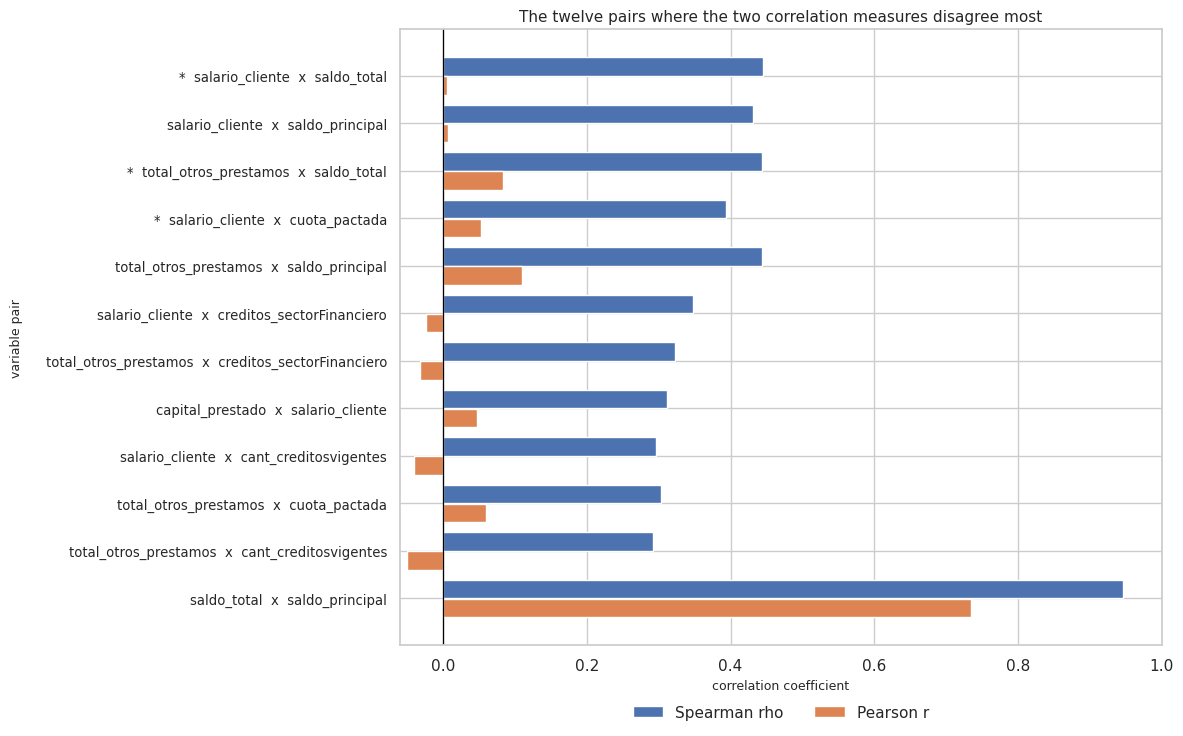

of the 12 pairs plotted, 11 have |r| < 0.15 while rho runs 0.29-0.45
4 of them have a slightly NEGATIVE r
1 pair(s) strong under both measures, shown for contrast



pearson  spearman    gap  rank
salario_cliente       saldo_total                 0.0048    0.4454 0.4406     1
                      saldo_principal             0.0072    0.4308 0.4236     2
total_otros_prestamos saldo_total                 0.0828    0.4438 0.3611     3
salario_cliente       cuota_pactada               0.0524    0.3933 0.3409     4
total_otros_prestamos saldo_principal             0.1102    0.4435 0.3333     5
salario_cliente       creditos_sectorFinanciero  -0.0243    0.3474 0.3232     6
total_otros_prestamos creditos_sectorFinanciero  -0.0319    0.3232 0.2912     7
capital_prestado      salario_cliente             0.0470    0.3111 0.2640     8
salario_cliente       cant_creditosvigentes      -0.0406    0.2956 0.2550     9
total_otros_prestamos cuota_pactada               0.0594    0.3030 0.2435    10
                      cant_creditosvigentes      -0.0502    0.2916 0.2414    11
saldo_total           saldo_principal             0.7347    0.9463 0.2117    12


top 3 distinct relationships:
  salario_cliente x saldo_total: r = +0.005, rho = +0.445, gap = 0.441
  total_otros_prestamos x saldo_total: r = +0.083, rho = +0.444, gap = 0.361
  salario_cliente x cuota_pactada: r = +0.052, rho = +0.393, gap = 0.341


In [72]:
gap_pairs = pairs.drop(columns="abs_spearman").sort_values("gap", ascending=False)
top12 = gap_pairs.head(12)

seen, top3 = set(), []
for (a, b), row in gap_pairs.iterrows():
    key = frozenset({a.replace("saldo_principal", "saldo_total"),
                     b.replace("saldo_principal", "saldo_total")})
    if key in seen:
        continue
    seen.add(key); top3.append(((a, b), row))
    if len(top3) == 3:
        break

plot_pairs = top12.iloc[::-1]
highlight = {frozenset(k) for k, _ in top3}
fig, ax = plt.subplots(figsize=(12, 7.5))
ypos = np.arange(len(plot_pairs))
ax.barh(ypos + .2, plot_pairs["spearman"], height=.38, color="#4c72b0", label="Spearman rho")
ax.barh(ypos - .2, plot_pairs["pearson"], height=.38, color="#dd8452", label="Pearson r")
ax.set_yticks(ypos)
ax.set_yticklabels([("*  " if frozenset(i) in highlight else "    ")
                    + f"{i[0]}  x  {i[1]}" for i in plot_pairs.index], fontsize=9.5)
ax.axvline(0, color="black", lw=.9)
ax.set_xlim(-.06, 1.0)
ax.set_xlabel("correlation coefficient")
ax.set_ylabel("variable pair")
ax.set_title("The twelve pairs where the two correlation measures disagree most")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.075), ncols=2, frameon=False)
show_fig(fig, "F05_pearson_vs_spearman_ranking")
plt.show()

flat = top12[top12["pearson"].abs() < .15]
print(f"of the {len(top12)} pairs plotted, {len(flat)} have |r| < 0.15 while rho runs "
      f"{flat['spearman'].min():.2f}-{flat['spearman'].max():.2f}")
print(f"{int((top12['pearson'] < 0).sum())} of them have a slightly NEGATIVE r")
print(f"{len(top12) - len(flat)} pair(s) strong under both measures, shown for contrast\n")
display(top12.assign(rank=range(1, len(top12) + 1)))
print("\ntop 3 distinct relationships:")
for (a, b), r in top3:
    print(f"  {a} x {b}: r = {r.pearson:+.3f}, rho = {r.spearman:+.3f}, gap = {r.gap:.3f}")

**What it means.** Reporting Pearson alone would have led to dropping every salary-derivedvariable from the project as "uncorrelated with everything". The affordability ratios insection 4 exist because Spearman found these relationships first.#### 6.3.2 Pair 1 — why Pearson fails hereRaw axes. Every real client is crushed onto the y-axis by a handful of records withenormous declared salaries. Those records are unit errors — values roughly 1000x toolarge — not wealthy clients. Pearson is computed on squared deviations from the mean, so adozen records six orders of magnitude out dominate the coefficient completely. **Thenumber is describing the outliers, not the clients.**

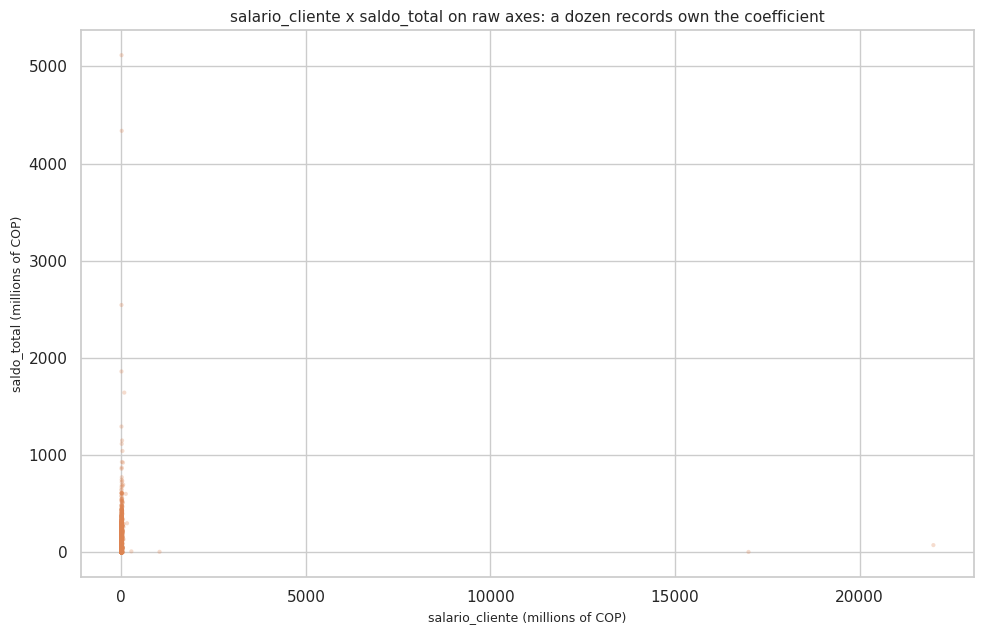

Pearson r on raw axes : +0.005
median salario_cliente: 3,000,000 COP | maximum: 22,000,000,000 COP


In [73]:
X1, Y1 = top3[0][0]
sub = df[[X1, Y1]].astype(float).dropna()

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.scatter(sub[X1] / 1e6, sub[Y1] / 1e6, s=9, alpha=.28, color="#dd8452", edgecolor="none")
ax.set_xlabel(f"{X1} (millions of COP)")
ax.set_ylabel(f"{Y1} (millions of COP)")
ax.set_title(f"{X1} x {Y1} on raw axes: a dozen records own the coefficient")
show_fig(fig, "F06_gap_pair1_raw_axes")
plt.show()

print(f"Pearson r on raw axes : {stats.pearsonr(sub[X1], sub[Y1]).statistic:+.3f}")
print(f"median {X1}: {df[X1].median():,.0f} COP | maximum: {df[X1].max():,.0f} COP")

#### 6.3.3 Pair 1 — the same data, in rank spaceBoth variables converted to percentile ranks, the space Spearman actually measures. Theblack line is the median y-percentile inside each 5% band of x, and it climbs steadilyfrom the bottom of the distribution to the top. The relationship was there all along; theraw-axis view could not show it.**A second thing the rank view reveals.** The vertical banding — declared salaries clusteron round numbers, so `salario_cliente` is partly self-reported and rounded. That is a factabout the *collection process*, and it is invisible on raw axes.

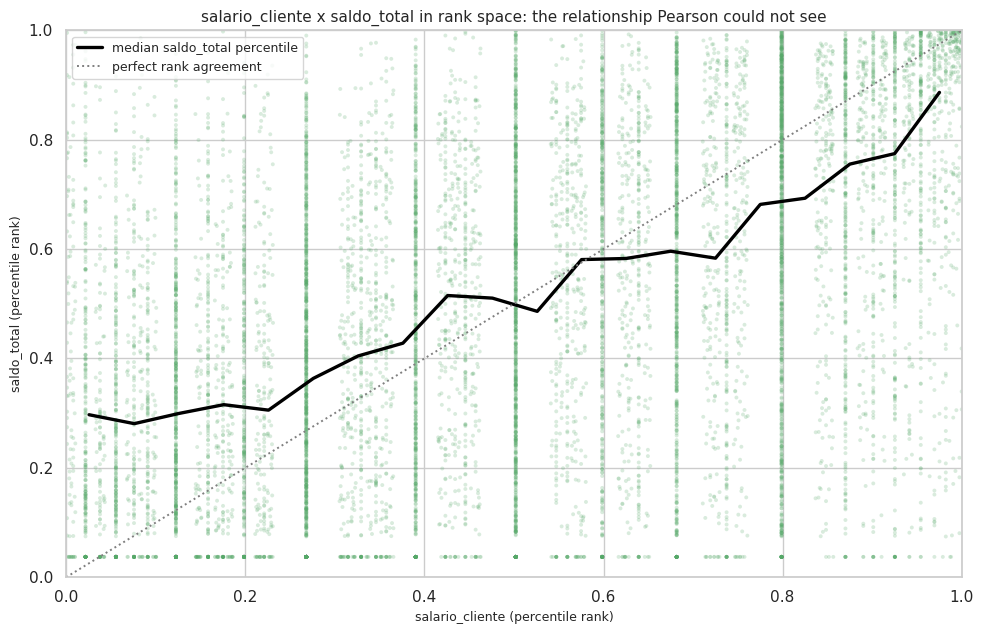

salario_cliente x saldo_total: r = +0.005, rho = +0.445


In [74]:
def rank_panel(x, y, name, title, size=(10, 6.5)):
    s = df[[x, y]].astype(float).dropna()
    r = stats.pearsonr(s[x], s[y]).statistic
    rho = stats.spearmanr(s[x], s[y]).statistic
    rx, ry = s[x].rank(pct=True), s[y].rank(pct=True)
    fig, ax = plt.subplots(figsize=size)
    ax.scatter(rx, ry, s=8, alpha=.22, color="#55a868", edgecolor="none")
    trend = ry.groupby(pd.cut(rx, 20), observed=True).median()
    ax.plot([iv.mid for iv in trend.index], trend.to_numpy(), color="black", lw=2.4,
            label=f"median {y} percentile")
    ax.plot([0, 1], [0, 1], ls=":", color="#7f7f7f", lw=1.4, label="perfect rank agreement")
    ax.set_xlabel(f"{x} (percentile rank)")
    ax.set_ylabel(f"{y} (percentile rank)")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=9)
    show_fig(fig, name)
    plt.show()
    print(f"{x} x {y}: r = {r:+.3f}, rho = {rho:+.3f}")


rank_panel(X1, Y1, "F07_gap_pair1_rank_space",
           f"{X1} x {Y1} in rank space: the relationship Pearson could not see")

#### 6.3.4 Pairs 2 and 3- **`total_otros_prestamos` x `saldo_total`.** Clients who declare larger monthly payments  on other loans do carry larger bureau balances. This is the internal-consistency check  that the *declared* figure on the application form and the *observed* figure on the  bureau file agree in rank order — a useful sanity result in its own right, and only  visible under Spearman.- **`salario_cliente` x `cuota_pactada`.** Higher earners are sold bigger instalments.  Commercially unsurprising, statistically invisible to Pearson. Note that this is the  lender's *own* pricing behaviour showing up in the data: `cuota_pactada` partly encodes  income, which matters when both go into a model.

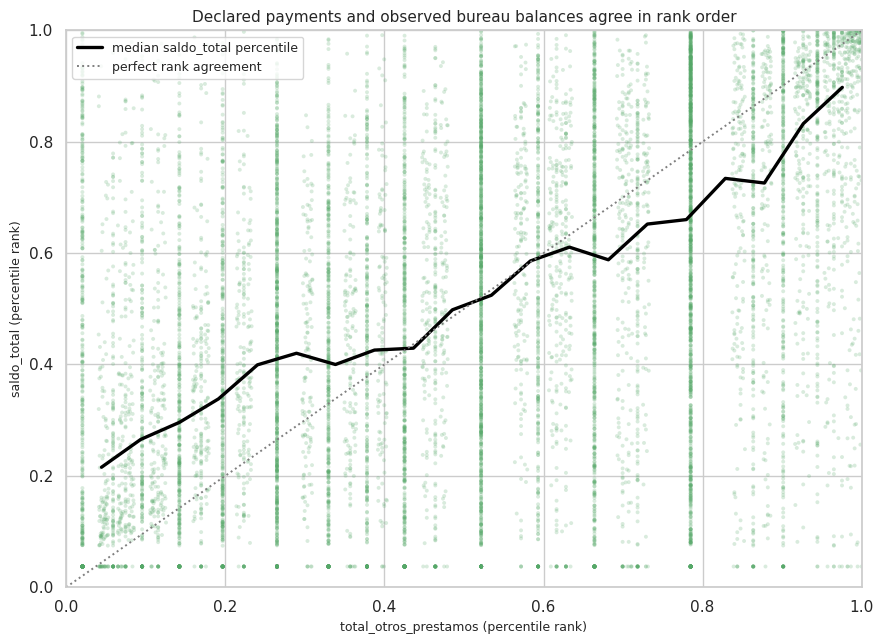

total_otros_prestamos x saldo_total: r = +0.083, rho = +0.444


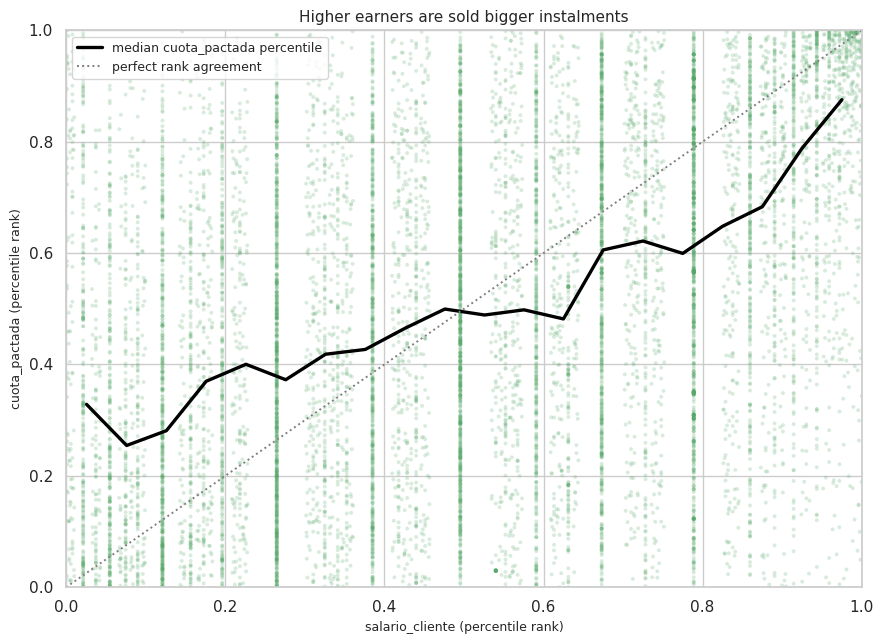

salario_cliente x cuota_pactada: r = +0.052, rho = +0.393


In [75]:
rank_panel(*top3[1][0], "F08_gap_pair2_rank_space",
           "Declared payments and observed bureau balances agree in rank order",
           size=(9, 6.6))
rank_panel(*top3[2][0], "F09_gap_pair3_rank_space",
           "Higher earners are sold bigger instalments", size=(9, 6.6))

#### 6.3.5 The gap runs the other way too`puntaje x Pago_atiempo` has the largest *negative* gap in the matrix: r far above rho.The reason is finding 1 — the relationship is a step function, not a gradient, and ranksinside the huge repeated-value block are arbitrary ties.**A large negative gap is its own diagnostic.** It says "this variable is blocky", whichis exactly what a sentinel-dominated or leaking column looks like.**What we do about it.** Rank-based statistics for all screening; log transforms ortree-based models downstream; and both coefficients reported side by side, never onealone.

In [76]:
r_leak = stats.pearsonr(df["puntaje"], df[TARGET]).statistic
rho_leak = stats.spearmanr(df["puntaje"], df[TARGET]).statistic
pb = stats.pointbiserialr(df[TARGET], df["puntaje"]).statistic
print(f"puntaje x {TARGET}: r = {r_leak:+.3f}, rho = {rho_leak:+.3f}, "
      f"gap = {abs(rho_leak) - abs(r_leak):+.3f}")
print(f"point-biserial (the correct name for Pearson against a dichotomous variable): "
      f"{pb:+.6f}")
print(f"identical to r by construction: {np.isclose(r_leak, pb)}")

puntaje x Pago_atiempo: r = +0.923, rho = +0.639, gap = -0.284
point-biserial (the correct name for Pearson against a dichotomous variable): +0.923134
identical to r by construction: True


### Finding 4 · Two columns that do not mean what their names sayNeither error shows up as a missing value or an out-of-range flag. Both silently corruptanything built on top of them — **including two variables calculated in section 4**.#### 6.4.1 The bureau balances are in thousands of COP**The problem.** Read as pesos, the typical client — holding five open credit obligations— would owe a fraction of one month's pay, and the median arrears balance would be a fewcents.**The proof.** Isolate the clients with **exactly one open obligation and a positivebalance**. Their entire bureau balance has to be that single loan, and we know what wejust lent them. As delivered, `capital_prestado / saldo_total` lands in the thousands.Divided by 1,000 it lands just above 1 — the loan has amortised part way down from itsoriginal principal, which is precisely what an outstanding balance should look like.Colombian portfolio balances are conventionally reported in *miles de pesos*, so this is aroutine convention rather than a corruption — but nothing in the file says so.

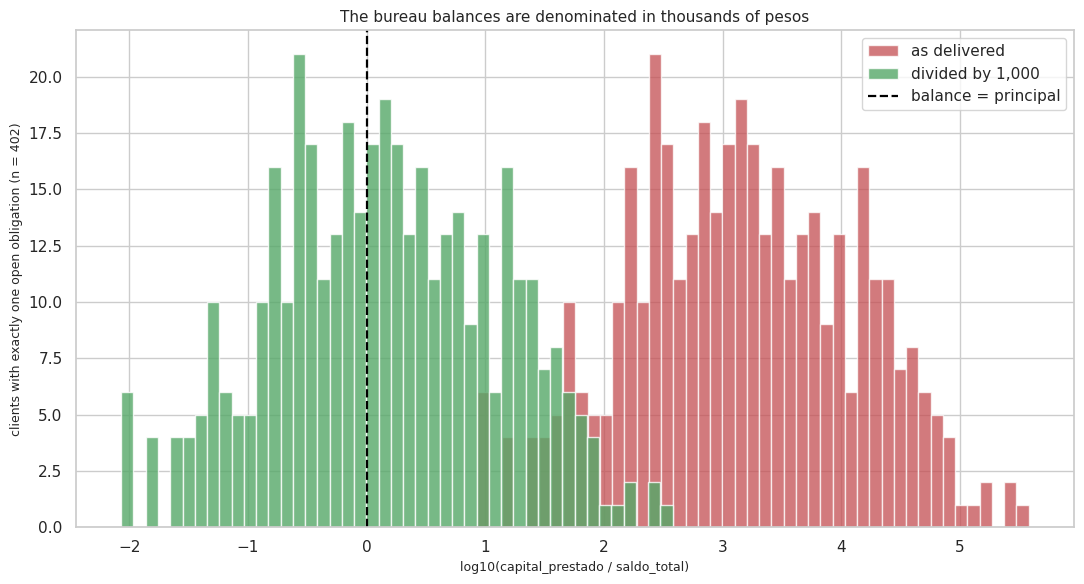

clients with exactly one open obligation      : 636
  of those, with a positive bureau balance    : 402  <- the test set
median capital / saldo_total, as delivered    : 1,338
median capital / saldo_total, scaled          : 1.34
  i.e. the outstanding balance is 74.7% of the original principal


In [77]:
n_one = int((df["cant_creditosvigentes"] == 1).sum())
solo = (df["cant_creditosvigentes"] == 1) & df["saldo_total"].gt(0)
scaled = df.loc[solo, "capital_prestado"] / df.loc[solo, "saldo_total"]
as_delivered = scaled * SCALE["factor"]

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(np.log10(as_delivered), bins=45, alpha=.75, color="#c44e52",
        label="as delivered")
ax.hist(np.log10(scaled), bins=45, alpha=.8, color="#55a868",
        label=f"divided by {SCALE['factor']:,}")
ax.axvline(0, color="black", ls="--", lw=1.6, label="balance = principal")
ax.set_xlabel("log10(capital_prestado / saldo_total)")
ax.set_ylabel(f"clients with exactly one open obligation (n = {int(solo.sum()):,})")
ax.set_title("The bureau balances are denominated in thousands of pesos")
ax.legend(loc="upper right")
show_fig(fig, "F10_units_thousands_of_pesos")
plt.show()

print(f"clients with exactly one open obligation      : {n_one:,}")
print(f"  of those, with a positive bureau balance    : {int(solo.sum()):,}  <- the test set")
print(f"median capital / saldo_total, as delivered    : {as_delivered.median():,.0f}")
print(f"median capital / saldo_total, scaled          : {scaled.median():,.2f}")
print(f"  i.e. the outstanding balance is {1 / scaled.median():.1%} of the original principal")

The scaling is applied in section 2.4.1 and driven by `unit_scale` in `config.json`. It isa **unit convention**, in the same family as parsing a date string into a date — not animputation and not a repair of a wrong value. Every quantity denominated in that columnchanges by a constant factor, and nothing is invented.**The defect it was hiding.** `ratio_saldo_capital` divided a thousands-denominatedbalance by a peso-denominated capital and was wrong by 1000x. Because the error was aconstant factor it never touched a Spearman ranking or a tree model — but the values weremeaningless, and any linear model or business statement quoting them would have beenwrong.

In [78]:
salary_med = df["salario_cliente"].median()
comparison = pd.DataFrame([
    {"quantity": "median total bureau debt",
     "as delivered": df["saldo_total"].median() / SCALE["factor"],
     "corrected": df["saldo_total"].median()},
    {"quantity": "median balance per open account",
     "as delivered": (df["saldo_total"] / df["cant_creditosvigentes"].astype(float)).median() / SCALE["factor"],
     "corrected": (df["saldo_total"] / df["cant_creditosvigentes"].astype(float)).median()},
    {"quantity": "median arrears when present",
     "as delivered": df.loc[df["saldo_mora"] > 0, "saldo_mora"].median() / SCALE["factor"],
     "corrected": df.loc[df["saldo_mora"] > 0, "saldo_mora"].median()},
]).set_index("quantity")
comparison["x monthly salary (corrected)"] = comparison["corrected"] / salary_med
display(comparison)

,as delivered,corrected,x monthly salary (corrected)
quantity,,,
median total bureau debt,"16,178.0000","16,178,000.0000",5.3927
median balance per open account,"3,305.0000","3,305,000.0000",1.1017
median arrears when present,236.0000,"236,000.0000",0.0787


#### 6.4.2 `total_otros_prestamos` is a payment, not a balance**The evidence.** Most of its values are exact multiples of 100,000 COP, and the modalvalues are precisely 2,000,000 / 1,000,000 / 500,000. Bureau balances are never round.This is a self-declared figure from the application form. It also sits at roughly a thirdof monthly salary — nonsense as a total outstanding debt, exactly right as a monthlyinstalment burden.

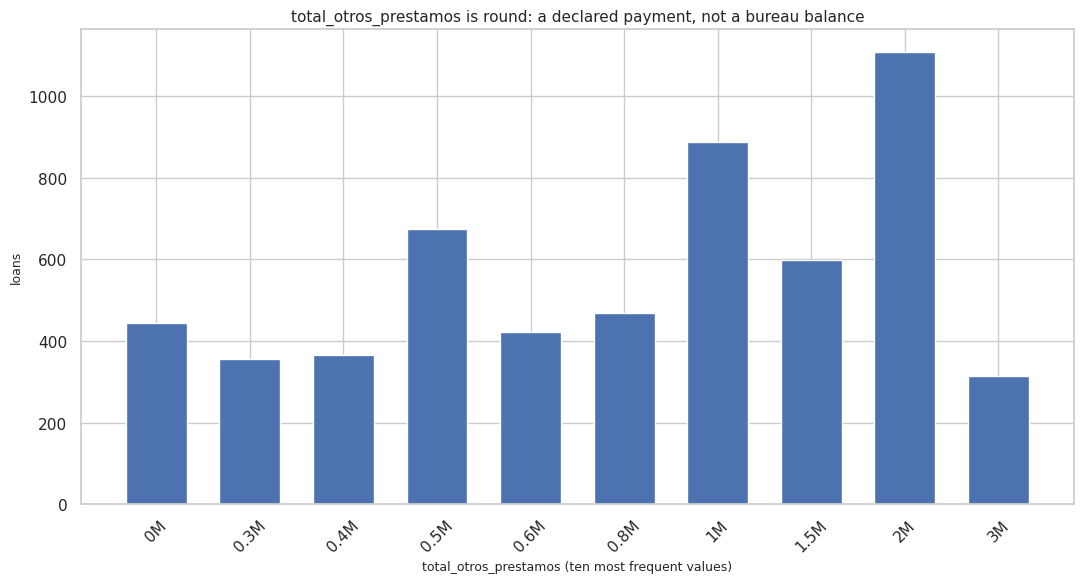

exact multiples of 100,000 COP : 76.0%
median as a multiple of salary : 0.333x


In [79]:
otros = df["total_otros_prestamos"].astype(float)
top_values = otros.value_counts().head(10).sort_index()

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar([f"{v/1e6:g}M" for v in top_values.index], top_values.to_numpy(),
       color="#4c72b0", width=.65)
ax.set_xlabel("total_otros_prestamos (ten most frequent values)")
ax.set_ylabel("loans")
ax.tick_params(axis="x", labelrotation=45)
ax.set_title("total_otros_prestamos is round: a declared payment, not a bureau balance")
show_fig(fig, "F11_declared_payment_not_balance")
plt.show()

print(f"exact multiples of 100,000 COP : {(otros % 100_000 == 0).mean():.1%}")
print(f"median as a multiple of salary : {(otros / df['salario_cliente'].replace(0, np.nan)).median():.3f}x")

**The defect it was hiding.** `carga_financiera_total` was originally built as`(cuota_pactada + total_otros_prestamos / 12) / salario`, dividing an already-monthlyfigure by twelve. Corrected to `(cuota_pactada + total_otros_prestamos) / salario`, themedian moves from a meaningless 0.09 to a plausible debt-service ratio, and itscorrelation with the target quadruples — still weak, but no longer noise.`ratio_deuda_salario` was renamed `ratio_pagos_otros_salario` so the name stops lying.#### 6.4.3 And what the corrected ratio actually saysColombian lenders conventionally cap debt service at **30–40% of monthly income** — 0–30%ideal, 30–40% moderate, above 40% risky. The median client in this book sits just outsidethe conventional band on the day the loan was granted.**And it does not predict default.** The "ideal" band has the *highest* default rate ofthe four.

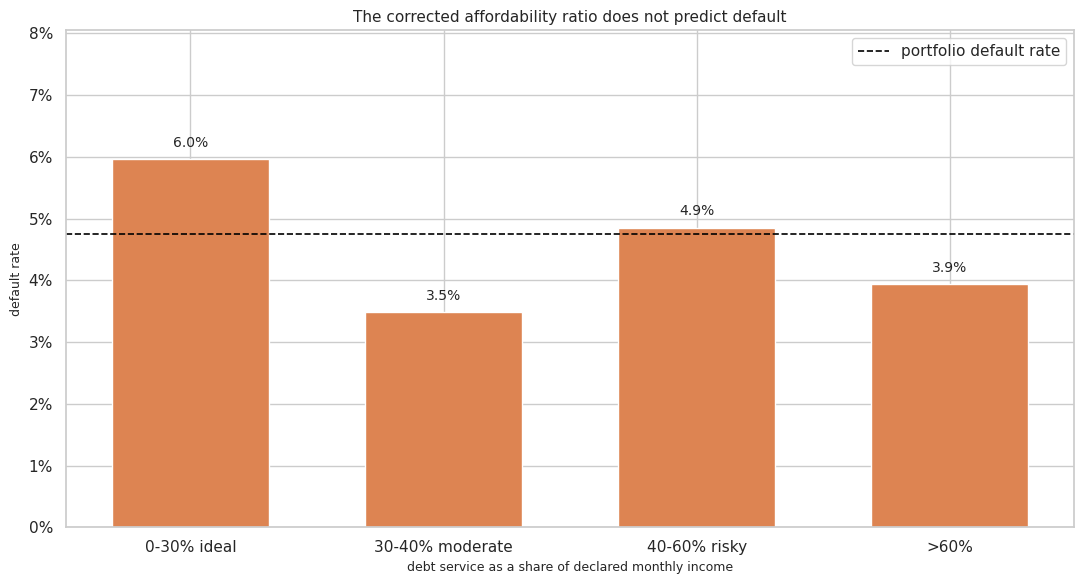

,n,default_rate
carga_financiera_total,,
0-30% ideal,2918,0.0596
30-40% moderate,1979,0.0349
40-60% risky,4038,0.0485
>60%,1804,0.0394


median debt-service ratio : 0.421
Spearman vs target        : +0.032


In [80]:
dsr = calc["carga_financiera_total"]
ideal = REF["debt_service_bands"]["ideal_max"]
moderate = REF["debt_service_bands"]["moderate_max"]
dsr_bands = pd.cut(dsr, [0, ideal, moderate, .60, np.inf],
                   labels=["0-30% ideal", "30-40% moderate", "40-60% risky", ">60%"])
g = df[TARGET].groupby(dsr_bands, observed=True)
dsr_tab = pd.DataFrame({"n": g.size(), "default_rate": 1 - g.mean()})

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(range(len(dsr_tab)), dsr_tab["default_rate"], color="#dd8452", width=.62)
ax.axhline(base_rate, ls="--", color="black", lw=1.2, label="portfolio default rate")
for bar, rate in zip(bars, dsr_tab["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + .002, f"{rate:.1%}",
            ha="center", fontsize=10)
ax.set_xticks(range(len(dsr_tab))); ax.set_xticklabels(dsr_tab.index)
ax.set_xlabel("debt service as a share of declared monthly income")
ax.set_ylabel("default rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, dsr_tab["default_rate"].max() * 1.35)
ax.set_title("The corrected affordability ratio does not predict default")
ax.legend()
show_fig(fig, "F12_debt_service_does_not_predict")
plt.show()

display(dsr_tab)
m = dsr.notna() & np.isfinite(dsr)
print(f"median debt-service ratio : {dsr.median():.3f}")
print(f"Spearman vs target        : {stats.spearmanr(dsr[m], df.loc[m, TARGET]).statistic:+.3f}")

The most likely reading is **selection**: the lender already underwrites on capacity, sowhat survives into the data is not a free sample. Clients who declare little other debtmay simply be the ones with thinner, less verifiable financial lives — a low declaredburden can mean "no obligations" or "nothing we could see".**The honest conclusion:** affordability ratios are the right things to compute and theyare now dimensionally correct, but **they are not where the signal is in this portfolio**.A stakeholder who expects them to be should be told so directly. Keep them forinterpretability and for the day the portfolio mix changes; do not build the pitch onthem.

### Finding 5 · Arrears already on file — the rule that works today#### 6.5.1 The signalLoans to clients carrying any arrears balance elsewhere (`saldo_mora > 0`) default at manytimes the portfolio rate. This is the cleanest actionable rule in the dataset and it needsno model: the information is already on the bureau file at application time.The clients whose bureau balance is **unknown** are excluded from both groups rather thanfolded into the clean one. Treating a missing balance as "no arrears" would be animputation, and a self-serving one: it would quietly count the clients we know least aboutas the safest in the book.

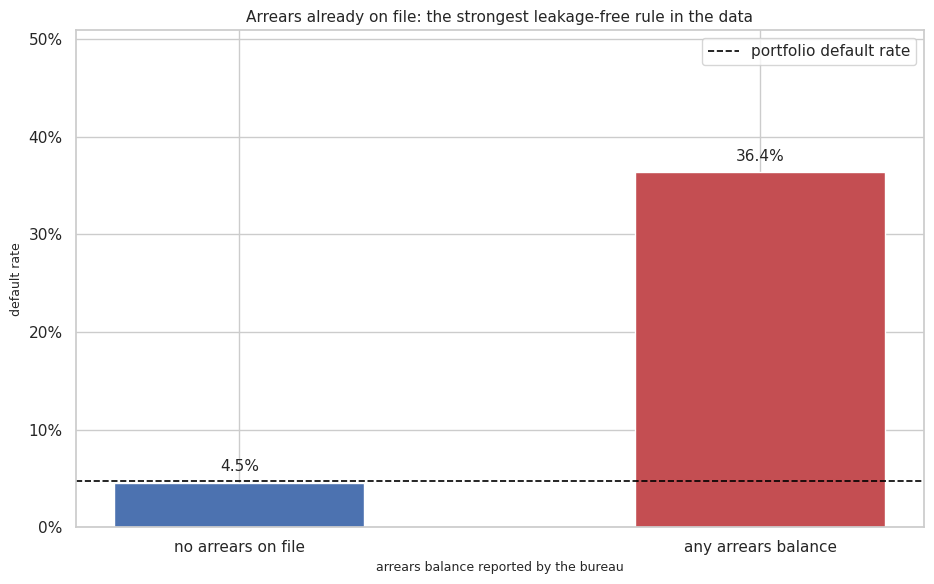

,n,default_rate,lift
no arrears on file,10552,0.0455,0.9581
any arrears balance,55,0.3636,7.6591


Fisher exact p = 2.19e-13
excluded as unknown (no bureau balance on file): 156 loans
median arrears among the flagged loans: 236,000 COP


In [81]:
known = df["saldo_mora"].notna()
arrears = known & df["saldo_mora"].gt(0)
clean = known & ~arrears

groups = pd.DataFrame({
    "n": [int(clean.sum()), int(arrears.sum())],
    "default_rate": [1 - df.loc[clean, TARGET].mean(), 1 - df.loc[arrears, TARGET].mean()],
}, index=["no arrears on file", "any arrears balance"])
groups["lift"] = groups["default_rate"] / base_rate

fig, ax = plt.subplots(figsize=(9.5, 6))
bars = ax.bar(groups.index, groups["default_rate"], color=["#4c72b0", "#c44e52"], width=.48)
ax.axhline(base_rate, ls="--", color="black", lw=1.2, label="portfolio default rate")
for bar, rate in zip(bars, groups["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + .012, f"{rate:.1%}",
            ha="center", fontsize=11)
ax.set_ylim(0, groups["default_rate"].max() * 1.4)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("arrears balance reported by the bureau")
ax.set_ylabel("default rate")
ax.set_title("Arrears already on file: the strongest leakage-free rule in the data")
ax.legend()
show_fig(fig, "F13_arrears_default_rate")
plt.show()

display(groups)
p_fisher = stats.fisher_exact(pd.crosstab(arrears[known], df.loc[known, TARGET]).to_numpy())[1]
print(f"Fisher exact p = {p_fisher:.2e}")
print(f"excluded as unknown (no bureau balance on file): {int((~known).sum())} loans")
print(f"median arrears among the flagged loans: {df.loc[arrears, 'saldo_mora'].median():,.0f} COP")

That median arrears figure is a real overdue amount, not a rounding residual — but it onlybecame legible after the unit correction in finding 4. Before it, the same number read asa couple of hundred pesos and looked like noise worth ignoring. **Finding 4 is what makesfinding 5 legible.**#### 6.5.2 What it costs to enforceA hard review flag on any application where the client shows an existing arrears balancecosts a fraction of a percent of volume and reaches a disproportionate share of thedefaults.

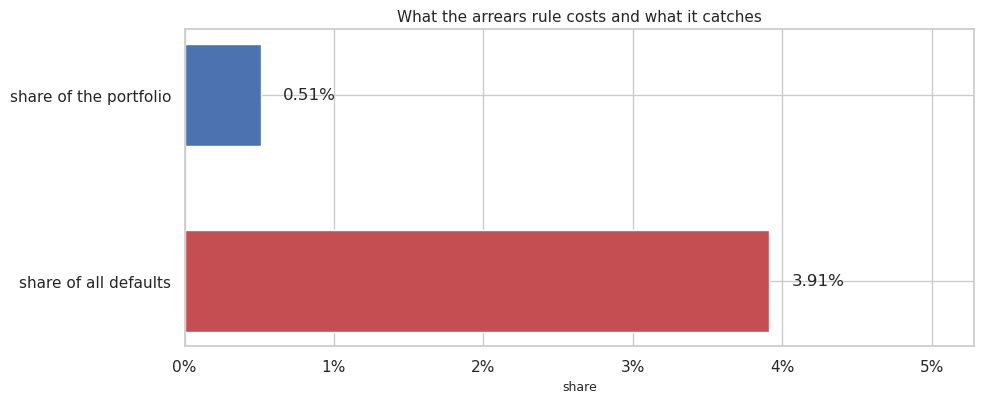

In [82]:
share_portfolio = arrears.mean()
share_defaults = (arrears & df[TARGET].eq(0)).sum() / (df[TARGET] == 0).sum()

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(["share of all defaults", "share of the portfolio"],
        [share_defaults, share_portfolio], color=["#c44e52", "#4c72b0"], height=.55)
for y, v in enumerate([share_defaults, share_portfolio]):
    ax.text(v + .0015, y, f"{v:.2%}", va="center", fontsize=12)
ax.set_xlim(0, max(share_portfolio, share_defaults) * 1.35)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlabel("share")
ax.set_ylabel("")
ax.set_title("What the arrears rule costs and what it catches")
show_fig(fig, "F14_arrears_cost_of_the_rule")
plt.show()

**Why it is rare, and why that matters.** Under Ley 2157 de 2021 negative bureau datapersists for twice the default period, capped at four years, so a client with arrears onfile stays visible for a long time. A flagged share this small is therefore **not a cleanpopulation — it is evidence the lender is already screening on this field**. The few whogot through are exceptions to an existing policy, which is exactly why they default soheavily.Two consequences, and the second is the one that gets forgotten:1. The rule is worth **enforcing consistently** rather than discovering.2. This variable will look far weaker in any sample that has *not* been pre-filtered this   way. Do not promise this lift on a new population.

### Finding 6 · Clients being turned down elsewhereDefault rate across deciles of`intensidad_consulta = huella_consulta / (cant_creditosvigentes + 1)` — credit inquiriesper account actually opened.**What it means.** This is the most useful continuous signal in the dataset and it readsnaturally to a business audience: **a client generating inquiries that are not convertinginto approvals is being turned down elsewhere.** It is a calculated variable — neither`huella_consulta` nor `cant_creditosvigentes` is nearly as informative alone.

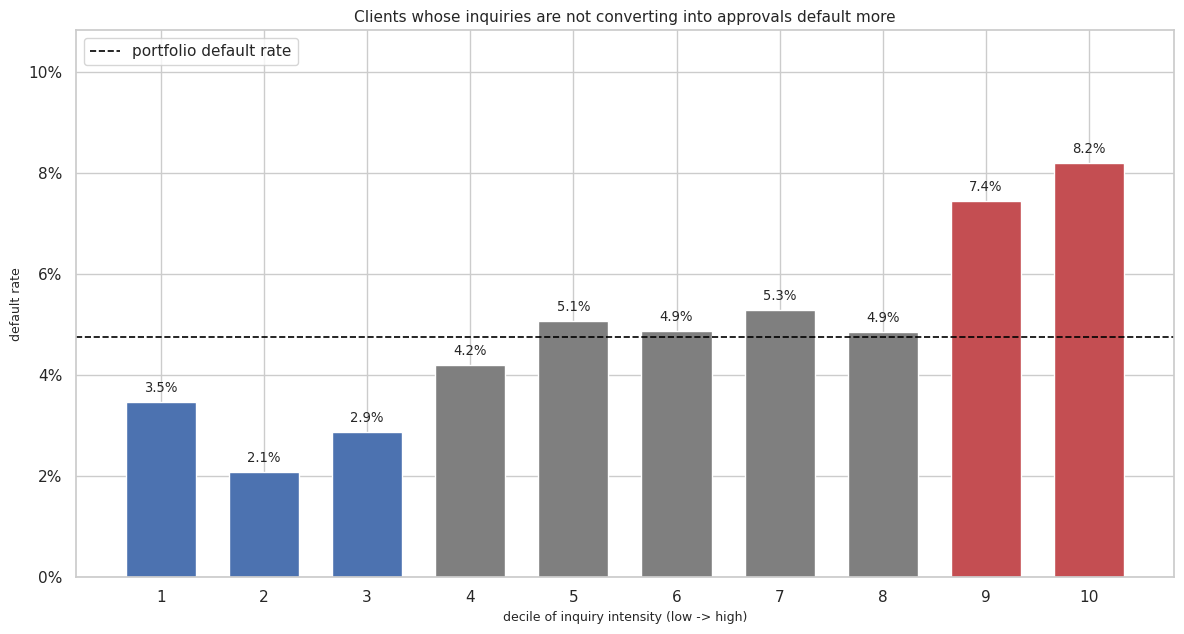

,n,default_rate
intensidad_consulta,,
0,1127,0.0346
1,1106,0.0208
2,1290,0.0287
3,1336,0.0419
4,690,0.0507
5,945,0.0487
6,1041,0.0528
7,1092,0.0485
8,1075,0.0744


top two deciles: 7.82%  vs bottom three: 2.81%  (2.8x)
Spearman vs target: rho = -0.077 (p = 1.8e-15)
decile sizes run 690 to 1,336 -- the variable has heavy ties


In [83]:
intensity = calc["intensidad_consulta"]
decile = pd.qcut(intensity, 10, duplicates="drop", labels=False)
g = df[TARGET].groupby(decile)
dec = pd.DataFrame({"n": g.size(), "default_rate": 1 - g.mean()})
low, high = dec.iloc[:3], dec.iloc[-2:]
low_rate = (low["default_rate"] * low["n"]).sum() / low["n"].sum()
high_rate = (high["default_rate"] * high["n"]).sum() / high["n"].sum()

fig, ax = plt.subplots(figsize=(12, 6.5))
colours = (["#4c72b0"] * 3 + ["#7f7f7f"] * (len(dec) - 5) + ["#c44e52"] * 2)[:len(dec)]
bars = ax.bar(range(len(dec)), dec["default_rate"], color=colours, width=.68)
ax.axhline(base_rate, ls="--", color="black", lw=1.2, label="portfolio default rate")
for bar, rate in zip(bars, dec["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + .002, f"{rate:.1%}",
            ha="center", fontsize=9.5)
ax.set_xticks(range(len(dec)))
ax.set_xticklabels([str(i + 1) for i in range(len(dec))])
ax.set_xlabel("decile of inquiry intensity (low -> high)")
ax.set_ylabel("default rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, dec["default_rate"].max() * 1.32)
ax.set_title("Clients whose inquiries are not converting into approvals default more")
ax.legend(loc="upper left")
show_fig(fig, "F15_inquiry_intensity_deciles")
plt.show()

display(dec)
m = intensity.notna()
rho, p = stats.spearmanr(intensity[m], df.loc[m, TARGET])
print(f"top two deciles: {high_rate:.2%}  vs bottom three: {low_rate:.2%}  "
      f"({high_rate / low_rate:.1f}x)")
print(f"Spearman vs target: rho = {rho:+.3f} (p = {p:.1e})")
print(f"decile sizes run {dec['n'].min():,} to {dec['n'].max():,} -- the variable has heavy ties")

**The strongest external confirmation in the project, and it is the bureau's own.**DataCrédito states plainly that inquiry footprints do **not** feed the credit score — *"losscore de DataCrédito no tienen en cuenta las huellas de consulta"* — and in the same breathexplains why they still matter: multiple inquiries by several companies in a short windowraises the question of why the client has been refused credit. That is this variable'sbusiness interpretation, written by the bureau before we calculated it.It also makes the variable genuinely **additive rather than redundant**. If inquiries donot enter `puntaje_datacredito`, then `intensidad_consulta` carries information the bureauscore cannot contain — and the data agrees. A model given both sees two different things.The footprint lasts **6 months**, so `huella_consulta` is a 6-month count and`intensidad_consulta` reads as *recent shopping intensity per account already held* — arate, not a stock, which is why it outperforms the raw count.**Read it honestly.** The climb is steady but **not strictly monotone**, and decile sizesvary because the variable has heavy ties. The signal is in the direction and in the tails,not in a smooth gradient, and it should be described that way to anyone who will act onit.

In [84]:
m = intensity.notna() & score.notna()
print(f"intensidad_consulta vs puntaje_datacredito: "
      f"rho = {stats.spearmanr(intensity[m], score[m]).statistic:+.3f}")
print("weak enough that the two are not measuring the same thing, which is the point")

diffs = dec["default_rate"].diff().dropna()
print(f"\ndeciles where the rate FALLS instead of rising: "
      f"{[int(i) + 1 for i in diffs[diffs < 0].index]}")

intensidad_consulta vs puntaje_datacredito: rho = -0.184
weak enough that the two are not measuring the same thing, which is the point

deciles where the rate FALLS instead of rising: [2, 6, 8]


### Finding 7 · What the leakage-free signals reach when combined#### 6.7.1 The separationFour leakage-free warning signs — inquiry intensity, low bureau score, income notcorroborated by the bureau, and arrears on file — each converted to a percentile rank and**averaged with equal weights**.Each client is scored on **whatever components they actually have**. Filling the gaps witha neutral value would be an imputation, and the kind that hides itself: it invents amedian-risk client out of a client we know nothing about.

components available per client:
1     150
2       5
3    2793
4    7815


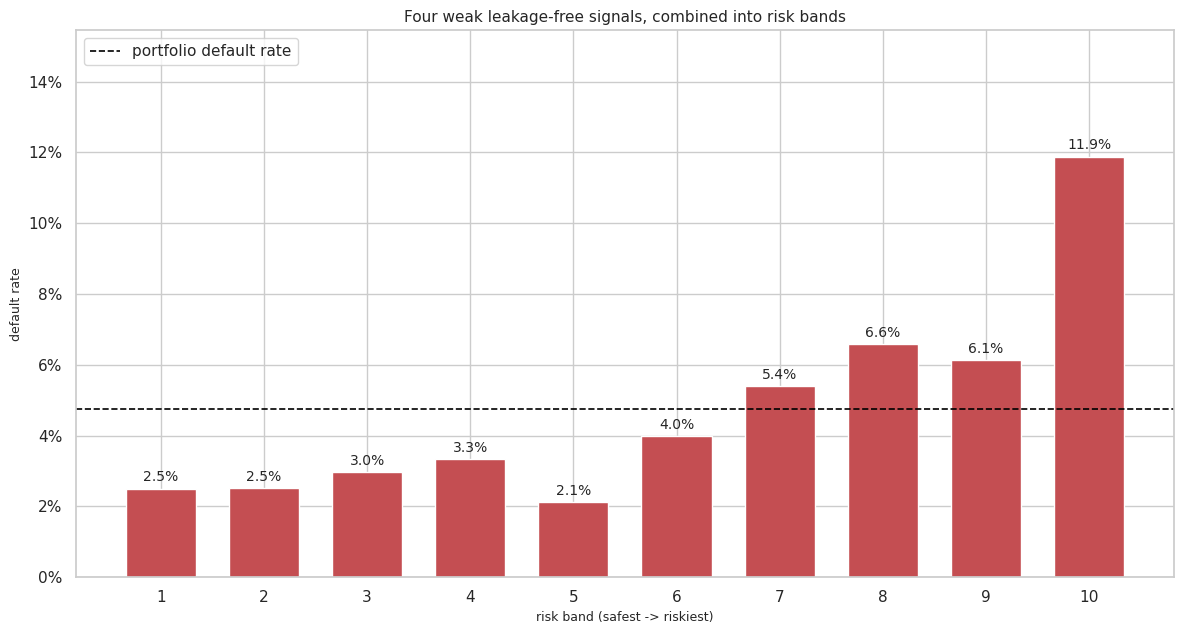

,n,default_rate,defaults
0,1077,0.0251,27
1,1076,0.0251,27
2,1076,0.0297,32
3,1076,0.0335,36
4,1077,0.0214,23
5,1076,0.0400,43
6,1076,0.0539,58
7,1076,0.0660,71
8,1076,0.0613,66
9,1077,0.1188,128


safest band 2.51% -> riskiest band 11.88% (2.5x the portfolio rate)
bands 2-6 are NOT monotone: they wobble between 2.1% and 4.0%


In [85]:
components = pd.DataFrame({
    "inquiry_intensity": calc["intensidad_consulta"].rank(pct=True),
    "low_bureau_score": (-score).rank(pct=True),
    "income_not_corroborated": (-calc["desfase_ingresos"]).rank(pct=True),
    "arrears_on_file": calc["tiene_mora"],
})
print("components available per client:")
print(components.notna().sum(axis=1).value_counts().sort_index().to_string())

# mean(axis=1) skips nulls, so a client with two components is ranked on those two.
risk_score = components.mean(axis=1)
band = pd.qcut(risk_score.rank(method="first"), 10, labels=False)
g = df[TARGET].groupby(band)
bands10 = pd.DataFrame({"n": g.size(), "default_rate": 1 - g.mean()})
bands10["defaults"] = (bands10["default_rate"] * bands10["n"]).round().astype(int)

fig, ax = plt.subplots(figsize=(12, 6.5))
bars = ax.bar(range(len(bands10)), bands10["default_rate"], color="#c44e52", width=.68)
ax.axhline(base_rate, ls="--", color="black", lw=1.2, label="portfolio default rate")
for bar, rate in zip(bars, bands10["default_rate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + .002, f"{rate:.1%}",
            ha="center", fontsize=10)
ax.set_xticks(range(len(bands10)))
ax.set_xticklabels([str(i + 1) for i in range(len(bands10))])
ax.set_xlabel("risk band (safest -> riskiest)")
ax.set_ylabel("default rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, bands10["default_rate"].max() * 1.3)
ax.set_title("Four weak leakage-free signals, combined into risk bands")
ax.legend(loc="upper left")
show_fig(fig, "F16_combined_signal_risk_bands")
plt.show()

display(bands10)
print(f"safest band {bands10['default_rate'].iloc[0]:.2%} -> "
      f"riskiest band {bands10['default_rate'].iloc[-1]:.2%} "
      f"({bands10['default_rate'].iloc[-1] / base_rate:.1f}x the portfolio rate)")
middle = bands10["default_rate"].iloc[1:6]
print(f"bands 2-6 are NOT monotone: they wobble between {middle.min():.1%} and {middle.max():.1%}")

**What it means.** No single variable in this dataset is strong once `puntaje` is removed;the best honest correlation is around |rho| = 0.11. Combined, the same weak signals producea band with more than twice the portfolio default rate. **That is the size of theopportunity, and it is the argument for building a real model.**#### 6.7.2 What a review queue would catchSorting applications worst-band-first. The x-axis is a **loan count** rather than a shareon purpose: a review queue is staffed in files per week, and a number of applicationsspread over eighteen months is a capacity conversation an operations lead can have."20% of the portfolio" is not.

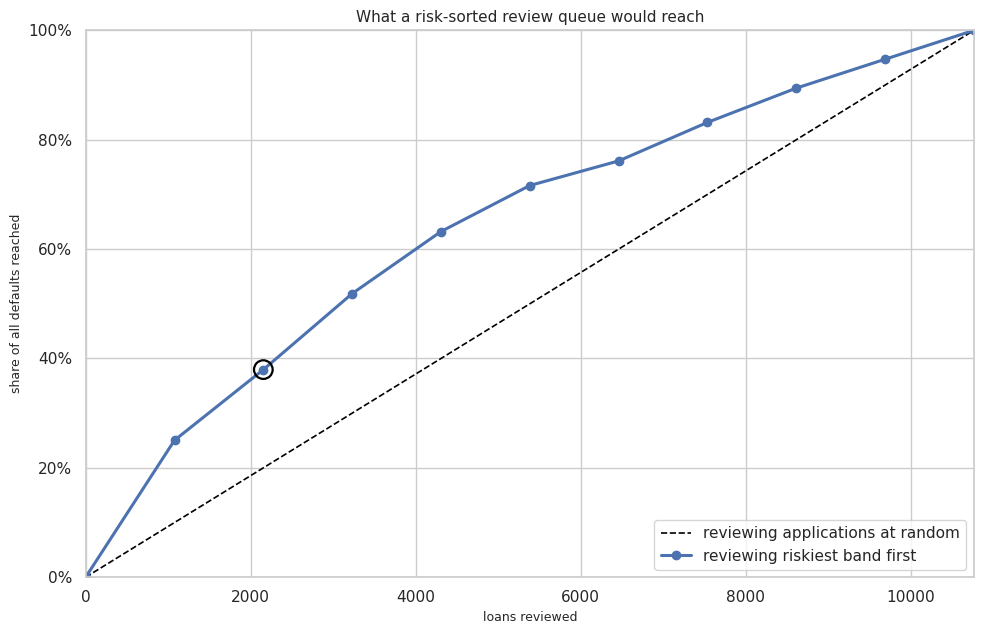

reviewing 2,153 of 10,763 loans (20% of the book) reaches 38.0% of all defaults
reviewing 4,305 reaches 63.2%

over 74 weeks of disbursements that is about 29 files a week


In [86]:
ordered = bands10.iloc[::-1].copy()
ordered["loans_reviewed"] = ordered["n"].cumsum()
ordered["pct_defaults"] = ordered["defaults"].cumsum() / bands10["defaults"].sum()
total_loans = int(bands10["n"].sum())
worst_two = ordered.iloc[1]
worst_four = ordered.iloc[3]

fig, ax = plt.subplots(figsize=(10, 6.5))
ax.plot([0, total_loans], [0, 1], ls="--", color="black", lw=1.2,
        label="reviewing applications at random")
ax.plot(np.r_[0, ordered["loans_reviewed"].to_numpy()],
        np.r_[0, ordered["pct_defaults"].to_numpy()],
        color="#4c72b0", marker="o", lw=2.2, label="reviewing riskiest band first")
ax.scatter([worst_two["loans_reviewed"]], [worst_two["pct_defaults"]], s=180,
           facecolor="none", edgecolor="black", lw=1.6, zorder=5)
ax.set_xlabel("loans reviewed")
ax.set_ylabel("share of all defaults reached")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax.set_xlim(0, total_loans); ax.set_ylim(0, 1)
ax.set_title("What a risk-sorted review queue would reach")
ax.legend(loc="lower right")
show_fig(fig, "F17_review_queue_capture_curve")
plt.show()

print(f"reviewing {int(worst_two['loans_reviewed']):,} of {total_loans:,} loans "
      f"({worst_two['loans_reviewed'] / total_loans:.0%} of the book) reaches "
      f"{worst_two['pct_defaults']:.1%} of all defaults")
print(f"reviewing {int(worst_four['loans_reviewed']):,} reaches "
      f"{worst_four['pct_defaults']:.1%}")
weeks = (df["fecha_prestamo"].max() - df["fecha_prestamo"].min()).days / 7
print(f"\nover {weeks:.0f} weeks of disbursements that is about "
      f"{worst_two['loans_reviewed'] / weeks:.0f} files a week")

#### 6.7.3 Read it honestly — this is not a modelThis is four ranked variables with equal weights, measured **in-sample on the same datathat suggested them**, with no train/test split and no calibration. The band curve is also**not monotone** in the middle, as the cell above prints; only the tails separate cleanly.A fitted model with proper validation would likely do better, and would certainly producea more trustworthy number.**Treat the capture rate as an order of magnitude, not a forecast.**

## 7. Figure index

In [87]:
# The notebook writes nothing to disk: every table and figure is an interactive
# output of the cell that produced it. FIGURE_INDEX just names them in order,
# so `scratchbook/08_extract_figures.py` and `scratchbook/09_export_final_plots.py`
# can recover them from the executed file.
print("FIGURE_INDEX_JSON:", json.dumps(FIGURE_INDEX))
pd.DataFrame({"figure": FIGURE_INDEX}, index=range(1, len(FIGURE_INDEX) + 1))

FIGURE_INDEX_JSON: ["01_missingness", "02_instalment_coverage", "03_histograms", "04_histograms_log", "05_boxplots", "06_countplots", "07_time_profile", "08_default_rate_categorical", "09_boxplot_by_target", "10_puntaje_separation", "11_corr_pearson", "11_corr_spearman", "12_corr_gap", "13_top_pairs", "14_scatter_linear", "15_scatter_log", "16_scatter_ranks", "17_dendrogram", "18_pairplot", "19_scatter_hue", "20_pivot_default", "21_default_by_bins", "22_variable_ranking", "23_decile_curves", "24_corr_calculated", "F01_leakage_score_distribution", "F02_leakage_sentinel_block", "F03_bureau_score_distribution", "F04_bureau_score_default_by_band", "F19_bureau_score_by_outcome", "F18_two_scores_against_each_other", "F05_pearson_vs_spearman_ranking", "F06_gap_pair1_raw_axes", "F07_gap_pair1_rank_space", "F08_gap_pair2_rank_space", "F09_gap_pair3_rank_space", "F10_units_thousands_of_pesos", "F11_declared_payment_not_balance", "F12_debt_service_does_not_predict", "F13_arrears_default_rate", "F

,figure
1,01_missingness
2,02_instalment_coverage
3,03_histograms
4,04_histograms_log
5,05_boxplots
6,06_countplots
7,07_time_profile
8,08_default_rate_categorical
9,09_boxplot_by_target
10,10_puntaje_separation
